In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import sys
top_path = '../'
if top_path not in sys.path:
    sys.path.append(top_path)
    
# coffea_path = '/afs/cern.ch/user/a/anpotreb/top/JERC/coffea/'
# if coffea_path not in sys.path:
#     sys.path.insert(0,coffea_path)
    
# ak_path = '/afs/cern.ch/user/a/anpotreb/top/JERC/local-packages/'

# if ak_path not in sys.path:
#     sys.path.insert(0,ak_path)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib as mpl
from coffea import util
from make_comparison_plot import make_comparison_plot, make_double_ratio_plot
from coffea.lookup_tools import extractor
from JetEtaBins import JetEtaBins, PtBins
from collections.abc import Iterable


from data_tools import read_or_recreate_data, read_or_recreate_data_txt
out_txt_path = '../out_txt'

def read_data2(mean_name, samp, tag1):
    return read_or_recreate_data_txt(mean_name, samp, tag1, out_txt_path)

from common_binning import JERC_Constants

In [4]:
from fileNames.available_datasets import legend_labels
ttbarlab = legend_labels['ttbar']['lab']

<Figure size 160x160 with 0 Axes>

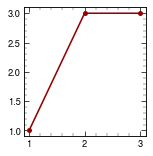

In [5]:
from pltStyle import pltStyle
# from scipy.interpolate import CubicSpline
pltStyle(style='hep')

#### some newer versions of pyplot and mplhep, aren't good friends with jupyter
#### To make the plots be formatted directly well, we need to make a dummy plot and rerun the import
### (a very silly solution)
plt.figure(num=None, figsize=(2, 2), dpi=80)
plt.plot([1,2,3],[1,3,3])
import matplotlib.pyplot as plt
pltStyle('hep', size_frac=3.0)
# plt.rcParams['figure.dpi'] = 100


In [6]:
# ### Some recent file to get out the binning
# # outname = '../out/CoffeaJERCOutputs_L5_DY-MG-Py.coffea'
# outname = '../out/jetdrcut/CoffeaJERCOutputs_L5_DY-MG-Py.coffea'
# output = util.load(outname)

# f_xvals = np.linspace(0,5,5001)

# ptbins = output[list(output.keys())[0]]['ptresponse_b'].axes['pt_gen'].edges
# ptbins_c = output[list(output.keys())[0]]['ptresponse_b'].axes['pt_gen'].centers

# # etabins = np.array(JERC_Constants.etaBinsEdges_Aut18_full())
# etabins = np.array(JERC_Constants.etaBinsEdges_Win14_full())
# # etabins = np.array(JERC_Constants.etaBinsEdges_CaloTowers_full())
# # etabins = np.array([-5, -3, -2.5, -1.3, 0, 1.3, 2.5, 3, 5])
# # etabins = np.array([-5.191, -3.489, -3.139, -2.853,   -2.5,
# #                     -2.322,  -1.93, -1.653, -1.305, -0.783,      
# #                     0,  0.783,  1.305,  1.653,   1.93,  2.322, 2.5, 
# #                     2.853,  3.139,  3.489, 5.191])
    

# etabins_abs = etabins[(len(etabins)-1)//2:]
# etabins_c = (etabins_abs[:-1]+etabins_abs[1:])/2 #output['ptresponse'].axis('jeteta').centers()

In [7]:
# import matplotlib as mpl

In [8]:
# (read_data2("Median", "b", '_L5_QCD-MG-Py')[0:,0])/read_data2("Median", "b", '_L5_QCD-MG-Her')[0:,0]

In [9]:
# color_scheme

In [10]:
# color_scheme = {key: cycler_vals
#     for cycler_vals, key in zip(plt.rcParams['axes.prop_cycle'], ['g', 'q', 'c', 'b', 'QCD', 'DY', 'TTBAR', 'DY200'])}

# leggend_dict = {'g': 'Gluons', 'q': 'Quarks', 'b': 'Bottom', 'c': 'Charm'}

In [6]:
def read_data4plot_txt(flav, tag, closure=1, path=out_txt_path, mean_name="Median"):
    '''Read the Mean, MeanStd and RecoPt values of the data with tag `tag` and flavor `flav`.
    If closure==1, there is no clusure, otherwise it has to be of the same shape as the data read
    mean_name = "Median" or 'Mean'
    '''
    mean_name_std = mean_name+'Std'
    if not isinstance(closure, Iterable):
        closure_tmp = np.array([closure])
    else:
        closure_tmp = np.array(closure).copy()
        closure_tmp[closure_tmp==0] = np.nan
    median = read_or_recreate_data_txt(mean_name, flav, tag, path=path)/closure_tmp #[2:]
    medianstd = read_or_recreate_data_txt(mean_name_std, flav, tag, path=path) #[2:]
    reco = read_or_recreate_data_txt("MeanRecoPt", flav, tag, path=path)
    return [median, medianstd, reco]
    

In [7]:
def read_data4plot(tag, closure=1, path=out_txt_path):
    '''Read the Mean, MeanStd, Median, MedianStd and RecoPt values of the data with tag `tag`.
    If closure==1, there is no clusure, otherwise it has to be of the same shape as the data read
    '''
#     file_path = f'../out_txt/fit_results_L5_{tag}.json'
#     with open(file_path, 'r') as json_file:
#         json_data = json.load(json_file)
    
    data = read_or_recreate_data(tag, out_txt_path)['data']

    if not isinstance(closure, Iterable):
        closure_tmp = np.array([closure])
    else:
        closure_tmp = np.array(closure).copy()
        closure_tmp[closure_tmp==0] = np.nan
    
    close = ["Median", "Mean"]
    for flav in data:
        for mean_name in close:
            data[flav][mean_name] = data[flav][mean_name]/closure_tmp #[2:]
        for typeii in ["MedianStd", "MeanStd", "MeanRecoPt"]:
            data[flav][typeii] = np.array(data[flav][typeii])

    return data
    

In [13]:
# plt.rcParams['lines.markersize'] = plt.rcParams['lines.markersize']*0.8

Read data from  ../out_txt/response_fit_results_L5_QCD-Py.json
Read data from  ../out_txt/response_fit_results_L5_DY-MG-Py.json
Read data from  ../out_txt/response_fit_results_L5_DY-MG-Her.json
Fitting subsample:  all
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7_all_eta0p0to1p305.pdf / .png


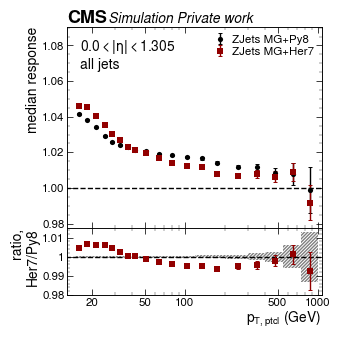

Fitting subsample:  all
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7_all_eta1p305to2p5.pdf / .png


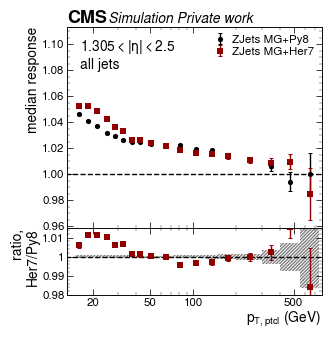

Fitting subsample:  all
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7_all_eta2p5to3p139.pdf / .png


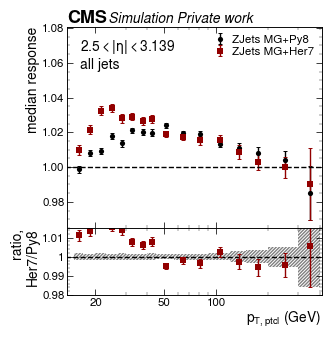

Fitting subsample:  all
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7_all_eta3p139to5p191.pdf / .png


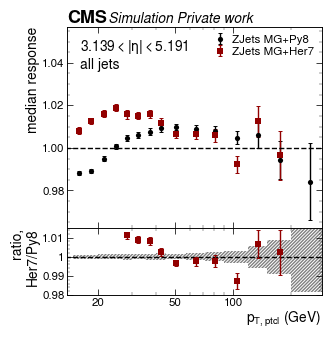

Fitting subsample:  b
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7_b_eta0p0to1p305.pdf / .png


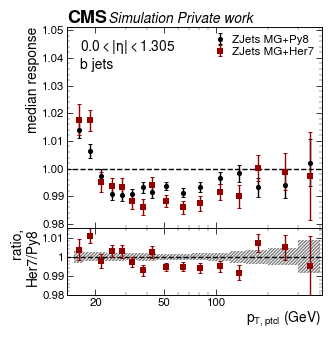

Fitting subsample:  b
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7_b_eta1p305to2p5.pdf / .png


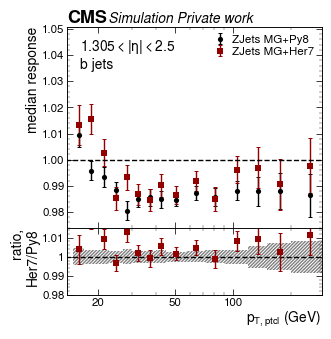

Fitting subsample:  b
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7_b_eta2p5to3p139.pdf / .png


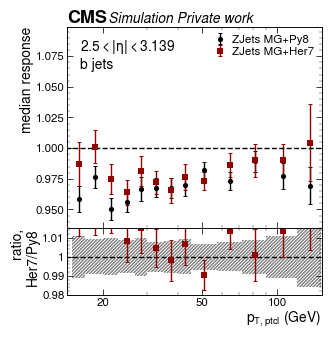

Fitting subsample:  b
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7/med_resp_vs_pt_L5_ZJets_MG_Py8-ZJets_MG_Her7_b_eta3p139to5p191.pdf / .png


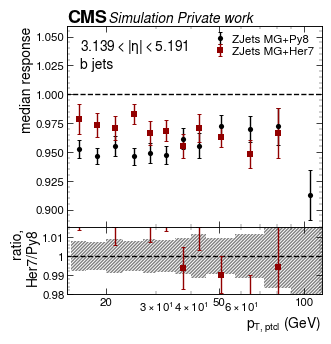

In [14]:
# load_fit_res=True
# subsamples = ['all', 'b', 'c', 'd', 'u', 's', 'g', 'bbar', 'cbar', 'ubar', 'dbar', 'sbar']
# flavors = ['all'] #, 'b', 'c', 'd', 'u', 's', 'g', 'ud', 'q', 'unmatched']
# flavors = ['b', 'g', 'ud', 'c', 's', 'all', 'q', 'unmatched', 'd', 'u']
# flavors = ['c_prompt', 'c_gluon_splitting', 'c', 'b_prompt', 'b_gluon_splitting', 'b', 'ud', 's', 'all', 'q', 'unmatched', 'd', 'u']
# flavors = ['b', 'c', 'g', 'ud', 's', 'all', 'q', 'unmatched', 'd', 'u']
plotvspt = True
flavors = ['all', 'b']

eta_binning  = "HCalPart"  ### HCalPart, JERC, CoarseCalo, CaloTowers, Summer20Flavor, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
etabins = JetEtaBins(eta_binning, absolute=True)
ptbins = PtBins("MC_truth")

iso_str = ''
# tag1 = '_L5_QCD-Py'+iso_str+eta_binning_str
# tag1_gen_gen = '_L5_QCD-Py_gen_gen'+eta_binning_str
# tag1_reco_reco = '_L5_QCD-Py_reco_reco'+eta_binning_str
# tag1_gen_reco = '_L5_QCD-Py_recoforalpha'+eta_binning_str
# tag1_genwt = '_L5_QCD-Py_genwt'+eta_binning_str
# tag1_noiso2 = '_L5_QCD-Py_noiso2'+eta_binning_str
# tag2 = '_L5_QCD-MG-Py'+iso_str+eta_binning_str
# tag2Her = '_L5_QCD-MG-Her'+iso_str+eta_binning_str
# tag3 = '_L5_Pythia-TTBAR'+iso_str+eta_binning_str
# tag3 = '_L5_Pythia-semilep-TTBAR'+eta_binning_str
# tag3_100files = '_L5_Pythia-TTBAR_100files'+eta_binning_str
# tag3Her = '_L5_Herwig-TTBAR'+iso_str+eta_binning_str
# tag4noiso = '_L5_DY-MG-Py_noiso'+eta_binning_str
tag4 = '_L5_DY-MG-Py'+iso_str+eta_binning_str
tag4Her = '_L5_DY-MG-Her'+iso_str+eta_binning_str
# tag5 = '_L5_Pythia-TTBAR_ISR-FSR'+eta_binning_str

mean_name = "Median"
mean_name_std = mean_name+'Std'
closure_QCD = read_data4plot('_L5_QCD-Py'+eta_binning_str)['all'][mean_name] #read_data2(mean_name, 'all', '_L5_QCD-Py'+eta_binning_str)
# closure_QCD = read_data2(mean_name, 'all', '_L5_QCD-Py_iso_cut'+eta_binning_str)
# closure_QCD_iso = read_data2(mean_name, 'all', tag26)
# closure_TTBAR = read_data2(mean_name, 'all', '_L5_QCD-Py'+eta_binning_str)
# closure_tag29 = read_data2(mean_name, 'all', tag29)
# closure_tag30 = read_data2(mean_name, 'all', tag30)
# closure_Py2 = read_data2(mean_name, 'all', tag3)
# closure_Py3 = read_data2(mean_name, 'all', tag5)
# closure_Py = read_data(mean_name, 'all', tag3)

data_to_read = {
    # label_on_plot: data_list,
#     f"{ttbarlab} Pow+Py8": read_data4plot(tag3, closure_QCD), #[:,:-1,:],
#     f"ZJets MG+Py8": read_data4plot(tag4, closure_QCD), #, closure_QCD)), #[:,:-1,:],
#     f"QCD MG+Py8": read_data4plot(tag2, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
#     f"QCD Py8": read_data4plot(tag1, closure_QCD), #[:,:-1,:],
#     f"{ttbarlab} Pow+Her7": read_data4plot(tag3Her, closure_QCD), #[:,:-1,:],
#     f"QCD Py8, gen-gen": read_data4plot(tag1_gen_gen), #[:,:-1,:],
#     f"QCD Py8, reco-reco": read_data4plot(tag1_reco_reco), #[:,:-1,:],
#     f"QCD Py8, reco-gen": read_data4plot(tag1_gen_reco), #[:,:-1,:],
#     f"QCD Py8, gen-reco": read_data4plot(tag1_noiso2), #[:,:-1,:],
#     f"{ttbarlab} Pow+Her7": read_data4plot(tag3Her, closure_QCD), #[:,:-1,:],
#     f"ZJets MG+Py8, noiso": read_data4plot(tag4noiso, closure_QCD), #, closure_QCD)), #[:,:-1,:],
    f"ZJets MG+Py8": read_data4plot(tag4, closure_QCD), #, closure_QCD)), #[:,:-1,:],
    f"ZJets MG+Her7": read_data4plot(tag4Her, closure_QCD), #, closure_QCD)), #[:,:-1,:],
#     f"QCD MG+Her7": read_data4plot(tag2Her, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],

    #     f"QCD MG+Her7": read_data4plot(tag2Her, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],

}


for flav in flavors:
    data = {tag:data_to_read[tag][flav] for tag in data_to_read}
    data = {key:np.array([data[key][mean_name], data[key][mean_name_std], data[key]["MeanRecoPt"]]) for key in data}
#     data = {
#         # label_on_plot: data_list,
#         f"{ttbarlab} Pow+Py8": np.array(read_data4plot(flav, tag3, closure_QCD)), #[:,:-1,:],
#         f"ZJets MG+Py8": np.array(read_data4plot(flav, tag4, closure_QCD)), #, closure_QCD)), #[:,:-1,:],
#         f"QCD MG+Py8": np.array(read_data4plot(flav, tag2, closure_QCD)),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
#         f"QCD Py8": np.array(read_data4plot(flav, tag1, closure_QCD)), #[:,:-1,:],
# #         f"{ttbarlab} Pow+Her7": np.array(read_data4plot(flav, tag3Her, closure_QCD)), #[:,:-1,:],
# #         f"ZJets MG+Her7": np.array(read_data4plot(flav, tag4Her, closure_QCD)), #, closure_QCD)), #[:,:-1,:],
# #         f"QCD MG+Her7": np.array(read_data4plot(flav, tag2Her, closure_QCD)),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
# #         f"{ttbarlab} Pow+Py8+ISR-FSR": np.array(read_data4plot(flav, tag5, closure_QCD)), #[:,:-1,:],

        
#     }

#     for k in range(len(etabins_abs)-1):
    for k in etabins.get_bin_idx([0, 1.305, 2.5, 4]):
#     for k in ptbins.get_bin_idx([20, 35, 150, 400]):
        print('Fitting subsample: ', flav)
        print('Eta: ', etabins.centres[k]) if plotvspt else print('pt: ', ptbins.centres[k])
        if plotvspt:
            if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
                continue
        
        make_comparison_plot(data, 
                          {},
                          etabins, ptbins,
                          binidx=k, flav=flav, pt_min=15, ratio_name='ratio,\nHer7/Py8', inverse=False, plotvspt=plotvspt, ratio_ylim=[0.985, 1.015], extra_text='')


Read data from  ../out_txt/response_fit_results_L5_QCD-Py_Summer20Flavor.json
Read data from  ../out_txt/response_fit_results_L5_Herwig-TTBAR_Summer20Flavor.json
Read data from  ../out_txt/response_fit_results_L5_DY-MG-Her_Summer20Flavor.json
Read data from  ../out_txt/response_fit_results_L5_QCD-MG-Her_Summer20Flavor.json
Fitting subsample:  b
Eta:  0.1305
Saving plot for eta =  eta0p0to0p261
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7-ZJets_MG_Her7-QCD_MG_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7-ZJets_MG_Her7-QCD_MG_Her7_b_eta0p0to0p261.pdf / .png


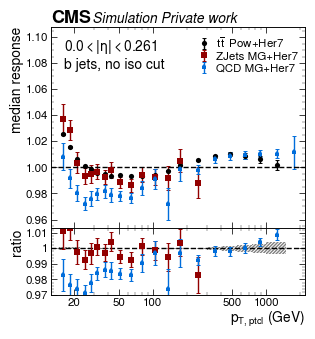

Fitting subsample:  b
Eta:  1.4355
Saving plot for eta =  eta1p305to1p566
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7-ZJets_MG_Her7-QCD_MG_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7-ZJets_MG_Her7-QCD_MG_Her7_b_eta1p305to1p566.pdf / .png


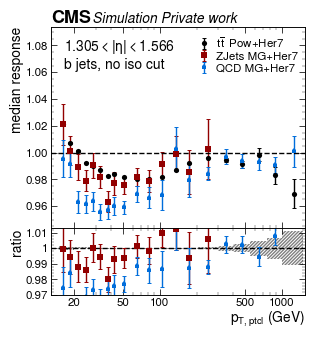

Fitting subsample:  b
Eta:  2.732
Saving plot for eta =  eta2p5to2p964
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7-ZJets_MG_Her7-QCD_MG_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7-ZJets_MG_Her7-QCD_MG_Her7_b_eta2p5to2p964.pdf / .png


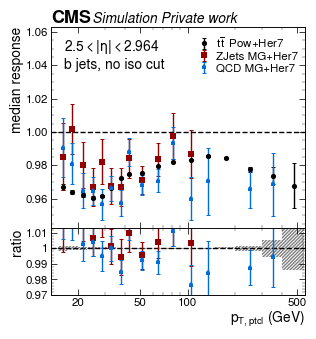

Fitting subsample:  b
Eta:  4.0775
Saving plot for eta =  eta2p964to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7-ZJets_MG_Her7-QCD_MG_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7-ZJets_MG_Her7-QCD_MG_Her7_b_eta2p964to5p191.pdf / .png


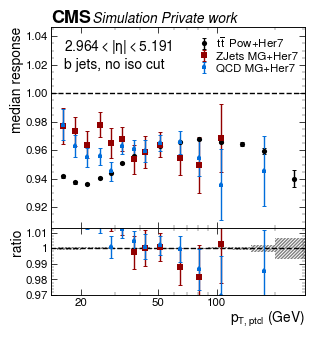

Fitting subsample:  c
Eta:  0.1305


KeyboardInterrupt: 

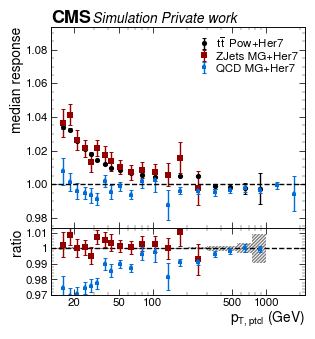

In [14]:
# load_fit_res=True
# subsamples = ['all', 'b', 'c', 'd', 'u', 's', 'g', 'bbar', 'cbar', 'ubar', 'dbar', 'sbar']
# flavors = ['all'] #, 'b', 'c', 'd', 'u', 's', 'g', 'ud', 'q', 'unmatched']
# flavors = ['b', 'g', 'ud', 'c', 's', 'all', 'q', 'unmatched', 'd', 'u']
# flavors = ['c_prompt', 'c_gluon_splitting', 'c', 'b_prompt', 'b_gluon_splitting', 'b', 'ud', 's', 'all', 'q', 'unmatched', 'd', 'u']
flavors = ['b', 'c', 'g', 'ud', 's', 'all', 'q', 'unmatched', 'd', 'u']
plotvspt = True
# flavors = ['all', 'b']

eta_binning  = "Summer20Flavor"  ### HCalPart, JERC, CoarseCalo, CaloTowers, Summer20Flavor, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
etabins = JetEtaBins(eta_binning, absolute=True)
ptbins = PtBins("MC_truth")

iso_str = ''
tag1 = '_L5_QCD-Py'+iso_str+eta_binning_str
tag1_gen_gen = '_L5_QCD-Py_gen_gen'+eta_binning_str
tag1_reco_reco = '_L5_QCD-Py_reco_reco'+eta_binning_str
tag1_gen_reco = '_L5_QCD-Py_recoforalpha'+eta_binning_str
tag1_genwt = '_L5_QCD-Py_genwt'+eta_binning_str
tag1_noiso2 = '_L5_QCD-Py_noiso2'+eta_binning_str
tag2 = '_L5_QCD-MG-Py'+iso_str+eta_binning_str
tag2Her = '_L5_QCD-MG-Her'+iso_str+eta_binning_str
tag3 = '_L5_Pythia-TTBAR'+iso_str+eta_binning_str
# tag3 = '_L5_Pythia-semilep-TTBAR'+eta_binning_str
# tag3_100files = '_L5_Pythia-TTBAR_100files'+eta_binning_str
tag3Her = '_L5_Herwig-TTBAR'+iso_str+eta_binning_str
tag4 = '_L5_DY-MG-Py'+iso_str+eta_binning_str
tag4Her = '_L5_DY-MG-Her'+iso_str+eta_binning_str
tag5 = '_L5_Pythia-TTBAR_ISR-FSR'+eta_binning_str

# tag31 = '_L5_Pythia-TTBAR_iso_dr_0p8'+eta_binning_str
# tag32 = '_L5_Pythia-TTBAR_iso_dr_1p2'+eta_binning_str
# tag33 = '_L5_Pythia-TTBAR_iso_dr_1p5'+eta_binning_str
# tag34 = '_L5_Pythia-non-semilep-TTBAR'+eta_binning_str

# tag1 = '_L5_DY-MG-Py'
# tag2 = '_L5_DY-MG-Her'

mean_name = "Median"
mean_name_std = mean_name+'Std'
closure_QCD = read_data4plot('_L5_QCD-Py'+eta_binning_str)['all'][mean_name] #read_data2(mean_name, 'all', '_L5_QCD-Py'+eta_binning_str)
# closure_QCD = read_data2(mean_name, 'all', '_L5_QCD-Py_iso_cut'+eta_binning_str)
# closure_QCD_iso = read_data2(mean_name, 'all', tag26)
# closure_TTBAR = read_data2(mean_name, 'all', '_L5_QCD-Py'+eta_binning_str)
# closure_tag29 = read_data2(mean_name, 'all', tag29)
# closure_tag30 = read_data2(mean_name, 'all', tag30)
# closure_Py2 = read_data2(mean_name, 'all', tag3)
# closure_Py3 = read_data2(mean_name, 'all', tag5)
# closure_Py = read_data(mean_name, 'all', tag3)

data_to_read = {
    # label_on_plot: data_list,
#     f"{ttbarlab} Pow+Py8": read_data4plot(tag3, closure_QCD), #[:,:-1,:],
#     f"ZJets MG+Py8": read_data4plot(tag4, closure_QCD), #, closure_QCD)), #[:,:-1,:],
#     f"QCD MG+Py8": read_data4plot(tag2, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
#     f"QCD Py8": read_data4plot(tag1, closure_QCD), #[:,:-1,:],
#     f"{ttbarlab} Pow+Her7": read_data4plot(tag3Her, closure_QCD), #[:,:-1,:],
#     f"QCD Py8, gen-gen": read_data4plot(tag1_gen_gen), #[:,:-1,:],
#     f"QCD Py8, reco-reco": read_data4plot(tag1_reco_reco), #[:,:-1,:],
#     f"QCD Py8, reco-gen": read_data4plot(tag1_gen_reco), #[:,:-1,:],
#     f"QCD Py8, gen-reco": read_data4plot(tag1_noiso2), #[:,:-1,:],
    f"{ttbarlab} Pow+Her7": read_data4plot(tag3Her, closure_QCD), #[:,:-1,:],
    f"ZJets MG+Her7": read_data4plot(tag4Her, closure_QCD), #, closure_QCD)), #[:,:-1,:],
    f"QCD MG+Her7": read_data4plot(tag2Her, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],

    #     f"QCD MG+Her7": read_data4plot(tag2Her, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],

}


for flav in flavors:
    data = {tag:data_to_read[tag][flav] for tag in data_to_read}
    data = {key:np.array([data[key][mean_name], data[key][mean_name_std], data[key]["MeanRecoPt"]]) for key in data}
#     data = {
#         # label_on_plot: data_list,
#         f"{ttbarlab} Pow+Py8": np.array(read_data4plot(flav, tag3, closure_QCD)), #[:,:-1,:],
#         f"ZJets MG+Py8": np.array(read_data4plot(flav, tag4, closure_QCD)), #, closure_QCD)), #[:,:-1,:],
#         f"QCD MG+Py8": np.array(read_data4plot(flav, tag2, closure_QCD)),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
#         f"QCD Py8": np.array(read_data4plot(flav, tag1, closure_QCD)), #[:,:-1,:],
# #         f"{ttbarlab} Pow+Her7": np.array(read_data4plot(flav, tag3Her, closure_QCD)), #[:,:-1,:],
# #         f"ZJets MG+Her7": np.array(read_data4plot(flav, tag4Her, closure_QCD)), #, closure_QCD)), #[:,:-1,:],
# #         f"QCD MG+Her7": np.array(read_data4plot(flav, tag2Her, closure_QCD)),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
# #         f"{ttbarlab} Pow+Py8+ISR-FSR": np.array(read_data4plot(flav, tag5, closure_QCD)), #[:,:-1,:],

        
#     }

#     for k in range(len(etabins_abs)-1):
    for k in etabins.get_bin_idx([0, 1.305, 2.5, 4]):
#     for k in ptbins.get_bin_idx([20, 35, 150, 400]):
        print('Fitting subsample: ', flav)
        print('Eta: ', etabins.centres[k]) if plotvspt else print('pt: ', ptbins.centres[k])
        if plotvspt:
            if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
                continue
        
        make_comparison_plot(data, 
                          {},
                          etabins, ptbins,
                          binidx=k, flav=flav, pt_min=15, ratio_name='ratio', inverse=False, plotvspt=plotvspt, ratio_ylim=[0.97, 1.013], extra_text=', no iso cut')


Read data from  ../out_txt/response_fit_results_L5_QCD-Py_Summer20Flavor.json
Read data from  ../out_txt/response_fit_results_L5_Herwig-TTBAR_Summer20Flavor.json
Fitting subsample:  b
Eta:  0.1305
Saving plot for eta =  eta0p0to0p261
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_b_eta0p0to0p261.pdf / .png


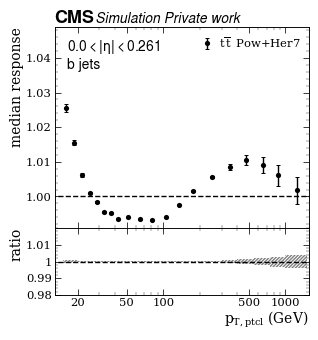

Fitting subsample:  b
Eta:  1.4355
Saving plot for eta =  eta1p305to1p566
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_b_eta1p305to1p566.pdf / .png


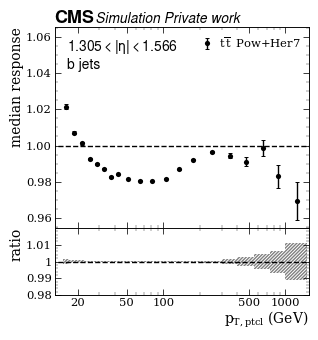

Fitting subsample:  b
Eta:  2.732
Saving plot for eta =  eta2p5to2p964
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_b_eta2p5to2p964.pdf / .png


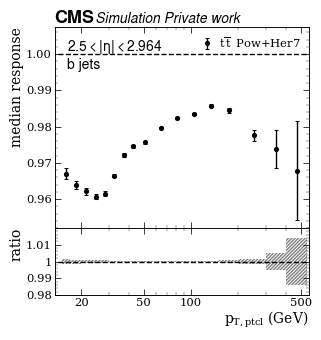

Fitting subsample:  b
Eta:  4.0775
Saving plot for eta =  eta2p964to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_b_eta2p964to5p191.pdf / .png


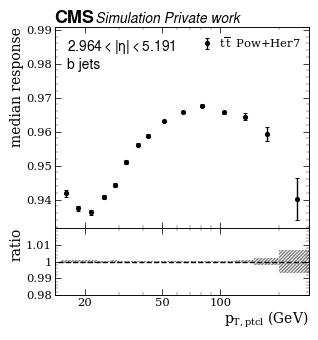

Fitting subsample:  g
Eta:  0.1305
Saving plot for eta =  eta0p0to0p261
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_g_eta0p0to0p261.pdf / .png


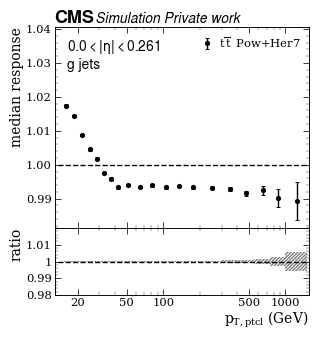

Fitting subsample:  g
Eta:  1.4355
Saving plot for eta =  eta1p305to1p566
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_g_eta1p305to1p566.pdf / .png


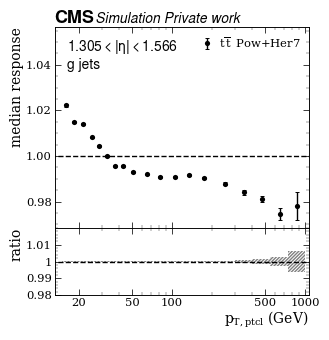

Fitting subsample:  g
Eta:  2.732
Saving plot for eta =  eta2p5to2p964
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_g_eta2p5to2p964.pdf / .png


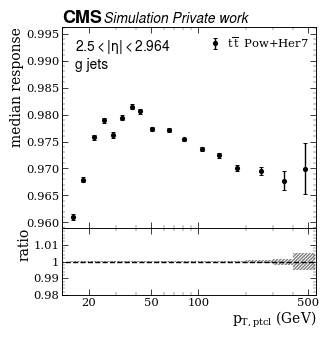

Fitting subsample:  g
Eta:  4.0775
Saving plot for eta =  eta2p964to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_g_eta2p964to5p191.pdf / .png


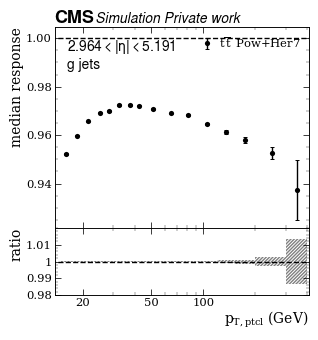

Fitting subsample:  ud
Eta:  0.1305
Saving plot for eta =  eta0p0to0p261
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_ud_eta0p0to0p261.pdf / .png


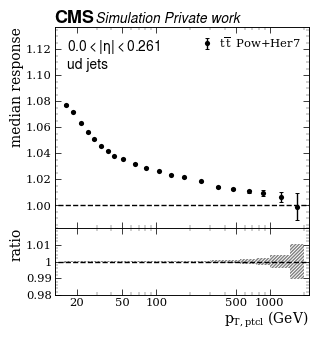

Fitting subsample:  ud
Eta:  1.4355
Saving plot for eta =  eta1p305to1p566
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_ud_eta1p305to1p566.pdf / .png


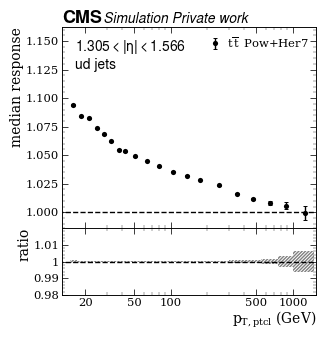

Fitting subsample:  ud
Eta:  2.732
Saving plot for eta =  eta2p5to2p964
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_ud_eta2p5to2p964.pdf / .png


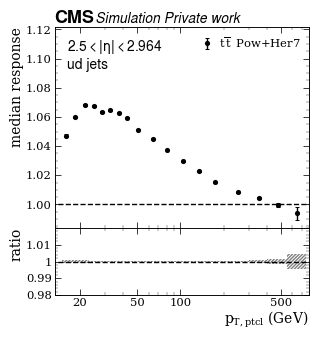

Fitting subsample:  ud
Eta:  4.0775
Saving plot for eta =  eta2p964to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_ud_eta2p964to5p191.pdf / .png


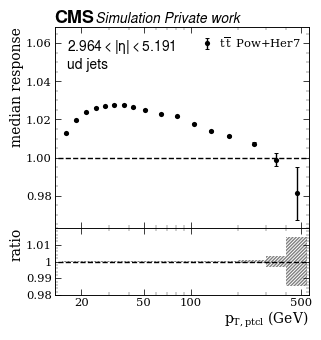

Fitting subsample:  c
Eta:  0.1305
Saving plot for eta =  eta0p0to0p261
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_c_eta0p0to0p261.pdf / .png


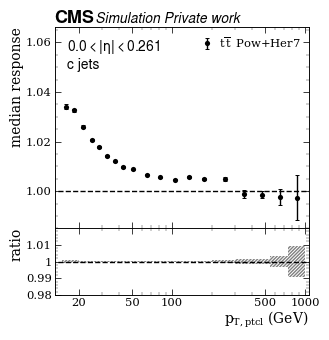

Fitting subsample:  c
Eta:  1.4355
Saving plot for eta =  eta1p305to1p566
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_c_eta1p305to1p566.pdf / .png


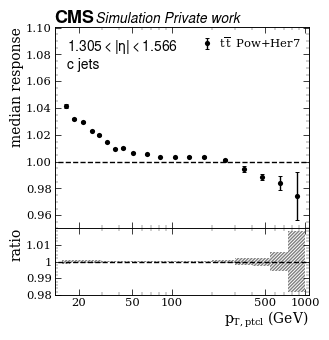

Fitting subsample:  c
Eta:  2.732
Saving plot for eta =  eta2p5to2p964
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_c_eta2p5to2p964.pdf / .png


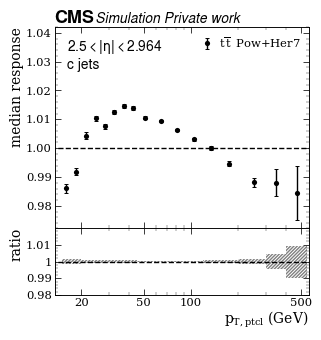

Fitting subsample:  c
Eta:  4.0775
Saving plot for eta =  eta2p964to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_c_eta2p964to5p191.pdf / .png


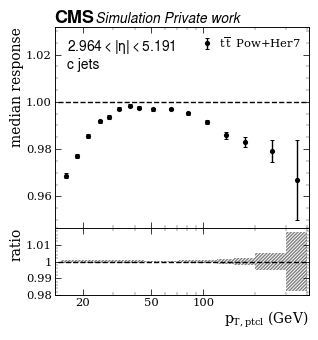

Fitting subsample:  s
Eta:  0.1305
Saving plot for eta =  eta0p0to0p261
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_s_eta0p0to0p261.pdf / .png


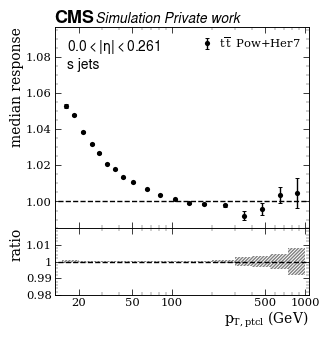

Fitting subsample:  s
Eta:  1.4355
Saving plot for eta =  eta1p305to1p566
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_s_eta1p305to1p566.pdf / .png


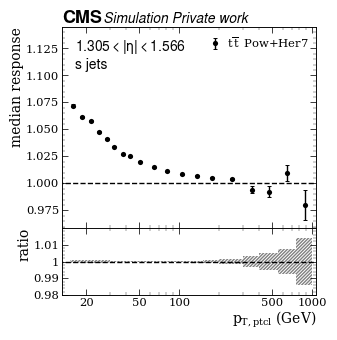

Fitting subsample:  s
Eta:  2.732
Saving plot for eta =  eta2p5to2p964
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_s_eta2p5to2p964.pdf / .png


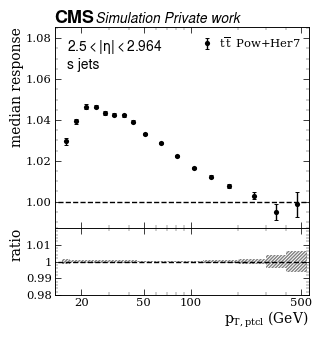

Fitting subsample:  s
Eta:  4.0775
Saving plot for eta =  eta2p964to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_s_eta2p964to5p191.pdf / .png


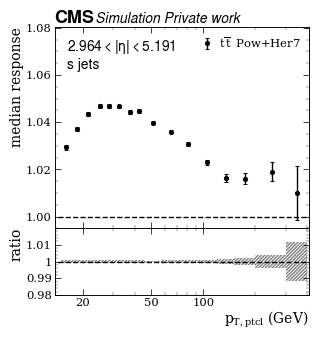

Fitting subsample:  all
Eta:  0.1305
Saving plot for eta =  eta0p0to0p261
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_all_eta0p0to0p261.pdf / .png


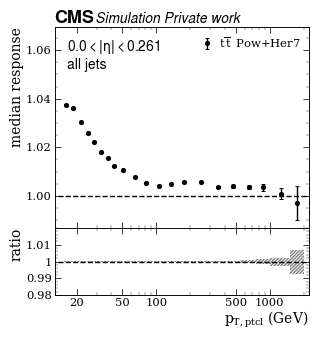

Fitting subsample:  all
Eta:  1.4355
Saving plot for eta =  eta1p305to1p566
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_all_eta1p305to1p566.pdf / .png


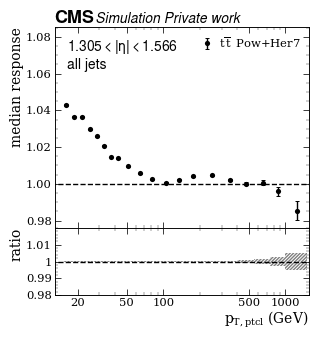

Fitting subsample:  all
Eta:  2.732
Saving plot for eta =  eta2p5to2p964
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_all_eta2p5to2p964.pdf / .png


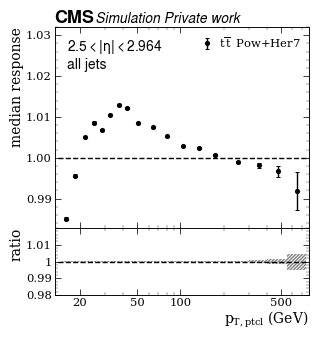

Fitting subsample:  all
Eta:  4.0775
Saving plot for eta =  eta2p964to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_all_eta2p964to5p191.pdf / .png


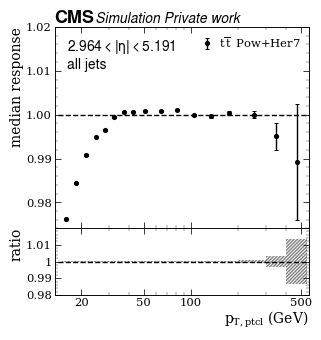

Fitting subsample:  q
Eta:  0.1305
Saving plot for eta =  eta0p0to0p261
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_q_eta0p0to0p261.pdf / .png


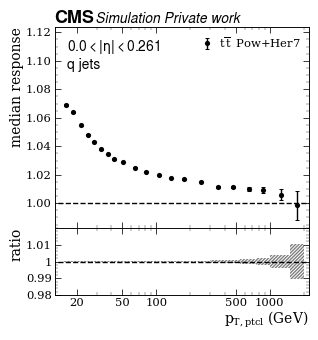

Fitting subsample:  q
Eta:  1.4355
Saving plot for eta =  eta1p305to1p566
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_q_eta1p305to1p566.pdf / .png


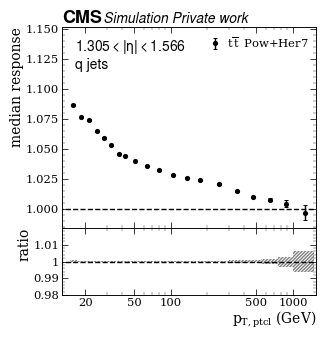

Fitting subsample:  q
Eta:  2.732
Saving plot for eta =  eta2p5to2p964
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_q_eta2p5to2p964.pdf / .png


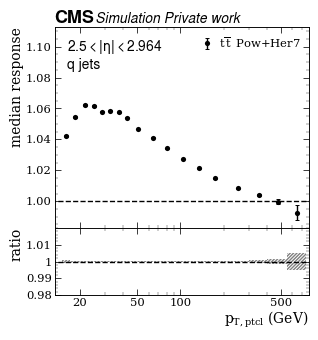

Fitting subsample:  q
Eta:  4.0775
Saving plot for eta =  eta2p964to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_q_eta2p964to5p191.pdf / .png


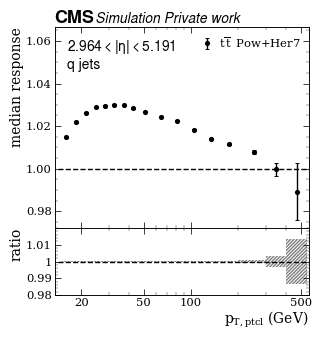

Fitting subsample:  unmatched
Eta:  0.1305
Saving plot for eta =  eta0p0to0p261
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_unmatched_eta0p0to0p261.pdf / .png


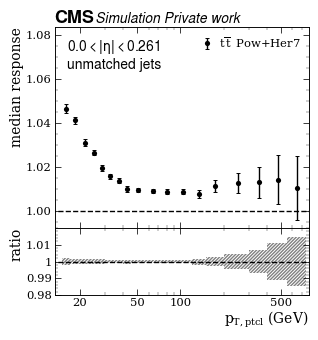

Fitting subsample:  unmatched
Eta:  1.4355
Saving plot for eta =  eta1p305to1p566
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_unmatched_eta1p305to1p566.pdf / .png


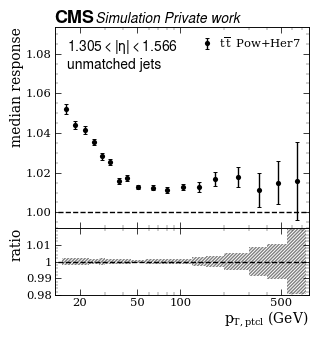

Fitting subsample:  unmatched
Eta:  2.732
Saving plot for eta =  eta2p5to2p964
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_unmatched_eta2p5to2p964.pdf / .png


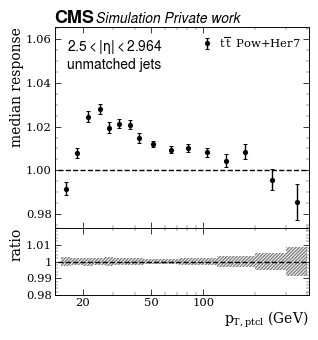

Fitting subsample:  unmatched
Eta:  4.0775
Saving plot for eta =  eta2p964to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_unmatched_eta2p964to5p191.pdf / .png


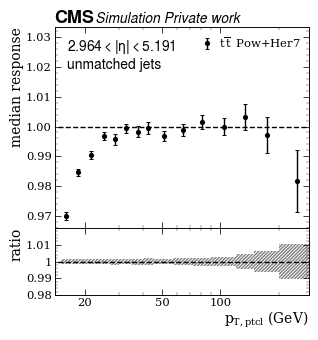

Fitting subsample:  d
Eta:  0.1305
Saving plot for eta =  eta0p0to0p261
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_d_eta0p0to0p261.pdf / .png


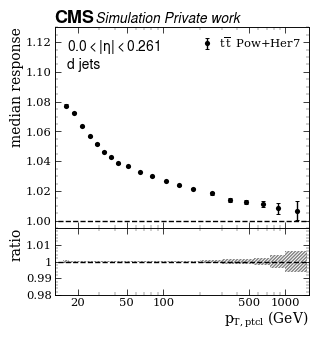

Fitting subsample:  d
Eta:  1.4355
Saving plot for eta =  eta1p305to1p566
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_d_eta1p305to1p566.pdf / .png


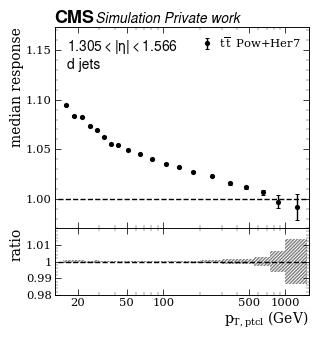

Fitting subsample:  d
Eta:  2.732
Saving plot for eta =  eta2p5to2p964
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_d_eta2p5to2p964.pdf / .png


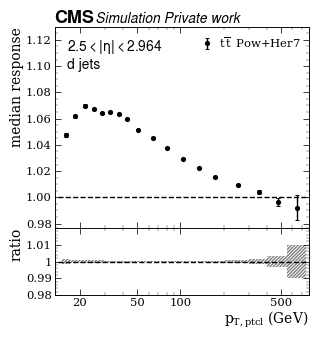

Fitting subsample:  d
Eta:  4.0775
Saving plot for eta =  eta2p964to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_d_eta2p964to5p191.pdf / .png


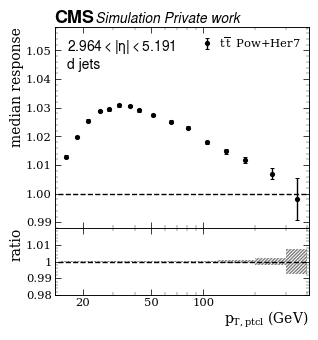

Fitting subsample:  u
Eta:  0.1305
Saving plot for eta =  eta0p0to0p261
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_u_eta0p0to0p261.pdf / .png


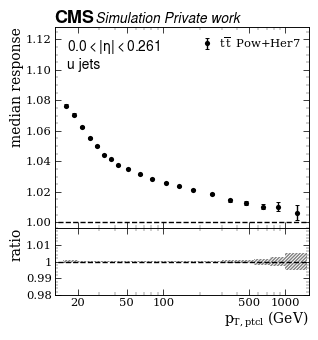

Fitting subsample:  u
Eta:  1.4355
Saving plot for eta =  eta1p305to1p566
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_u_eta1p305to1p566.pdf / .png


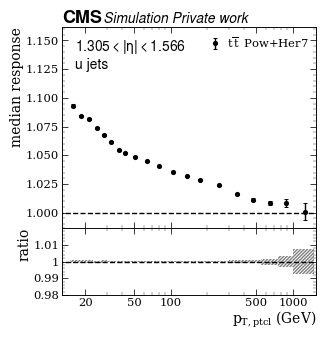

Fitting subsample:  u
Eta:  2.732
Saving plot for eta =  eta2p5to2p964
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_u_eta2p5to2p964.pdf / .png


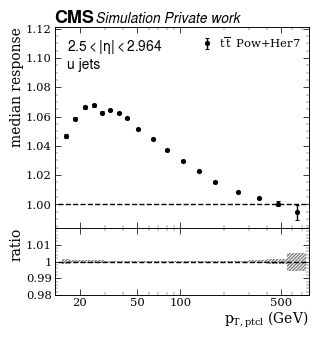

Fitting subsample:  u
Eta:  4.0775
Saving plot for eta =  eta2p964to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Her7/med_resp_vs_pt_L5_ttbar_Pow_Her7_u_eta2p964to5p191.pdf / .png


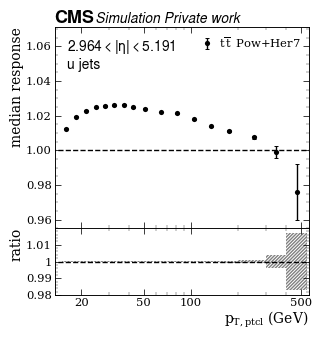

In [21]:
# load_fit_res=True
# subsamples = ['all', 'b', 'c', 'd', 'u', 's', 'g', 'bbar', 'cbar', 'ubar', 'dbar', 'sbar']
# flavors = ['all'] #, 'b', 'c', 'd', 'u', 's', 'g', 'ud', 'q', 'unmatched']
flavors = ['b', 'g', 'ud', 'c', 's', 'all', 'q', 'unmatched', 'd', 'u']
# flavors = ['c_prompt', 'c_gluon_splitting', 'c', 'b_prompt', 'b_gluon_splitting', 'b', 'ud', 's', 'all', 'q', 'unmatched', 'd', 'u']
plotvspt = True
# flavors = ['all', 'b']

eta_binning  = "Summer20Flavor"  ### HCalPart, JERC, CoarseCalo, CaloTowers, Summer20Flavor, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
etabins = JetEtaBins(eta_binning, absolute=True)
ptbins = PtBins("MC_truth")

tag1 = '_L5_QCD-Py'+eta_binning_str
tag1_gen_gen = '_L5_QCD-Py_gen_gen'+eta_binning_str
tag1_reco_reco = '_L5_QCD-Py_reco_reco'+eta_binning_str
tag1_gen_reco = '_L5_QCD-Py_recoforalpha'+eta_binning_str
tag1_genwt = '_L5_QCD-Py_genwt'+eta_binning_str
tag1_noiso2 = '_L5_QCD-Py_noiso2'+eta_binning_str
tag2 = '_L5_QCD-MG-Py'+eta_binning_str
tag2Her = '_L5_QCD-MG-Her'+eta_binning_str
tag3 = '_L5_Pythia-TTBAR'+eta_binning_str
# tag3 = '_L5_Pythia-semilep-TTBAR'+eta_binning_str
# tag3_100files = '_L5_Pythia-TTBAR_100files'+eta_binning_str
tag3Her = '_L5_Herwig-TTBAR'+eta_binning_str
tag4 = '_L5_DY-MG-Py'+eta_binning_str
tag4Her = '_L5_DY-MG-Her'+eta_binning_str
tag5 = '_L5_Pythia-TTBAR_ISR-FSR'+eta_binning_str

# tag31 = '_L5_Pythia-TTBAR_iso_dr_0p8'+eta_binning_str
# tag32 = '_L5_Pythia-TTBAR_iso_dr_1p2'+eta_binning_str
# tag33 = '_L5_Pythia-TTBAR_iso_dr_1p5'+eta_binning_str
# tag34 = '_L5_Pythia-non-semilep-TTBAR'+eta_binning_str

# tag1 = '_L5_DY-MG-Py'
# tag2 = '_L5_DY-MG-Her'

mean_name = "Median"
mean_name_std = mean_name+'Std'
closure_QCD = read_data4plot('_L5_QCD-Py'+eta_binning_str)['all'][mean_name] #read_data2(mean_name, 'all', '_L5_QCD-Py'+eta_binning_str)
# closure_QCD = read_data2(mean_name, 'all', '_L5_QCD-Py_iso_cut'+eta_binning_str)
# closure_QCD_iso = read_data2(mean_name, 'all', tag26)
# closure_TTBAR = read_data2(mean_name, 'all', '_L5_QCD-Py'+eta_binning_str)
# closure_tag29 = read_data2(mean_name, 'all', tag29)
# closure_tag30 = read_data2(mean_name, 'all', tag30)
# closure_Py2 = read_data2(mean_name, 'all', tag3)
# closure_Py3 = read_data2(mean_name, 'all', tag5)
# closure_Py = read_data(mean_name, 'all', tag3)

data_to_read = {
    # label_on_plot: data_list,
#     f"{ttbarlab} Pow+Py8": read_data4plot(tag3, closure_QCD), #[:,:-1,:],
#     f"ZJets MG+Py8": read_data4plot(tag4, closure_QCD), #, closure_QCD)), #[:,:-1,:],
#     f"QCD MG+Py8": read_data4plot(tag2, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
#     f"QCD Py8": read_data4plot(tag1, closure_QCD), #[:,:-1,:],
    f"{ttbarlab} Pow+Her7": read_data4plot(tag3Her, closure_QCD), #[:,:-1,:],
#     f"QCD Py8, gen-gen": read_data4plot(tag1_gen_gen), #[:,:-1,:],
#     f"QCD Py8, reco-reco": read_data4plot(tag1_reco_reco), #[:,:-1,:],
#     f"QCD Py8, reco-gen": read_data4plot(tag1_gen_reco), #[:,:-1,:],
#     f"QCD Py8, gen-reco": read_data4plot(tag1_noiso2), #[:,:-1,:],
#     f"{ttbarlab} Pow+Her7": read_data4plot(tag3Her, closure_QCD), #[:,:-1,:],
#     f"ZJets MG+Her7": read_data4plot(tag4Her, closure_QCD), #, closure_QCD)), #[:,:-1,:],
#     f"QCD MG+Her7": read_data4plot(tag2Her, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],

    #     f"QCD MG+Her7": read_data4plot(tag2Her, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],

}


for flav in flavors:
    data = {tag:data_to_read[tag][flav] for tag in data_to_read}
    data = {key:np.array([data[key][mean_name], data[key][mean_name_std], data[key]["MeanRecoPt"]]) for key in data}
#     data = {
#         # label_on_plot: data_list,
#         f"{ttbarlab} Pow+Py8": np.array(read_data4plot(flav, tag3, closure_QCD)), #[:,:-1,:],
#         f"ZJets MG+Py8": np.array(read_data4plot(flav, tag4, closure_QCD)), #, closure_QCD)), #[:,:-1,:],
#         f"QCD MG+Py8": np.array(read_data4plot(flav, tag2, closure_QCD)),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
#         f"QCD Py8": np.array(read_data4plot(flav, tag1, closure_QCD)), #[:,:-1,:],
# #         f"{ttbarlab} Pow+Her7": np.array(read_data4plot(flav, tag3Her, closure_QCD)), #[:,:-1,:],
# #         f"ZJets MG+Her7": np.array(read_data4plot(flav, tag4Her, closure_QCD)), #, closure_QCD)), #[:,:-1,:],
# #         f"QCD MG+Her7": np.array(read_data4plot(flav, tag2Her, closure_QCD)),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
# #         f"{ttbarlab} Pow+Py8+ISR-FSR": np.array(read_data4plot(flav, tag5, closure_QCD)), #[:,:-1,:],

        
#     }

#     for k in range(len(etabins_abs)-1):
    for k in etabins.get_bin_idx([0, 1.305, 2.5, 4]):
#     for k in ptbins.get_bin_idx([20, 35, 150, 400]):
        print('Fitting subsample: ', flav)
        print('Eta: ', etabins.centres[k]) if plotvspt else print('pt: ', ptbins.centres[k])
        if plotvspt:
            if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
                continue
        
        make_comparison_plot(data, 
                          {},
                          etabins, ptbins,
                          binidx=k, flav=flav, pt_min=15, ratio_name='ratio', inverse=False, plotvspt=plotvspt, ratio_ylim=[0.98, 1.02])

### For the ISR g and the rest g splitting
# data = {
#     # label_on_plot: data_list,
#     f"{ttbarlab} Pow+Py8 all g": np.array(read_data4plot('g', tag5, closure_QCD)), #[:,:-1,:],
#     f"{ttbarlab} Pow+Py8 ISR g": np.array(read_data4plot('ISR_gluon', tag5, closure_QCD)), #[:,:-1,:],
#     f"{ttbarlab} Pow+Py8 rest g": np.array(read_data4plot('FSR_gluon', tag5, closure_QCD)),

# #         f"{ttbarlab} Pow+Py8": np.array(read_data4plot(flav, tag3, closure_QCD)), #[:,:-1,:],
#     f"ZJets MG+Py8": np.array(read_data4plot('g', tag4, closure_QCD)), #, closure_QCD)), #[:,:-1,:],
# #     f"QCD MG+Py8": np.array(read_data4plot('g', tag2, closure_QCD)),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
#     f"QCD Py8": np.array(read_data4plot('g', tag1, closure_QCD)), #[:,:-1,:],
# #         f"ZJets MG+Her7": np.array(read_data4plot(flav, tag4Her, closure_QCD)), #, closure_QCD)), #[:,:-1,:],
# #         f"QCD MG+Her7": np.array(read_data4plot(flav, tag2Her, closure_QCD)),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
# #         f"QCD Her7": np.array(read_data4plot(flav, tag1Her, closure_QCD)), #[:,:-1,:],
# }

# for k in etabins.get_bin_idx([0, 1.305, 2.5, 4]):
#     print('Fitting subsample: ', flav)
#     print('Eta: ', etabins.centres[k]) if plotvspt else print('pt: ', ptbins.centres[k])
#     if plotvspt:
#         if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
#             continue

#     make_comparison_plot(data, 
#                       {},
#                       etabins, ptbins,
#                       binidx=k, flav=flav, ratio_name='ratio', inverse=True, plotvspt=plotvspt, ratio_ylim=[0.98, 1.02])
        
3;

Read data from  ../out_txt/response_fit_results_L5_QCD-Py.json
Read data from  ../out_txt/response_fit_results_L5_Pythia-TTBAR.json
Read data from  ../out_txt/response_fit_results_L5_DY-MG-Py.json
Read data from  ../out_txt/response_fit_results_L5_QCD-MG-Py.json
Read data from  ../out_txt/response_fit_results_L5_QCD-Py.json
Fitting subsample:  c_prompt
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8_c_prompt_eta0p0to1p305.pdf / .png


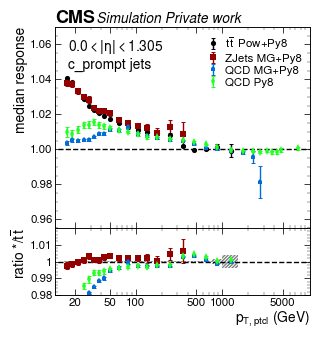

Fitting subsample:  c_prompt
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8_c_prompt_eta1p305to2p5.pdf / .png


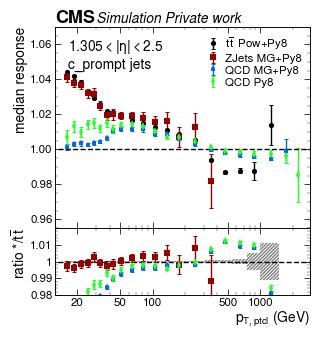

Fitting subsample:  c_prompt
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8_c_prompt_eta2p5to3p139.pdf / .png


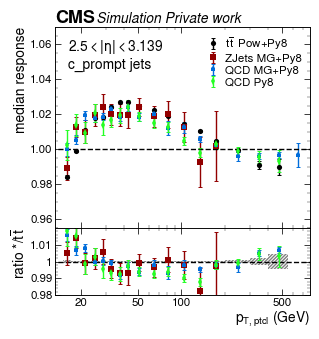

Fitting subsample:  c_prompt
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8_c_prompt_eta3p139to5p191.pdf / .png


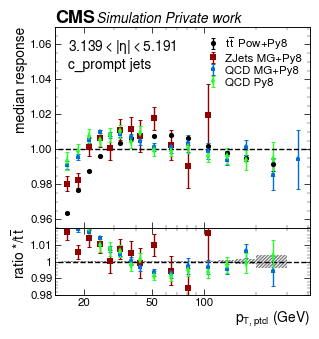

Fitting subsample:  c_gluon_splitting
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8_c_gluon_splitting_eta0p0to1p305.pdf / .png


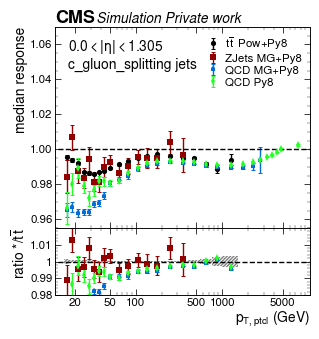

Fitting subsample:  c_gluon_splitting
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8_c_gluon_splitting_eta1p305to2p5.pdf / .png


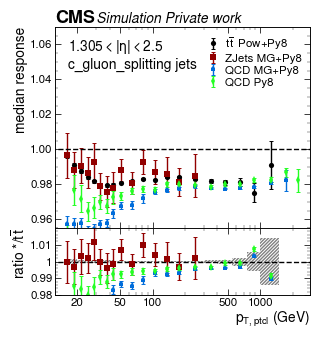

Fitting subsample:  c_gluon_splitting
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8_c_gluon_splitting_eta2p5to3p139.pdf / .png


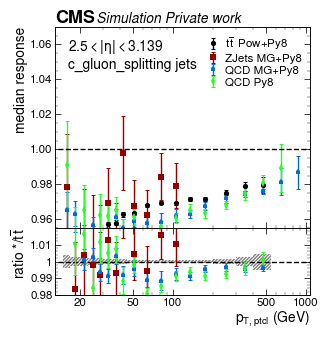

Fitting subsample:  c_gluon_splitting
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8_c_gluon_splitting_eta3p139to5p191.pdf / .png


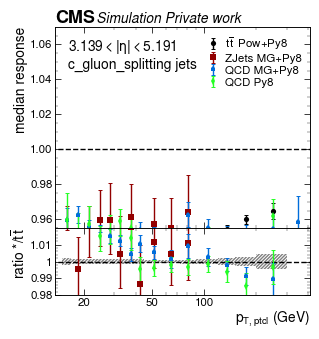

Fitting subsample:  c
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8_c_eta0p0to1p305.pdf / .png


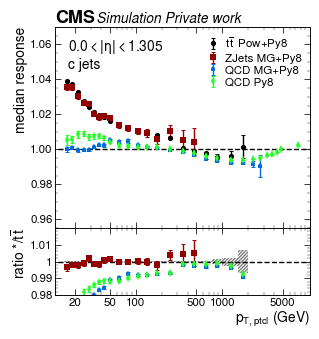

Fitting subsample:  c
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8_c_eta1p305to2p5.pdf / .png


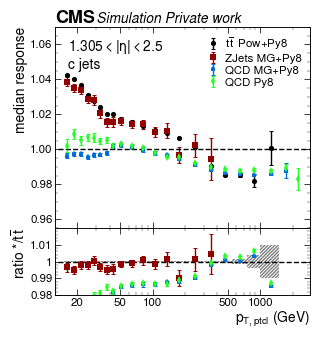

Fitting subsample:  c
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8_c_eta2p5to3p139.pdf / .png


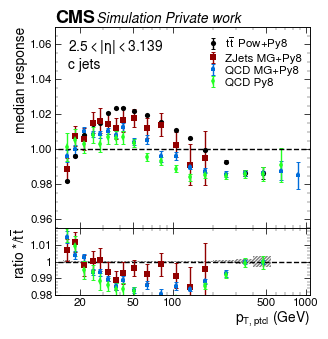

Fitting subsample:  c
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8/med_resp_vs_pt_L5_ttbar_Pow_Py8-ZJets_MG_Py8-QCD_MG_Py8-QCD_Py8_c_eta3p139to5p191.pdf / .png


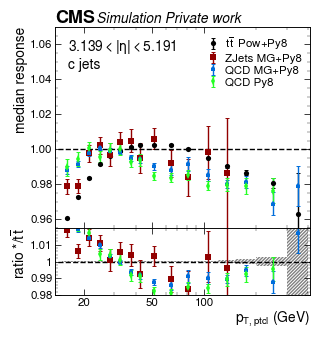

In [24]:
# load_fit_res=True
# subsamples = ['all', 'b', 'c', 'd', 'u', 's', 'g', 'bbar', 'cbar', 'ubar', 'dbar', 'sbar']
# flavors = ['all'] #, 'b', 'c', 'd', 'u', 's', 'g', 'ud', 'q', 'unmatched']
# flavors = ['b', 'g', 'ud', 'c', 's', 'all', 'q', 'unmatched', 'd', 'u']
# flavors = ['c_prompt', 'c_gluon_splitting', 'c', 'b_prompt', 'b_gluon_splitting', 'b', 's', 'all', 'q', 'unmatched', 'd', 'u']
plotvspt = True
flavors = ['b_prompt', 'b_gluon_splitting', 'b']

eta_binning  = "HCalPart"  ### HCalPart, JERC, CoarseCalo, CaloTowers, Summer20Flavor, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
etabins = JetEtaBins(eta_binning, absolute=True)
ptbins = PtBins("MC_truth")

tag1 = '_L5_QCD-Py'+eta_binning_str
tag1_gen_gen = '_L5_QCD-Py_gen_gen'+eta_binning_str
tag1_reco_reco = '_L5_QCD-Py_reco_reco'+eta_binning_str
tag1_gen_reco = '_L5_QCD-Py_recoforalpha'+eta_binning_str
tag1_genwt = '_L5_QCD-Py_genwt'+eta_binning_str
tag1_noiso2 = '_L5_QCD-Py_noiso2'+eta_binning_str
tag2 = '_L5_QCD-MG-Py'+eta_binning_str
tag2Her = '_L5_QCD-MG-Her'+eta_binning_str
tag3 = '_L5_Pythia-TTBAR'+eta_binning_str
# tag3 = '_L5_Pythia-semilep-TTBAR'+eta_binning_str
# tag3_100files = '_L5_Pythia-TTBAR_100files'+eta_binning_str
tag3Her = '_L5_Herwig-TTBAR'+eta_binning_str
tag4 = '_L5_DY-MG-Py'+eta_binning_str
tag4Her = '_L5_DY-MG-Her'+eta_binning_str
tag5 = '_L5_Pythia-TTBAR_ISR-FSR'+eta_binning_str

# tag31 = '_L5_Pythia-TTBAR_iso_dr_0p8'+eta_binning_str
# tag32 = '_L5_Pythia-TTBAR_iso_dr_1p2'+eta_binning_str
# tag33 = '_L5_Pythia-TTBAR_iso_dr_1p5'+eta_binning_str
# tag34 = '_L5_Pythia-non-semilep-TTBAR'+eta_binning_str

# tag1 = '_L5_DY-MG-Py'
# tag2 = '_L5_DY-MG-Her'

mean_name = "Median"
mean_name_std = mean_name+'Std'
closure_QCD = read_data4plot('_L5_QCD-Py'+eta_binning_str)['all'][mean_name] #read_data2(mean_name, 'all', '_L5_QCD-Py'+eta_binning_str)
# closure_QCD = read_data2(mean_name, 'all', '_L5_QCD-Py_iso_cut'+eta_binning_str)
# closure_QCD_iso = read_data2(mean_name, 'all', tag26)
# closure_TTBAR = read_data2(mean_name, 'all', '_L5_QCD-Py'+eta_binning_str)
# closure_tag29 = read_data2(mean_name, 'all', tag29)
# closure_tag30 = read_data2(mean_name, 'all', tag30)
# closure_Py2 = read_data2(mean_name, 'all', tag3)
# closure_Py3 = read_data2(mean_name, 'all', tag5)
# closure_Py = read_data(mean_name, 'all', tag3)

data_to_read = {
    # label_on_plot: data_list,
#     f"{ttbarlab} Pow+Py8": read_data4plot(tag3, closure_QCD), #[:,:-1,:],
    f"{ttbarlab} Pow+Her7": read_data4plot(tag3Her, closure_QCD), #[:,:-1,:],
    f"ZJets MG+Py8": read_data4plot(tag4, closure_QCD), #, closure_QCD)), #[:,:-1,:],
    f"QCD MG+Py8": read_data4plot(tag2, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
#     f"QCD MG+Her7": read_data4plot(tag2Her, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
    f"QCD Py8": read_data4plot(tag1, closure_QCD), #[:,:-1,:],
#     f"QCD Py8, gen-gen": read_data4plot(tag1_gen_gen), #[:,:-1,:],
#     f"QCD Py8, reco-reco": read_data4plot(tag1_reco_reco), #[:,:-1,:],
#     f"QCD Py8, reco-gen": read_data4plot(tag1_gen_reco), #[:,:-1,:],
#     f"QCD Py8, gen-reco": read_data4plot(tag1_noiso2), #[:,:-1,:],
#     f"{ttbarlab} Pow+Her7": read_data4plot(tag3Her, closure_QCD), #[:,:-1,:],
#     f"ZJets MG+Her7": read_data4plot(tag4Her, closure_QCD), #, closure_QCD)), #[:,:-1,:],
#     f"QCD MG+Her7": read_data4plot(tag2Her, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],

}


for flav in flavors:
    data = {tag:data_to_read[tag][flav] for tag in data_to_read}
    data = {key:np.array([data[key][mean_name], data[key][mean_name_std], data[key]["MeanRecoPt"]]) for key in data}
#     data = {
#         # label_on_plot: data_list,
#         f"{ttbarlab} Pow+Py8": np.array(read_data4plot(flav, tag3, closure_QCD)), #[:,:-1,:],
#         f"ZJets MG+Py8": np.array(read_data4plot(flav, tag4, closure_QCD)), #, closure_QCD)), #[:,:-1,:],
#         f"QCD MG+Py8": np.array(read_data4plot(flav, tag2, closure_QCD)),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
#         f"QCD Py8": np.array(read_data4plot(flav, tag1, closure_QCD)), #[:,:-1,:],
# #         f"{ttbarlab} Pow+Her7": np.array(read_data4plot(flav, tag3Her, closure_QCD)), #[:,:-1,:],
# #         f"ZJets MG+Her7": np.array(read_data4plot(flav, tag4Her, closure_QCD)), #, closure_QCD)), #[:,:-1,:],
# #         f"QCD MG+Her7": np.array(read_data4plot(flav, tag2Her, closure_QCD)),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
# #         f"{ttbarlab} Pow+Py8+ISR-FSR": np.array(read_data4plot(flav, tag5, closure_QCD)), #[:,:-1,:],

        
#     }

#     for k in range(len(etabins_abs)-1):
    for k in etabins.get_bin_idx([0, 1.305, 2.5, 4]):
#     for k in ptbins.get_bin_idx([20, 35, 150, 400]):
        print('Fitting subsample: ', flav)
        print('Eta: ', etabins.centres[k]) if plotvspt else print('pt: ', ptbins.centres[k])
        if plotvspt:
            if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
                continue
        
        make_comparison_plot(data, 
                          {},
                          etabins, ptbins,
                          binidx=k, flav=flav, pt_min=15, ratio_name=f'ratio */{ttbarlab}', inverse=False, plotvspt=plotvspt, ratio_ylim=[0.98, 1.02], ylim=[0.955,1.075])

### For the ISR g and the rest g splitting
# data = {
#     # label_on_plot: data_list,
#     f"{ttbarlab} Pow+Py8 all g": np.array(read_data4plot('g', tag5, closure_QCD)), #[:,:-1,:],
#     f"{ttbarlab} Pow+Py8 ISR g": np.array(read_data4plot('ISR_gluon', tag5, closure_QCD)), #[:,:-1,:],
#     f"{ttbarlab} Pow+Py8 rest g": np.array(read_data4plot('FSR_gluon', tag5, closure_QCD)),

# #         f"{ttbarlab} Pow+Py8": np.array(read_data4plot(flav, tag3, closure_QCD)), #[:,:-1,:],
#     f"ZJets MG+Py8": np.array(read_data4plot('g', tag4, closure_QCD)), #, closure_QCD)), #[:,:-1,:],
# #     f"QCD MG+Py8": np.array(read_data4plot('g', tag2, closure_QCD)),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
#     f"QCD Py8": np.array(read_data4plot('g', tag1, closure_QCD)), #[:,:-1,:],
# #         f"ZJets MG+Her7": np.array(read_data4plot(flav, tag4Her, closure_QCD)), #, closure_QCD)), #[:,:-1,:],
# #         f"QCD MG+Her7": np.array(read_data4plot(flav, tag2Her, closure_QCD)),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
# #         f"QCD Her7": np.array(read_data4plot(flav, tag1Her, closure_QCD)), #[:,:-1,:],
# }

# for k in etabins.get_bin_idx([0, 1.305, 2.5, 4]):
#     print('Fitting subsample: ', flav)
#     print('Eta: ', etabins.centres[k]) if plotvspt else print('pt: ', ptbins.centres[k])
#     if plotvspt:
#         if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
#             continue

#     make_comparison_plot(data, 
#                       {},
#                       etabins, ptbins,
#                       binidx=k, flav=flav, ratio_name='ratio', inverse=True, plotvspt=plotvspt, ratio_ylim=[0.98, 1.02])
        
3;

In [18]:
# data_to_read['$t\\overline{\\, t\\!}$  Pow+Py8'].keys()

In [15]:
output = util.load('../out/CoffeaJERCOutputs_L5_QCD-MG-Py.coffea')
# output = util.load('../out/CoffeaJERCOutputs_L5_Pythia-TTBAR.coffea')
# b = util.load('../out/CoffeaJERCOutputs_L5_QCD-MG-Her.coffea')
import helpers as h
from fileNames.available_datasets import dataset_dictionary
tag_cutflow = "QCD-MG-Py"

In [16]:
# print("Loaded histograms from: ", outname)
xsec_dict, legend_label = h.get_xsec_dict("QCD-MG-Py", dataset_dictionary)
# xsec_dict, legend_label = h.get_xsec_dict("Pythia-TTBAR", dataset_dictionary)

keys = output.keys()
try: ## in older files cutflow was not split into cutflow for jets and events. Should be removed in the future
    Nev = {key: output[key]['cutflow_events']['all_events'].value for key in keys}
except KeyError:
    Nev = {key: output[key]['cutflow']['all_events'].value for key in keys}
scale_factors = h.hist_div(xsec_dict, Nev)
all_histo_keys = output[next(iter(output.keys()))].keys()
hists_merged = {histo_key:h.sum_subhist(output, histo_key, scale_factors) for histo_key in all_histo_keys }
hist1 = output[list(keys)[0]] ### plotting only the first
hist1['cutflow_events'].variances()[:] = hist1['cutflow_events'].values()
hist1['cutflow_jets'].variances()[:] = hist1['cutflow_jets'].values()
# hists_merged['cutflow_events'].variances()[:] = hists_merged['cutflow_events'].values()
# hists_merged['cutflow_jets'].variances()[:] = hists_merged['cutflow_jets'].values()

In [79]:
hists_merged['cutflow_events'].values()
hists_merged['cutflow_events'].variances()
hists_merged['cutflow_events']=hists_merged['cutflow_events']/10
hists_merged['cutflow_events'].values()
hists_merged['cutflow_events'].variances()

array([0.9957    , 0.9957    , 0.63475114, 0.63475114])

array([0.9957    , 0.9957    , 0.63475114, 0.63475114])

array([0.09957   , 0.09957   , 0.06347511, 0.06347511])

array([0.009957  , 0.009957  , 0.00634751, 0.00634751])

In [ ]:
b['Pythia-fullhad-TTBAR']['cutflow_events']['all_events']
a['Pythia-dilep-TTBAR']['cutflow_events']['all_events']

In [ ]:
a['Herwig-TTBAR']['cutflow_events']['all_events']
b['Pythia-TTBAR_TTbarSemiLep']['cutflow_events']['all_events']
b['Pythia-TTBAR_TTbarDilep']['cutflow_events']['all_events']
b['Pythia-TTBAR_TTbarFullHad']['cutflow_events']['all_events']


In [ ]:
# a.keys()
# b.keys()

In [ ]:
a['QCD-Py']['cutflow'][[ 'matched gen cut', 'alpha cut; leading jets',]].values()
a['QCD-Py']['cutflow']

In [12]:
sc = util.load('../out/CoffeaJERCOutputs_L5_scaled_pion.coffea')
not_sc = util.load('../out/CoffeaJERCOutputs_L5_not_scaled_pion.coffea')
sc_2 = util.load('../out/CoffeaJERCOutputs_L5_scaled_times2_pion.coffea')
sc_5 = util.load('../out/CoffeaJERCOutputs_L5_scaled_times5_pion.coffea')
sc_10 = util.load('../out/CoffeaJERCOutputs_L5_scaled_times10_pion.coffea')

In [ ]:
nopu = util.load('../out/CoffeaJERCOutputs_L5_QCD-Py.coffea')
pu = util.load('../out/CoffeaJERCOutputs_L5_QCD-Py_pu.coffea')
# sc_100 = util.load('../out/CoffeaJERCOutputs_L5_scaled_times100_pion.coffea')

In [ ]:
nopu['QCD-Py']['cutflow']['all_events']
pu['QCD-Py']['cutflow']['all_events']
# sc_10['scaled_times10_pion']['cutflow']['all_events']

In [ ]:
sc['scaled_pion']['cutflow_events']['all_events']
not_sc['not_scaled_pion']['cutflow_events']['all_events']
sc_10['scaled_times10_pion']['cutflow_events']['all_events']

In [ ]:
data_to_read = {
    # label_on_plot: data_list,
#     f"{ttbarlab} Pow+Py8": read_data4plot(tag3, closure_QCD), #[:,:-1,:],
#     f"ZJets MG+Py8": read_data4plot(tag4, closure_QCD), #, closure_QCD)), #[:,:-1,:],
#     f"QCD MG+Py8": read_data4plot(tag2, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],
#     f"QCD Py8": read_data4plot(tag1, closure_QCD), #[:,:-1,:],
    f"{ttbarlab} Pow+Her7": read_data4plot(tag3Her, closure_QCD), #[:,:-1,:],
#     f"QCD Py8, gen-gen": read_data4plot(tag1_gen_gen), #[:,:-1,:],
#     f"QCD Py8, reco-reco": read_data4plot(tag1_reco_reco), #[:,:-1,:],
#     f"QCD Py8, reco-gen": read_data4plot(tag1_gen_reco), #[:,:-1,:],
#     f"QCD Py8, gen-reco": read_data4plot(tag1_noiso2), #[:,:-1,:],
#     f"{ttbarlab} Pow+Her7": read_data4plot(tag3Her, closure_QCD), #[:,:-1,:],
    f"ZJets MG+Her7": read_data4plot(tag4Her, closure_QCD), #, closure_QCD)), #[:,:-1,:],
    f"QCD MG+Her7": read_data4plot(tag2Her, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],

    #     f"QCD MG+Her7": read_data4plot(tag2Her, closure_QCD),#         f"QCD Py8": np.array(read_data4plot(flav, '_L5_QCD-Py_leading_gen_jet')), #[:,:-1,:],

}


for flav in flavors:
    data = {tag:data_to_read[tag][flav] for tag in data_to_read}
    data = {key:np.array([data[key][mean_name], data[key][mean_name_std], data[key]["MeanRecoPt"]]) for key in data}

Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Fitting subsample:  b
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_b_eta0p0to1p305.pdf / .png


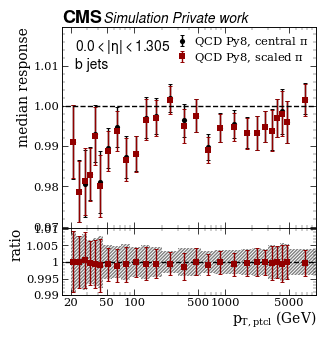

Fitting subsample:  b
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_b_eta1p305to2p5.pdf / .png


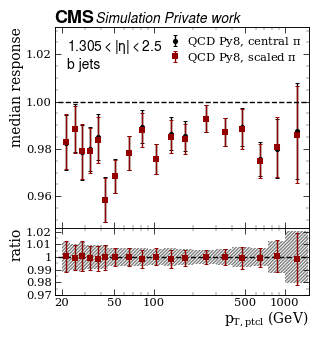

Fitting subsample:  b
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_b_eta2p5to3p139.pdf / .png


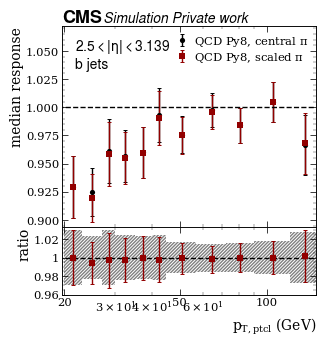

Fitting subsample:  b
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_b_eta3p139to5p191.pdf / .png


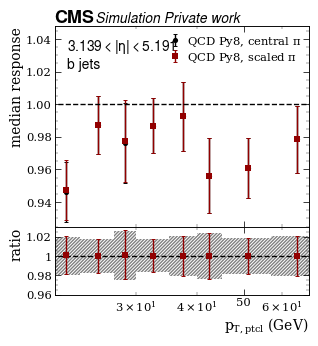

Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Fitting subsample:  bbar
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_bbar_eta0p0to1p305.pdf / .png


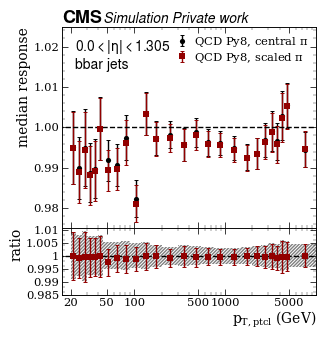

Fitting subsample:  bbar
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_bbar_eta1p305to2p5.pdf / .png


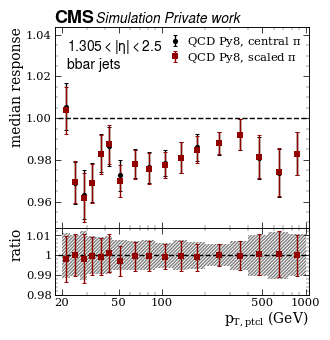

Fitting subsample:  bbar
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_bbar_eta2p5to3p139.pdf / .png


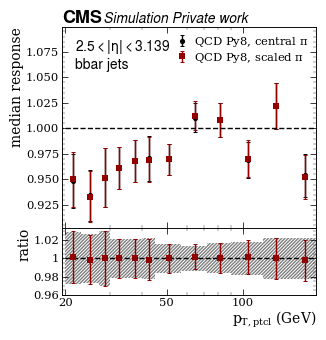

Fitting subsample:  bbar
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_bbar_eta3p139to5p191.pdf / .png


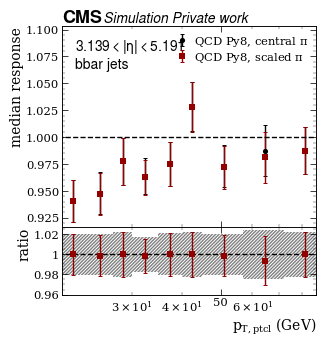

Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Fitting subsample:  c
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_c_eta0p0to1p305.pdf / .png


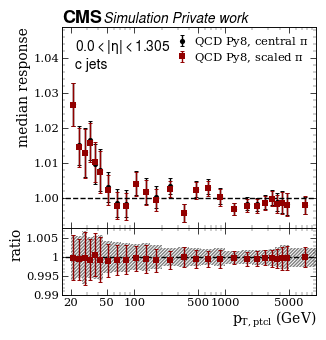

Fitting subsample:  c
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_c_eta1p305to2p5.pdf / .png


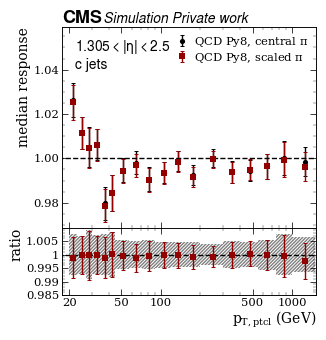

Fitting subsample:  c
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_c_eta2p5to3p139.pdf / .png


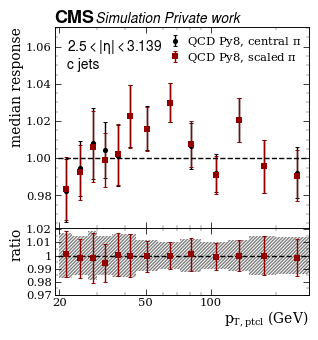

Fitting subsample:  c
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_c_eta3p139to5p191.pdf / .png


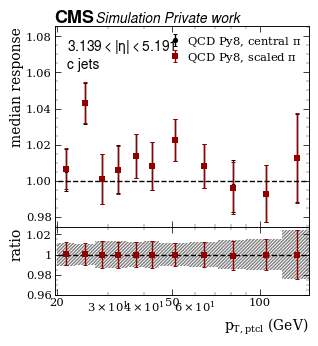

Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Fitting subsample:  cbar
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_cbar_eta0p0to1p305.pdf / .png


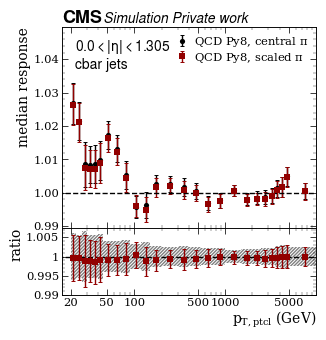

Fitting subsample:  cbar
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_cbar_eta1p305to2p5.pdf / .png


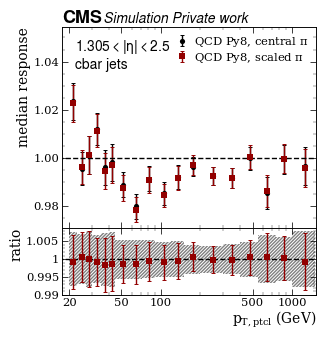

Fitting subsample:  cbar
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_cbar_eta2p5to3p139.pdf / .png


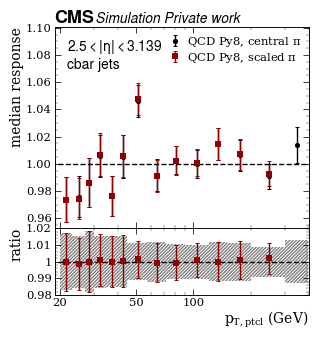

Fitting subsample:  cbar
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_cbar_eta3p139to5p191.pdf / .png


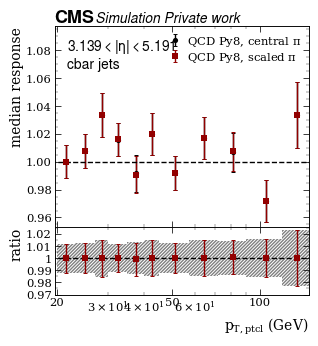

Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Fitting subsample:  s
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_s_eta0p0to1p305.pdf / .png


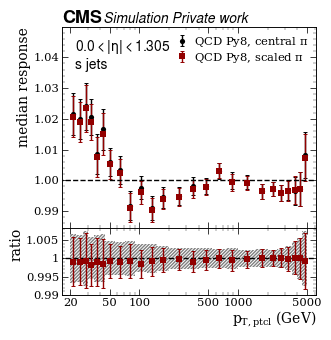

Fitting subsample:  s
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_s_eta1p305to2p5.pdf / .png


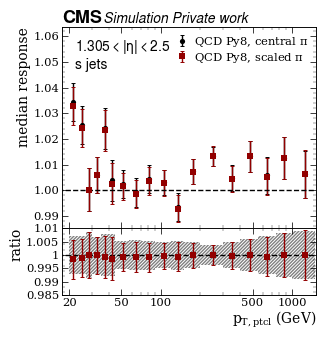

Fitting subsample:  s
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_s_eta2p5to3p139.pdf / .png


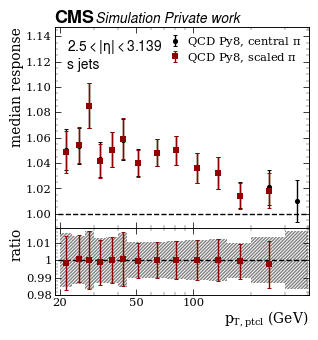

Fitting subsample:  s
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_s_eta3p139to5p191.pdf / .png


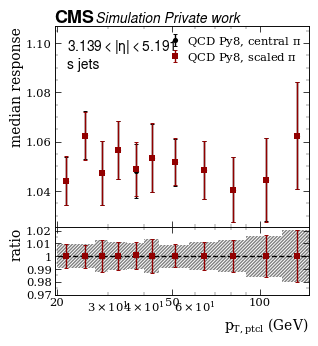

Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Fitting subsample:  sbar
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_sbar_eta0p0to1p305.pdf / .png


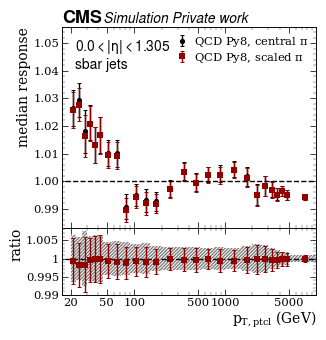

Fitting subsample:  sbar
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_sbar_eta1p305to2p5.pdf / .png


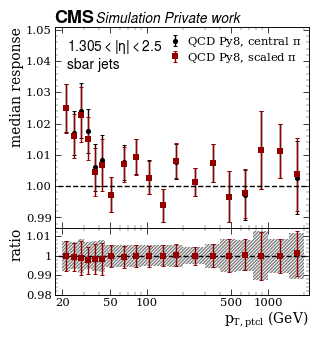

Fitting subsample:  sbar
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_sbar_eta2p5to3p139.pdf / .png


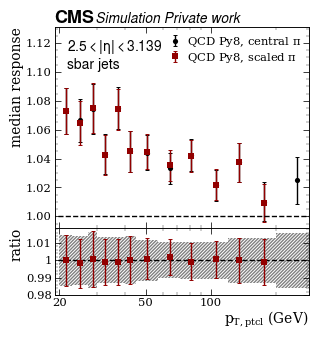

Fitting subsample:  sbar
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_sbar_eta3p139to5p191.pdf / .png


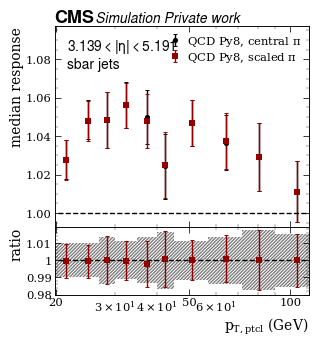

Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Fitting subsample:  ud
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_ud_eta0p0to1p305.pdf / .png


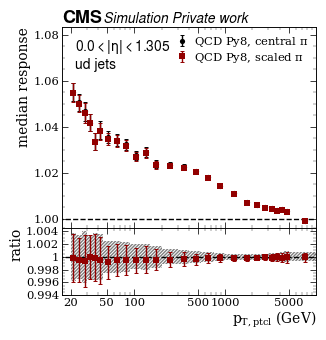

Fitting subsample:  ud
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_ud_eta1p305to2p5.pdf / .png


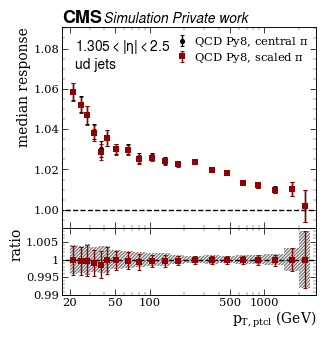

Fitting subsample:  ud
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_ud_eta2p5to3p139.pdf / .png


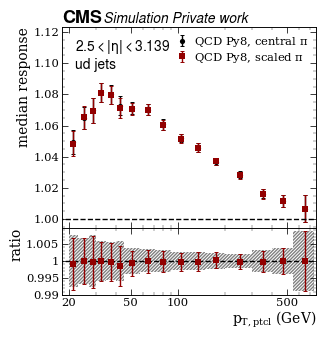

Fitting subsample:  ud
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_ud_eta3p139to5p191.pdf / .png


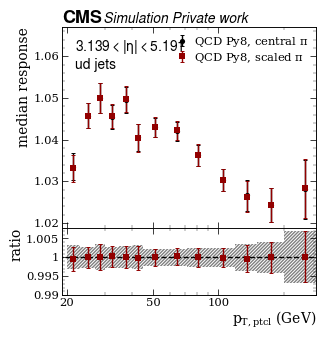

Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Fitting subsample:  udbar
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_udbar_eta0p0to1p305.pdf / .png


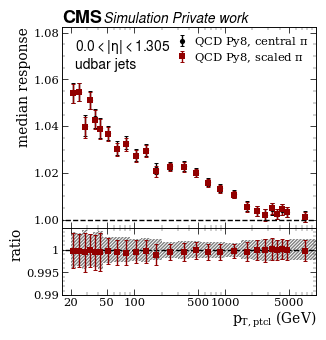

Fitting subsample:  udbar
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_udbar_eta1p305to2p5.pdf / .png


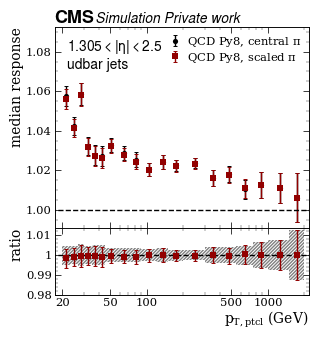

Fitting subsample:  udbar
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_udbar_eta2p5to3p139.pdf / .png


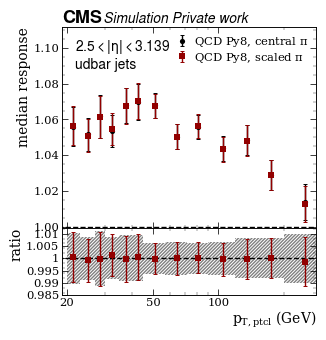

Fitting subsample:  udbar
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_udbar_eta3p139to5p191.pdf / .png


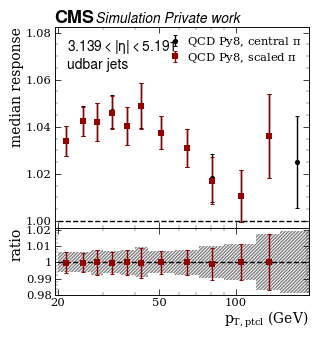

Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Fitting subsample:  q
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_q_eta0p0to1p305.pdf / .png


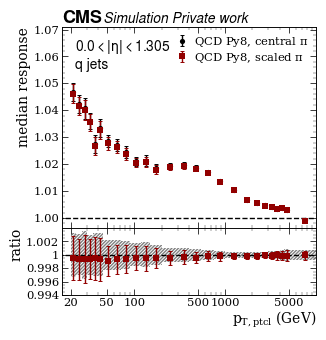

Fitting subsample:  q
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_q_eta1p305to2p5.pdf / .png


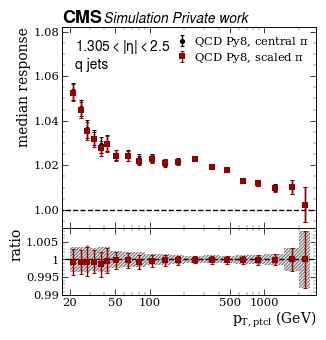

Fitting subsample:  q
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_q_eta2p5to3p139.pdf / .png


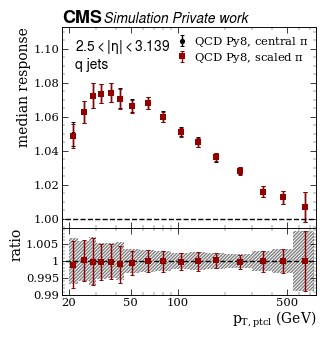

Fitting subsample:  q
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_q_eta3p139to5p191.pdf / .png


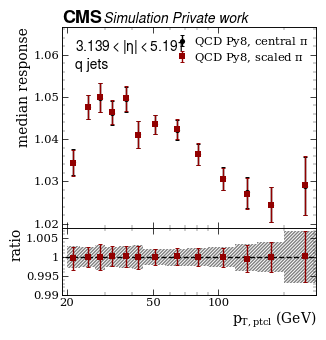

Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Fitting subsample:  qbar
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_qbar_eta0p0to1p305.pdf / .png


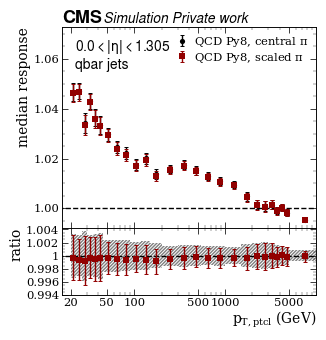

Fitting subsample:  qbar
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_qbar_eta1p305to2p5.pdf / .png


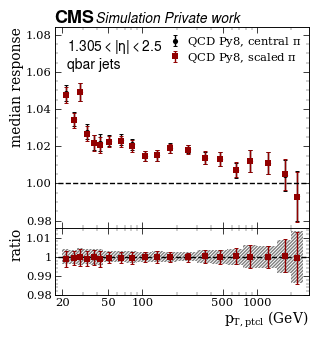

Fitting subsample:  qbar
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_qbar_eta2p5to3p139.pdf / .png


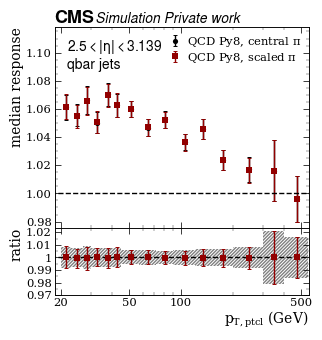

Fitting subsample:  qbar
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_qbar_eta3p139to5p191.pdf / .png


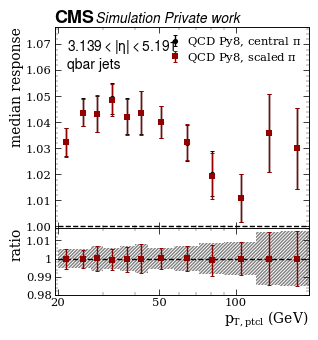

Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Fitting subsample:  unmatched
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_unmatched_eta0p0to1p305.pdf / .png


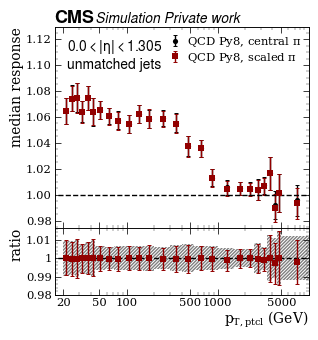

Fitting subsample:  unmatched
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_unmatched_eta1p305to2p5.pdf / .png


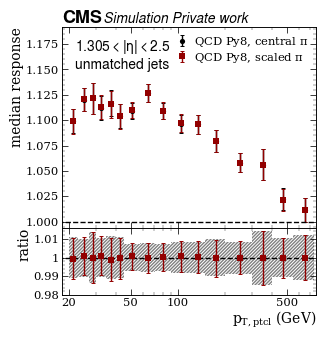

Fitting subsample:  unmatched
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_unmatched_eta2p5to3p139.pdf / .png


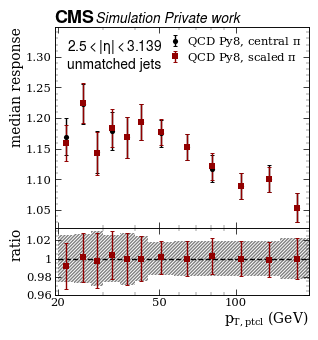

Fitting subsample:  unmatched
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_unmatched_eta3p139to5p191.pdf / .png


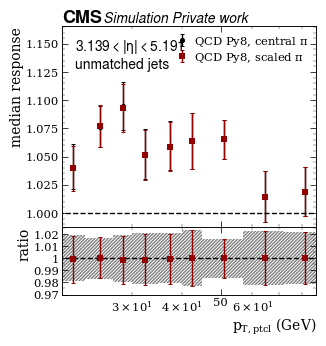

Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Fitting subsample:  all
Eta:  0.6525
Saving plot for eta =  eta0p0to1p305
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_all_eta0p0to1p305.pdf / .png


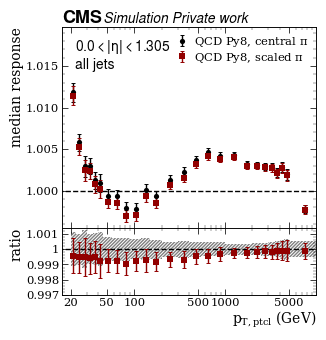

Fitting subsample:  all
Eta:  1.9024999999999999
Saving plot for eta =  eta1p305to2p5
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_all_eta1p305to2p5.pdf / .png


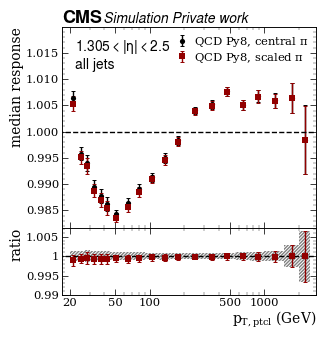

Fitting subsample:  all
Eta:  2.8194999999999997
Saving plot for eta =  eta2p5to3p139
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_all_eta2p5to3p139.pdf / .png


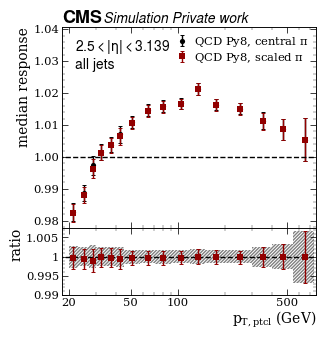

Fitting subsample:  all
Eta:  4.165
Saving plot for eta =  eta3p139to5p191
Saving plot with the name =  fig/med_resp_vs_pt_comparisons/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi/med_resp_vs_pt_L5_QCD_Py8-central_pi-QCD_Py8-scaled_pi_all_eta3p139to5p191.pdf / .png


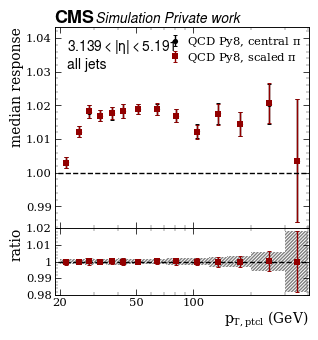

In [15]:
# flavors = ['all', 'b', 'c', 'd', 'u', 's', 'g', 'ud', 'q', 'unmatched']
flavors = ['b', 'bbar', 'c', 'cbar', 's', 'sbar', 'ud', 'udbar', 'q', 'qbar', 'unmatched', 'all']
plotvspt = True
eta_binning  = "HCalPart"  ### HCalPart, JERC, CoarseCalo, CaloTowers, Summer20Flavor, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
etabins = JetEtaBins(eta_binning, absolute=True)
ptbins = PtBins("MC_truth")

tag1 = '_L5_not_scaled_pion'+'_split_antiflav'+eta_binning_str
tag2 = '_L5_scaled_pion'+'_split_antiflav'+eta_binning_str
tag3 = '_L5_scaled_times2_pion'+'_split_antiflav'+eta_binning_str
tag4 = '_L5_scaled_times5_pion'+'_split_antiflav'+eta_binning_str
tag5 = '_L5_scaled_times10_pion'+'_split_antiflav'+eta_binning_str

# tag1 = '_L5_DY-MG-Py'
# tag2 = '_L5_DY-MG-Her'

mean_name = "Median"
mean_name_std = mean_name+'Std'
# closure_Py = read_data2(mean_name, 'all', tag1)
# closure_Py2 = read_data2(mean_name, 'all', tag3)
# closure_Py3 = read_data2(mean_name, 'all', tag5)
# closure_Py = read_data(mean_name, 'all', tag3)



for flav in flavors:
    data_to_read = {
        # label_on_plot: data_list,
        f"QCD Py8, central $\pi$": read_data4plot(tag1), # np.array(read_data4plot(flav, tag1)), #[:,:-1,:],
        f"QCD Py8, scaled $\pi$": read_data4plot(tag2), #[:,:-1,:],
#         f"QCD Py8, scaled $\pi$ x2": read_data4plot(tag3), #[:,:-1,:],
#         f"QCD Py8, scaled $\pi$ x5": read_data4plot(tag4), #[:,:-1,:],
#         f"QCD Py8, scaled $\pi$ x10": read_data4plot(tag5), #[:,:-1,:],
#         f"QCD Py8, scaled $\pi$ x100": np.array(read_data4plot(flav, tag3)), #[:,:-1,:],

    }

    for k in etabins.get_bin_idx([0, 1.305, 2.5, 4]):
        data = {tag:data_to_read[tag][flav] for tag in data_to_read}
        data = {key:np.array([data[key][mean_name], data[key][mean_name_std], data[key]["MeanRecoPt"]]) for key in data}
        print('Fitting subsample: ', flav)
        print('Eta: ', etabins.centres[k]) if plotvspt else print('pt: ', ptbins.centres[k])
        if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
            continue
        
        make_comparison_plot(data, 
                          {},
                          etabins, ptbins,
                          binidx=k, flav=flav, ratio_name='ratio', inverse=False, plotvspt=True)
        
3;

### Comparison with old corrections

In [9]:
Aut18_samples = ['all', 'b', 'c', 's', 'ud', 'g' ]
Sum16_samples = ['b', 'c', 's', 'ud', 'g' ]

In [10]:
list_corr_Sum16 = ["Summer16_07Aug2017_V15_Flavor_Pythia8_MC_"+samp+"_L5Flavor_AK4PFchs.txt" for samp in Sum16_samples]
list_corr_Sum16.append("Summer16_07Aug2017_V15_Flavor_Pythia8_MC_L2Relative_AK4PFchs.txt")
list_corr_Sum16.append("Summer16_07Aug2017_V15_Flavor_Pythia8_MC_L3Absolute_AK4PFchs.txt")
corr_loc_Sum16 = ["* * ../Summer16_07Aug2017_V15_Flavor_Pythia8_MC/"+corr for corr in list_corr_Sum16]
list_corr_Aut18 = ["Autumn18_V3_MC_Pythia8_"+samp+"_L2Relative_AK4PFchs.txt" for samp in Aut18_samples]
corr_loc_Aut18 = ["* * ../Autumn18_V3_MC_Pythia8/"+corr for corr in list_corr_Aut18]
corr_loc_Winter14 = ["* * ../Winter14_V8_MC_L5Flavor/Winter14_V8_MC_L5Flavor_AK5PFchs.txt"]
# corr_loc_Sum20 = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Py.txt"]
# corr_loc_Sum20Her = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Her.txt"]
# corr_loc_Sum20_fineta = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Py_fineeta.txt"]
# corr_loc_Sum20Her_fineta = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Her_fineeta.txt"]
# corr_loc_Sum20_coarseCalo = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Py_CoarseCalo.txt"]
# corr_loc_Sum20Her_coarseCalo = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Her_CoarseCalo.txt"]
# corr_loc_Sum20_JERC = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Py_JERC.txt"]
# corr_loc_Sum20Her_JERC = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Her_JERC.txt"]
# corr_loc_Sum20standPy_CoarseCalo = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_standalonePyQCD_CoarseCalo.txt"]
# corr_loc_Sum20standPy = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_standalonePyQCD.txt"]
# corr_loc_Sum20Her_JERC = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Her_JERC.txt"]
# corr_loc_Sum20standPy_JERC = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_standalonePyQCD_CaloTowers.txt"]
# corr_loc_Sum20Her_CoarseCalo = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_MGQCD_Her.txt"]
corr_loc_Sum20_CoarseCalo    = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_CoarseCalo.txt"]
corr_loc_Sum20Her_Summer20Flavor = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_MGQCD_Her.txt"]
corr_loc_Sum20_Summer20Flavor    = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_MGQCD.txt"]
# corr_loc_Sum20Her_HCAL = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_simfit_Her_HCalPart.txt"]
# corr_loc_Sum20_HCAL    = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_standalonePy_simfit_HCalPart.txt"]
# corr_loc_Sum20_HCAL    = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_MGQCD_HCalPart.txt"]

list_corr_Aut18 = ["Autumn18_V3_MC_Herwig7_"+samp+"_L2Relative_AK4PFchs.txt" for samp in Aut18_samples]
corr_loc_Aut18_Her = ["* * ../Autumn18_V3_MC_Pythia8/"+corr for corr in list_corr_Aut18]
# corr_loc_Sum20_Her = ["* * ../Summer20UL18_V2_MC/Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Her-etaAut18.txt"]

In [11]:
ext = extractor()
ext.add_weight_sets(corr_loc_Sum16+corr_loc_Aut18+corr_loc_Winter14
                    # +corr_loc_Sum20+corr_loc_Sum20Her
                    # +corr_loc_Sum20_fineta+corr_loc_Sum20Her_fineta
                    # +corr_loc_Sum20_coarseCalo+corr_loc_Sum20Her_coarseCalo
                    +corr_loc_Sum20_CoarseCalo
                    +corr_loc_Aut18_Her
                    # +corr_loc_Sum20standPy_JERC+corr_loc_Sum20standPy_CoarseCalo
                    +corr_loc_Sum20Her_Summer20Flavor+corr_loc_Sum20_Summer20Flavor) #+corr_loc_Sum20_Her)
ext.finalize()

# ext._names
evaluator = ext.make_evaluator()
# evo = evaluator['Autumn18_V3_MC_Pythia8_b_L2Relative_AK4PFchs']
# evaluator['Autumn18_V3_MC_Herwig7_b_L2Relative_AK4PFchs']
# evaluator['Autumn18_V3_MC_Herwig7_b_L2Relative_AK4PFchs']

In [12]:
from uncertainty_plotters import color_scheme
# 
# custom_cols = [color_scheme['QCD']['color'], color_scheme['TTBAR']['color'], color_scheme['DY']['color']]
custom_cols = [color_scheme['QCD']['color'], color_scheme['TTBAR']['color'], color_scheme['DY']['color']]

Warning in <TInterpreter::ReadRootmapFile>: class  HepMC3::FourVector found in libSimDataFormatsGeneratorProducts.so  is already in libHepMC3rootIO.so 
Warning in <TInterpreter::ReadRootmapFile>: class  HepMC3::GenEventData found in libSimDataFormatsGeneratorProducts.so  is already in libHepMC3rootIO.so 
Warning in <TInterpreter::ReadRootmapFile>: class  HepMC3::GenParticleData found in libSimDataFormatsGeneratorProducts.so  is already in libHepMC3rootIO.so 
Warning in <TInterpreter::ReadRootmapFile>: class  HepMC3::GenVertexData found in libSimDataFormatsGeneratorProducts.so  is already in libHepMC3rootIO.so 
Warning in <TInterpreter::ReadRootmapFile>: class  HepMC::FourVector found in libSimDataFormatsGeneratorProducts.so  is already in libHepMC3rootIO.so 


Welcome to JupyROOT 6.28/04


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.interpolate import CubicSpline
from cycler import cycler
import os
import mplhep as hep
from fileNames.available_datasets import legend_labels
    
from common_binning import JERC_Constants
from JetEtaBins import JetEtaBins, PtBins

def find_eta_str(plotvspt, binval, correction_fnc, name):
    eta_str = ''
    if plotvspt:
        corr_etabins = correction_fnc._bins['JetEta'] 
        corr_bin_idx = np.searchsorted(corr_etabins, binval, side='right')-1
#         assert False
        if corr_bin_idx==len(corr_etabins):
            corr_bin_idx-=1
        if 'Run 1' in name:
            eta_str = r', {:0.1f}$<|\eta|<${:0.1f}'.format(corr_etabins[corr_bin_idx], corr_etabins[corr_bin_idx+1])
    return eta_str

def make_comparison_plot(data_dict,
                              function_dict,
                              etabins=JetEtaBins("HCalPart", absolute=True), #np.array(JERC_Constants.etaBinsEdges_CaloTowers_full()),
                              ptbins=PtBins("MC_truth"), #np.array(JERC_Constants.ptBinsEdgesMCTruth()),
                              binidx=0, flav='b',
                              pt_min = 17,
                              ratio_name='ratio',
                              inverse=True, plotvspt=True, ratio_ylim=None, ylim=None,
                              reset_colors = True,
                              custom_colors = None,
                              extra_text='',):
    ''' Make a plot of the jet energy response vs pt for the data points in the dictionary `data_dict`
    Compare with with lines obtained from coffea evaluators in `function_dict`.
    `function_dict` can be None than, no lines are shown.
    A ratio plot is drawn vs the first entry in `data_dict`.
    For the legends and figure name the flavor `flav` and eta bin values with the index `etaidx` are used.
    reset_colors: if match the colors of the first points to the colors of the first lines
    '''
   
    ########### Retreive the data from the dictionary and some logic with it ############
    keys = [key for key in data_dict.keys()]
    start = ptbins.get_bin_idx(pt_min) if plotvspt else 0 #np.searchsorted(ptbins, 20, side='left')
    end = ptbins.nbins if plotvspt else etabins.nbins

    data_range = tuple([range(start,end),binidx]) if plotvspt else tuple([binidx, range(start,end)])
    yvals = np.array([key[0][data_range] for key in data_dict.values()])
    # end = np.min([len(yv) for yv in yvals])+start #cut, so that all yvals are the same
    stds  = np.array([key[1][data_range] for key in data_dict.values()])
    reco_pts  = np.array([key[2][data_range] if len(key[2].shape)==2 else key[2][data_range] for key in data_dict.values()])

    ### Replacing response values to corrections
    use_recopt=inverse
    if not plotvspt:
        use_recopt=False
        
    yvals[(yvals==0) | (np.abs(yvals)==np.inf)] = np.nan
    bins = etabins if plotvspt else ptbins

    if plotvspt:
        xvals = reco_pts if use_recopt else np.array([ptbins.centres[start:end]]*len(yvals))
    else:
        xvals = np.array([etabins.centres[start:end]]*len(yvals))
    validx = (xvals>0)*(yvals>0)
    
    linspacefun = np.geomspace if plotvspt else np.linspace
    if np.sum(validx) != 0:
        xvals_cont = linspacefun(np.min(xvals[validx]), np.max(xvals[validx]), 100)
    else:
        xvals_cont = linspacefun(np.min(xvals), np.max(xvals), 100)
                                    # for name in function_dict.keys()}
    ### values for splines can only be in a valid range while for corrections evaluators they can go out of range
    ### so one needs to define two xvals
    validx_all = np.logical_not(np.any(np.logical_not(validx), axis=0))
    if np.sum(validx_all) == 0:
        validx_all = np.ones(validx_all.shape)==1
    xspline = linspacefun(np.min(xvals[0,validx_all]),  np.max(xvals[0,validx_all]), 100)
    xlog10_spline = np.log10(xspline)

    bins2 = ptbins if plotvspt else etabins
    wd = np.abs(np.diff(bins2.edges))[start:end] #bin_widths

    if inverse==True:
        yvals = 1/yvals
        ### Error propagation
        stds = yvals**2*stds

    if plotvspt:
        eta_str = r'{:0.2f}$<|\eta|<${:0.2f}'.format(etabins.edges[binidx], etabins.edges[binidx+1])
    else:
        eta_str = 'to be implemented'

    ########### End of retreive the data from the dictionary and some logic with it ############

    fig = plt.figure()
    gs = fig.add_gridspec(nrows=2, ncols=1, hspace=0, height_ratios=[3, 1])
    ax = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    
    # Set up a new cycler to set up colors of the lines match to the colors of the points and all start with black
    # , while for the ratio plot to start with the second marker and color
    old_rc_cycler = plt.rcParams['axes.prop_cycle']
    rc_bykey = old_rc_cycler.by_key()
    for key in rc_bykey.keys():
        if key=='color':
            rc_bykey[key] = ['k']+rc_bykey[key] if custom_colors is None else custom_colors+rc_bykey[key][:len(rc_bykey[key])-len(custom_colors)+1]
        else:
            rc_bykey[key] = rc_bykey[key]+[rc_bykey[key][-1]]
    new_cycler = cycler(**rc_bykey)

    ############################ Start of the top plot ############################
    ax.set_prop_cycle(new_cycler)
    p1 = ax.errorbar(xvals[0], yvals[0], yerr=stds[0], #marker='o',
                     capsize=1.6, capthick=0.7, linewidth=1.0,
    #                      markerfacecolor='none', markeredgewidth=1,
                     linestyle="none", label=keys[0]) #+', '+eta_str)

    for xval, yval, name, std in zip(xvals[1:], yvals[1:], keys[1:], stds[1:]):
        ax.errorbar(xval, yval, yerr=std, #marker=marker,
                    capsize=1.6, capthick=0.7, linewidth=1.0,
                    linestyle="none", label=name)

    if reset_colors:
        ax.set_prop_cycle(new_cycler)

    yvals_cont = {}
    yvals_spline = {}
    for name in function_dict.keys():
        correction_fnc, closure = function_dict[name]
        xv_cont = xvals_cont
        if closure is None or closure==1:
            def closure(a,b):
                return np.ones_like(a*b)
        #to ensure that the correction is applied from the right side of the bin border
        binval = bins.edges[binidx]+0.001
        vals_cont = (np.array([binval]), xv_cont) if plotvspt else (xv_cont, np.array([binval]))
        vals_spline = (np.array([binval]), xspline) if plotvspt else (xspline, np.array([binval]))
        yvals_cont[name] = correction_fnc(*vals_cont)/closure(*vals_cont)
        yvals_spline[name] = correction_fnc(*vals_spline)/closure(*vals_spline)
        
        eta_str = find_eta_str(plotvspt, binval, correction_fnc, name)
    #     eta_str = ''
    #     if plotvspt:
    #         corr_etabins = correction_fnc._bins['JetEta'] 
    #         corr_bin_idx = np.searchsorted(corr_etabins, binval, side='right')-1
    # #         assert False
    #         if corr_bin_idx==len(corr_etabins):
    #             corr_bin_idx-=1
    #         if 'Run 1' in name:
    #             eta_str = ', \n'+r' {:0.1f}$<|\eta|<${:0.1f}'.format(corr_etabins[corr_bin_idx], corr_etabins[corr_bin_idx+1])
            
        ax.plot(xv_cont, yvals_cont[name], label=name+eta_str, markersize=0) # +', '+eta_str, markersize=0)

    if not plotvspt:
        for HCal_border in JERC_Constants.etaBinsEdges_Win14():
            ax.vlines(HCal_border,0, 2, linestyles='--',color="gray",
                linewidth=1,)

    ############################ End of the top plot ############################
    ############################ Data ratio plot ######################################
    
    ax2.hlines(1,-10, 10000, linestyles='--',color="black", 
               linewidth=1,)
    if not plotvspt:
        for HCal_border in JERC_Constants.etaBinsEdges_Win14():
            ax2.vlines(HCal_border,0, 2, linestyles='--',color="gray",
                linewidth=1,)
    
    data_model_ratio = yvals/yvals[0]
    data_model_ratio_unc = stds / yvals[0]
    
    non_nan_ratio = ~np.isnan(data_model_ratio_unc[0])

    ax2.bar(
        xvals[0, non_nan_ratio],
        2 * data_model_ratio_unc[0][non_nan_ratio],
        width=wd[non_nan_ratio],
        bottom=1.0 - data_model_ratio_unc[0][non_nan_ratio],
        fill=False,
        linewidth=0,
        edgecolor="gray",
        hatch=10 * "/",
    )

    rc_bykey = new_cycler.by_key().copy()
    for key in rc_bykey:
        rc_bykey[key] = rc_bykey[key][1:]
    shifted_cycler = cycler(**rc_bykey)
    ax2.set_prop_cycle(shifted_cycler)

    for xval, val, std in zip(xvals[1:], data_model_ratio[1:], data_model_ratio_unc[1:]): #, markers):
        ax2.errorbar(
            xval,
            val, #[nonzero_model_yield],
            yerr=std, #[nonzero_model_yield],
            linestyle="none",
            capsize=1.6, capthick=0.7, linewidth=1.0,
            #fmt=marker,
        )

    ############################ Curves in the ratio plot (using spline approximation) #######
    if reset_colors:
        ax2.set_prop_cycle(new_cycler)
        
    if np.sum(validx) != 0:
        spline_func = CubicSpline(np.log10(xvals[0][validx[0]]), yvals[0][validx[0]], bc_type='natural')
    else:
        spline_func = CubicSpline([1,1], [-5,5], bc_type='natural') if plotvspt else CubicSpline([1,1], [20,100], bc_type='natural')
    y_spline = spline_func(xlog10_spline)

    for key in yvals_spline.keys():
        ax2.plot(xspline, yvals_spline[key]/y_spline, markersize=0)

    ax2.set_ylabel(ratio_name)
    # ax2.tick_params(axis="both", which="major", pad=8)
    # ax2.tick_params(direction="in", top=True, right=True, which="both")
    # fig.set_tight_layout(True)

    ######################## Calculate resonable limits excluding the few points with insane errors ############################
    if np.sum(validx) != 0:
        ### Recalculate the limits for the top ax
        yerr_norm = np.concatenate([stds])
        y_norm = np.concatenate([yvals])
        norm_pos = (yerr_norm<0.04) &  (yerr_norm != np.inf) & (y_norm>-0.1)
        left_lim = np.min((y_norm-yerr_norm)[norm_pos])
        right_lim = np.max((yerr_norm+y_norm)[norm_pos])
        lim_pad = (right_lim - left_lim)/1.5
        ax.set_ylim(left_lim-lim_pad/10, right_lim+lim_pad)

        if not ratio_ylim==None:
            ax2.set_ylim(ratio_ylim)

        if not ylim==None:
            ax.set_ylim(ylim)
        # else:
        #     ### Recalculate the limits for the ratio plot
        #     yerr_norm = np.concatenate(data_model_ratio_unc)
        #     y_norm = np.concatenate(data_model_ratio)
        #     norm_pos = (yerr_norm<0.4) &  (yerr_norm != np.inf) & (y_norm>-0.1)
        #     if ~np.any(norm_pos):
        #         print("Cannot determine ylimits")
        #     else:
        #         # raise Exception("Cannot determine ylimits")
        #         left_lim = np.min((y_norm-yerr_norm)[norm_pos])
        #         right_lim = np.max((yerr_norm+y_norm)[norm_pos])
        #         lim_pad = (right_lim - left_lim)/20
        #         ax2.set_ylim(left_lim-lim_pad, right_lim+lim_pad)
        #         breakpoint()

    if plotvspt:
        xlabel = r'$p_{T,reco}$ (GeV)' if use_recopt else r'$p_{T,ptcl}$ (GeV)'
    else:
        xlabel = r'$|\eta|$'
    ax2.set_xlabel(xlabel);
    ylabel = r'correction (1/median)' if inverse else r'median response'
    ax.set_ylabel(ylabel);
    if plotvspt:
        ax.set_xscale('log')
        ax2.set_xscale('log')

    xlims = ax.get_xlim()
    ax.hlines(1,-10, 10000, linestyles='--',color="black",
              linewidth=1,)

#     ax.set_xticks([])
    if plotvspt:
        ax2.set_xticks([10, 20, 50, 100, 500, 1000, 5000]) 
    ax.set_xticks(ax2.get_xticks())
    ax.set_xticklabels([])
    ax2.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
    leg1 = ax.legend(loc="upper right", ncol=1)

    if not plotvspt:
        xlims = (-0.2, 5.3)
    ax.set_xlim(xlims)
    ax2.set_xlim(xlims)

    ### make the y-axis ticks in the ratio plot look nice: add a decent amount of major and minor ticks
    ax2.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=5, steps=[1, 2, 5, 10]))
    ax2.yaxis.set_minor_locator(mpl.ticker.MaxNLocator(nbins=25, steps=[1, 2, 5, 10])) #mpl.ticker.LinearLocator(numticks=25)
    ### remove the highest tick lavel from the ratio plot as it overlaps with the lowest label from the main plot 
    tick_labels = ax2.get_yticks() 
    tick_labels = [f'{tick:.10g}' for tick in tick_labels]  ### remove floating point digits
    tick_labels = tick_labels[:-1]
    ax2.set_yticks(ax2.get_yticks()[:-1])
    ax2.set_yticklabels(tick_labels)

    # breakpoint()
    ############################ Adding the CMS labels and saving the plots ######################################
    eta_string = bins.idx2str(binidx) #'_eta'+str(etabins_abs[etaidx])+'to'+str(etabins_abs[etaidx+1])
#     eta_string = eta_string.replace('.','')
    fig_corr_name = 'corr' if inverse else 'med_resp'
    fig_x_str = 'pt' if plotvspt else 'eta'
    run_name =  f'{fig_corr_name}_vs_{fig_x_str}_L5_'+'-'.join(keys)+'-'.join(function_dict.keys())
    run_name = (run_name.replace(legend_labels["ttbar"]["lab"], 'ttbar').replace(', ', '-')
                .replace(" ", "_").replace("+", "_").replace('(', '').replace(')', '').replace('/', '').replace('\n', '').replace('$', '').replace('\\', '')
    )
    dir_name1 = f'fig/{fig_corr_name}_vs_{fig_x_str}_comparisons/'
    dir_name2 = dir_name1+run_name
    if not os.path.exists(dir_name1):
        os.mkdir(dir_name1)
        print("Creating directory ", dir_name1)
    if not os.path.exists(dir_name2):
        os.mkdir(dir_name2)
        print("Creating directory ", dir_name2)

    hep.cms.label("Private work", loc=0, data=False, ax=ax, rlabel='')
    # hep.cms.label("Preliminary", loc=0, data=False, ax=ax)
    flav_txt = flav.replace('_', ' ')
    hep.label.exp_text(text=f'{bins.idx2plot_str(binidx)}\n{flav_txt} jets'+extra_text, loc=2, ax=ax)
    
    # Add white box underneath the label
    from matplotlib.patches import Rectangle
    rect = Rectangle((0.03, 0.75), 0.45, 0.23, transform=ax.transAxes, 
                     facecolor='white', edgecolor='none', alpha=1.0, zorder=2)
    ax.add_patch(rect)
    
    fig_name = dir_name2+'/'+run_name+"_"+flav+'_'+eta_string
    print("Saving plot for eta = ", eta_string)
    print("Saving plot with the name = ", fig_name+".pdf / .png")
    plt.savefig(fig_name+'.pdf')
    plt.savefig(fig_name+'.png')
    plt.show()

Read data from  ../out_txt/response_fit_results_L5_QCD-Py_CoarseCalo.json
Read data from  ../out_txt/response_fit_results_L5_QCD-Py_CoarseCalo.json
Plotting subsample:  b
Eta:  0
Saving plot for eta =  eta0p0to0p783
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_b_eta0p0to0p783.pdf / .png


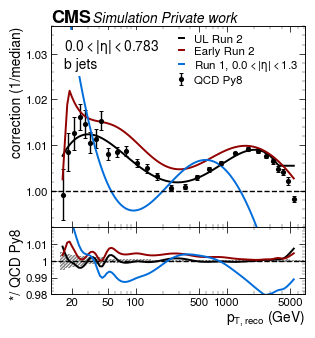

Plotting subsample:  b
Eta:  2
Saving plot for eta =  eta1p305to1p653
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_b_eta1p305to1p653.pdf / .png


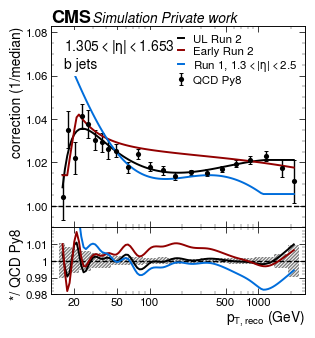

Plotting subsample:  b
Eta:  6
Saving plot for eta =  eta2p5to2p853
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_b_eta2p5to2p853.pdf / .png


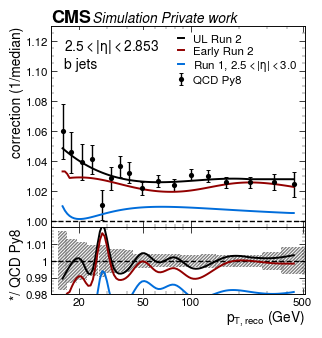

Plotting subsample:  b
Eta:  9
Saving plot for eta =  eta3p489to5p191
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_b_eta3p489to5p191.pdf / .png


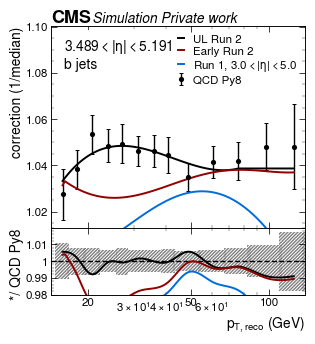

Read data from  ../out_txt/response_fit_results_L5_QCD-Py_CoarseCalo.json
Plotting subsample:  c
Eta:  0
Saving plot for eta =  eta0p0to0p783
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_c_eta0p0to0p783.pdf / .png


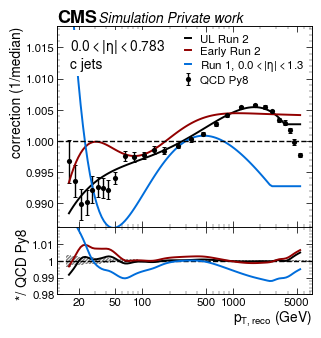

Plotting subsample:  c
Eta:  2
Saving plot for eta =  eta1p305to1p653
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_c_eta1p305to1p653.pdf / .png


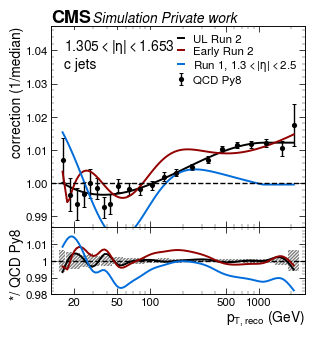

Plotting subsample:  c
Eta:  6
Saving plot for eta =  eta2p5to2p853
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_c_eta2p5to2p853.pdf / .png


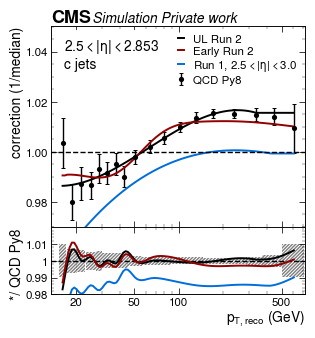

Plotting subsample:  c
Eta:  9
Saving plot for eta =  eta3p489to5p191
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_c_eta3p489to5p191.pdf / .png


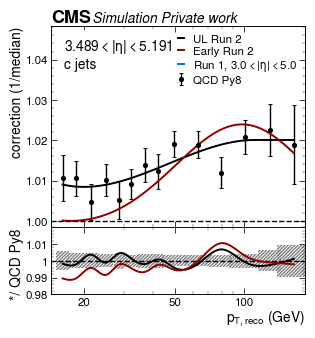

Read data from  ../out_txt/response_fit_results_L5_QCD-Py_CoarseCalo.json
Plotting subsample:  d
Eta:  0
Saving plot for eta =  eta0p0to0p783
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_d_eta0p0to0p783.pdf / .png


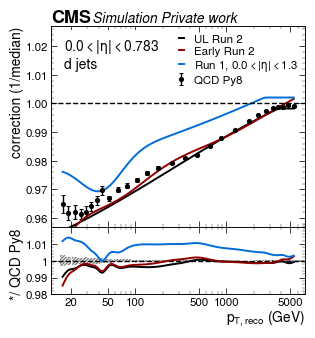

Plotting subsample:  d
Eta:  2
Saving plot for eta =  eta1p305to1p653
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_d_eta1p305to1p653.pdf / .png


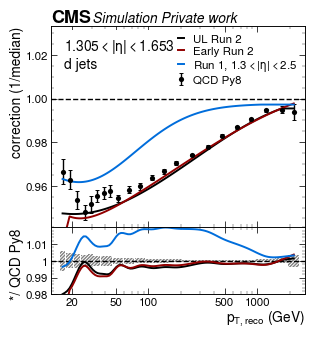

Plotting subsample:  d
Eta:  6
Saving plot for eta =  eta2p5to2p853
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_d_eta2p5to2p853.pdf / .png


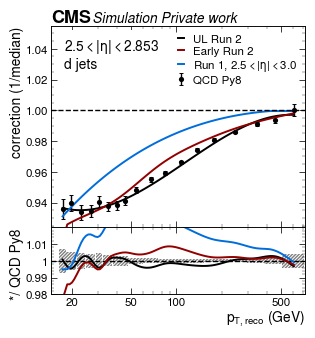

Plotting subsample:  d
Eta:  9
Saving plot for eta =  eta3p489to5p191
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_d_eta3p489to5p191.pdf / .png


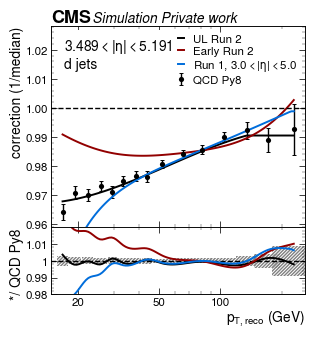

Read data from  ../out_txt/response_fit_results_L5_QCD-Py_CoarseCalo.json
Plotting subsample:  u
Eta:  0
Saving plot for eta =  eta0p0to0p783
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_u_eta0p0to0p783.pdf / .png


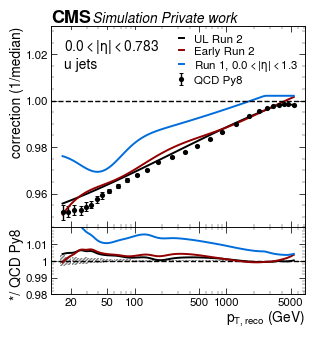

Plotting subsample:  u
Eta:  2
Saving plot for eta =  eta1p305to1p653
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_u_eta1p305to1p653.pdf / .png


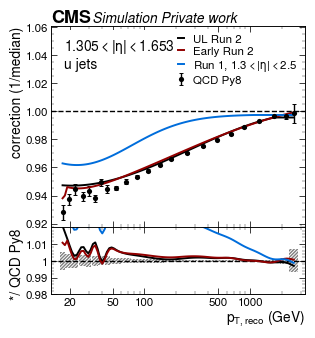

Plotting subsample:  u
Eta:  6
Saving plot for eta =  eta2p5to2p853
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_u_eta2p5to2p853.pdf / .png


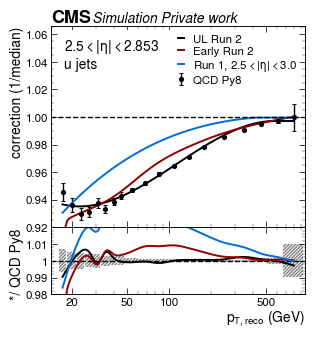

Plotting subsample:  u
Eta:  9
Saving plot for eta =  eta3p489to5p191
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_u_eta3p489to5p191.pdf / .png


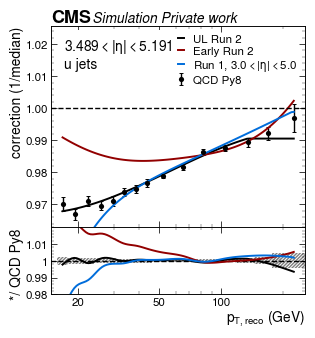

Read data from  ../out_txt/response_fit_results_L5_QCD-Py_CoarseCalo.json
Plotting subsample:  s
Eta:  0
Saving plot for eta =  eta0p0to0p783
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_s_eta0p0to0p783.pdf / .png


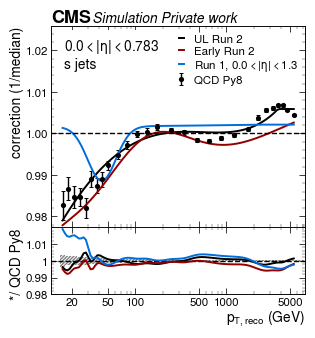

Plotting subsample:  s
Eta:  2
Saving plot for eta =  eta1p305to1p653
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_s_eta1p305to1p653.pdf / .png


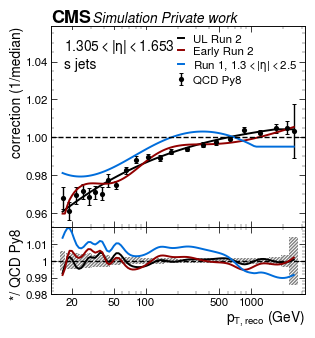

Plotting subsample:  s
Eta:  6
Saving plot for eta =  eta2p5to2p853
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_s_eta2p5to2p853.pdf / .png


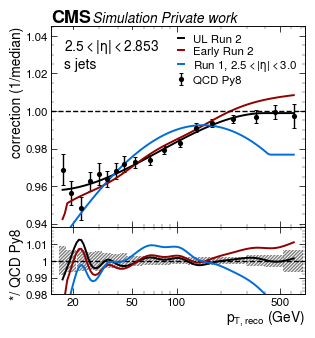

Plotting subsample:  s
Eta:  9
Saving plot for eta =  eta3p489to5p191
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_s_eta3p489to5p191.pdf / .png


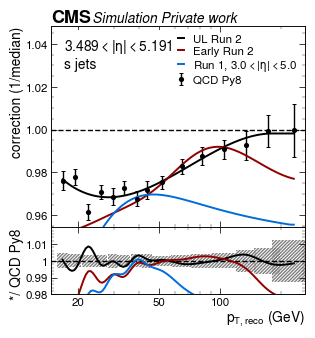

Read data from  ../out_txt/response_fit_results_L5_QCD-Py_CoarseCalo.json
Plotting subsample:  g
Eta:  0
Saving plot for eta =  eta0p0to0p783
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_g_eta0p0to0p783.pdf / .png


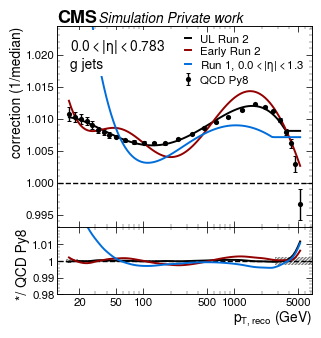

Plotting subsample:  g
Eta:  2
Saving plot for eta =  eta1p305to1p653
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_g_eta1p305to1p653.pdf / .png


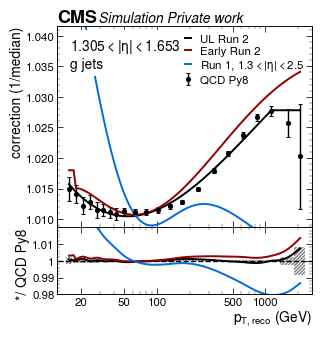

Plotting subsample:  g
Eta:  6
Saving plot for eta =  eta2p5to2p853
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_g_eta2p5to2p853.pdf / .png


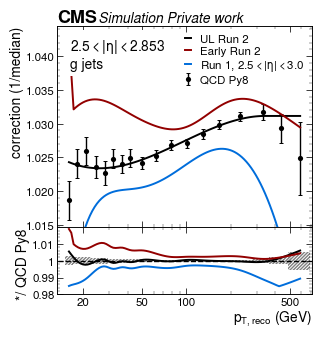

Plotting subsample:  g
Eta:  9
Saving plot for eta =  eta3p489to5p191
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_g_eta3p489to5p191.pdf / .png


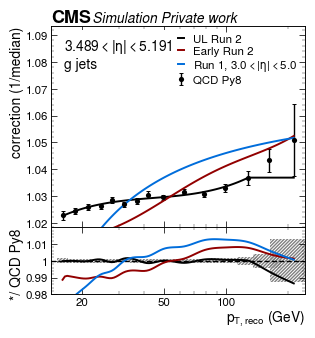

Read data from  ../out_txt/response_fit_results_L5_QCD-Py_CoarseCalo.json
Plotting subsample:  ud
Eta:  0
Saving plot for eta =  eta0p0to0p783
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_ud_eta0p0to0p783.pdf / .png


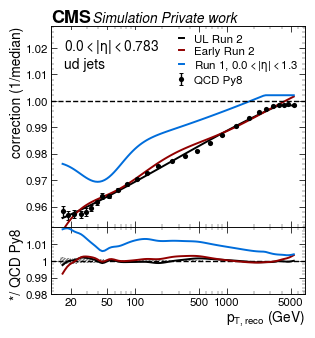

Plotting subsample:  ud
Eta:  2
Saving plot for eta =  eta1p305to1p653
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_ud_eta1p305to1p653.pdf / .png


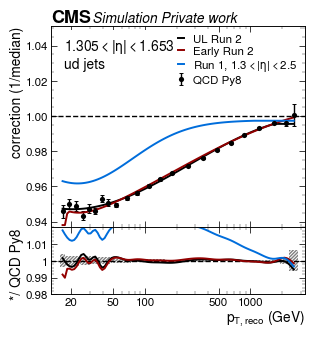

Plotting subsample:  ud
Eta:  6
Saving plot for eta =  eta2p5to2p853
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_ud_eta2p5to2p853.pdf / .png


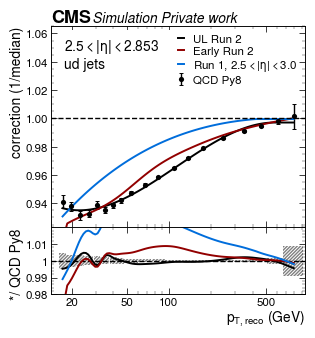

Plotting subsample:  ud
Eta:  9
Saving plot for eta =  eta3p489to5p191
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_ud_eta3p489to5p191.pdf / .png


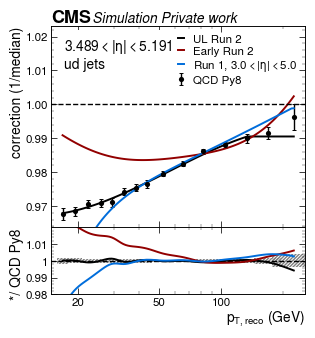

Read data from  ../out_txt/response_fit_results_L5_QCD-Py_CoarseCalo.json
Plotting subsample:  q
Eta:  0
Saving plot for eta =  eta0p0to0p783
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_q_eta0p0to0p783.pdf / .png


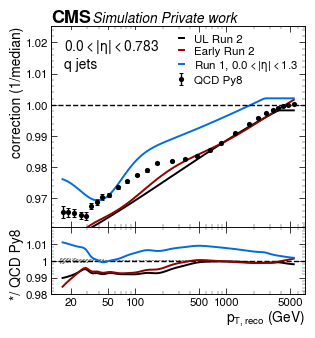

Plotting subsample:  q
Eta:  2
Saving plot for eta =  eta1p305to1p653
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_q_eta1p305to1p653.pdf / .png


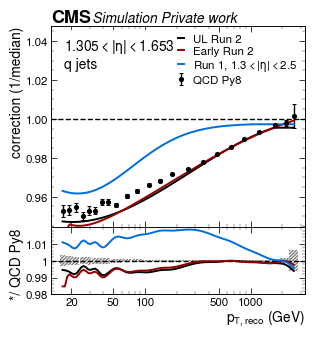

Plotting subsample:  q
Eta:  6
Saving plot for eta =  eta2p5to2p853
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_q_eta2p5to2p853.pdf / .png


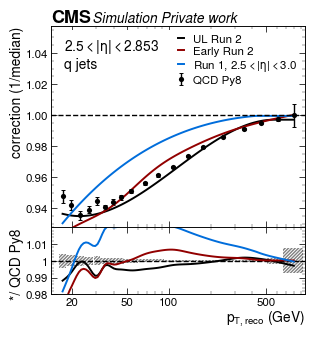

Plotting subsample:  q
Eta:  9
Saving plot for eta =  eta3p489to5p191
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_q_eta3p489to5p191.pdf / .png


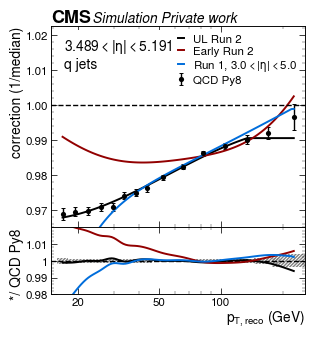

Read data from  ../out_txt/response_fit_results_L5_QCD-Py_CoarseCalo.json
Plotting subsample:  all
Eta:  0
Saving plot for eta =  eta0p0to0p783
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_all_eta0p0to0p783.pdf / .png


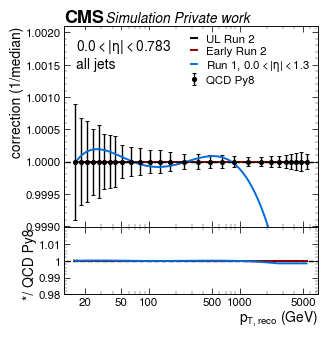

Plotting subsample:  all
Eta:  2
Saving plot for eta =  eta1p305to1p653
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_all_eta1p305to1p653.pdf / .png


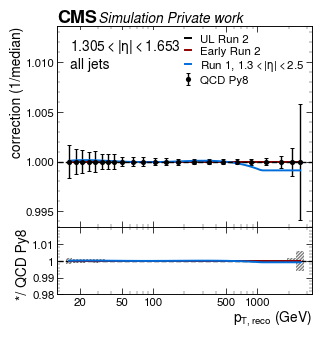

Plotting subsample:  all
Eta:  6
Saving plot for eta =  eta2p5to2p853
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_all_eta2p5to2p853.pdf / .png


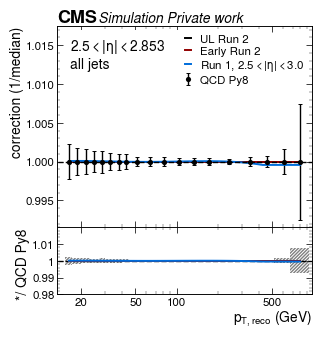

Plotting subsample:  all
Eta:  9
Saving plot for eta =  eta3p489to5p191
Saving plot with the name =  fig/corr_vs_pt_comparisons/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1/corr_vs_pt_L5_QCD_Py8UL_Run_2-Early_Run_2-Run_1_all_eta3p489to5p191.pdf / .png


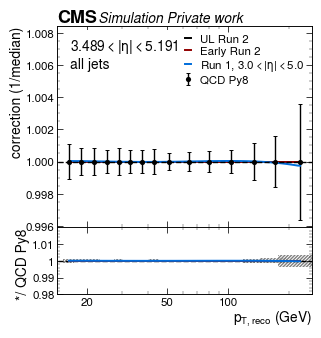

In [38]:
eta_binning  = "CoarseCalo" #"CoarseCalo"  ### HCalPart, JERC, CoarseCalo, CaloTowers, Summer20Flavor, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
eta_binning_str_corr = '_'+eta_binning if eta_binning != "Summer20Flavor" else ''
# load_fit_res=True
# subsamples = ['all', 'b', 'c', 'd', 'u', 's', 'g']
flavors = ['b', 'c', 'd', 'u', 's', 'g', 'ud', 'q', 'all']
# flavors = ['ud','b', 's', 'u', 'd', 'g']
# flavors = ['g']
# etabins = np.array(JERC_Constants.etaBinsEdges_Aut18_full())
# etabins = np.array(JERC_Constants.etaBinsEdges_CaloTowers_full())
# etabins_abs = etabins[(len(etabins)-1)//2:]

# flavors = ['ud', 'b']
# flavors = ['all']
tag1 = '_L5_QCD-Py'+eta_binning_str
# tag1_genwt = '_L5_QCD-Py_genwt'+eta_binning_str
tag2 = '_L5_QCD-MG-Py'+eta_binning_str
tag2Her = '_L5_QCD-MG-Her'+eta_binning_str
tag3 = '_L5_Pythia-TTBAR'+eta_binning_str
tag3Her = '_L5_Herwig-TTBAR'+eta_binning_str
tag4 = '_L5_DY-MG-Py'+eta_binning_str
tag4Her = '_L5_DY-MG-Her'+eta_binning_str

# tag1 = '_L5_QCD-MG-Her'+eta_binning_str
# tag2 = '_L5_QCD-Py'+eta_binning_str
# tag3 = '_L5_QCD-MG-Py'+eta_binning_str
# tag3 = '_L5_QCD-divided'

closure_corr = read_data4plot(tag1)['all']['Median'] #divide by Pythia-standalone QCD

mean_name = "Median"
mean_name_std = mean_name+'Std'

closure_Aut18 = evaluator['Autumn18_V3_MC_Pythia8_all_L2Relative_AK4PFchs']
closure_Sum16 = evaluator['Summer16_07Aug2017_V15_Flavor_Pythia8_MC_L2Relative_AK4PFchs']
etabins = JetEtaBins(eta_binning, absolute=True)
ptbins = PtBins("MC_truth")


for samp in flavors:
    samp_Aut18 = samp
#     samp_Sum20 = '_'+samp
    samp_Aut18 = '_ud' if samp_Aut18=='u' or samp_Aut18=='d' or samp_Aut18=='q' else '_'+samp_Aut18
    
    evo_Her = evaluator[f'Autumn18_V3_MC_Herwig7{samp_Aut18}_L2Relative_AK4PFchs']
    evo = evaluator[f'Autumn18_V3_MC_Pythia8{samp_Aut18}_L2Relative_AK4PFchs']
    if samp_Aut18=='_all':
        evo2 = evaluator['Summer16_07Aug2017_V15_Flavor_Pythia8_MC_L2Relative_AK4PFchs']
    else:
        evo2 = evaluator[f'Summer16_07Aug2017_V15_Flavor_Pythia8_MC{samp_Aut18}_L5Flavor_AK4PFchs']
        
    if samp_Aut18!='_all':
        evo3 = evaluator[f'Winter14_V8_MC_L5Flavor_AK5PFchs{samp_Aut18}J']
        evo4_Py = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs{eta_binning_str}{samp_Aut18}J']
#         evo4 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_MGQCD{eta_binning_str_corr}{samp_Aut18}J']
#         evo4_Her = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_MGQCD{eta_binning_str_corr}_Her{samp_Aut18}J']
#         evo6 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_standalonePyQCD{eta_binning_str}{samp_Aut18}J']
    else:
        evo3 = evaluator[f'Winter14_V8_MC_L5Flavor_AK5PFchs_aJ']
        evo4_Py = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs{eta_binning_str}_aJ']
#         evo4 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs{eta_binning_str}_aJ']
#         evo5 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Her{eta_binning_str}_aJ']
#         evo4 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_MGQCD{eta_binning_str_corr}_aJ']
#         evo4_Her = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_MGQCD{eta_binning_str_corr}_Her_aJ']
#         evo4 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_aJ']
#     evo4 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_MGQCD_HCalPart{samp_Aut18}M']
#     evo4_Her =evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_simfit_Her_HCalPart{samp_Aut18}J']

    data_to_read = {
#             "QCD MG+Py8": read_data4plot(tag2, closure_corr),
            "QCD Py8": read_data4plot(tag1, closure_corr),
#             f"{ttbarlab} Pow+Py8": read_data4plot(tag3, closure_corr),
#             f"ZJets MG+Py8": read_data4plot(tag4, closure_corr),
#             "QCD MG+Her7": read_data4plot(tag2Her, closure_corr),
#             f"{ttbarlab} Pow+Her7": read_data4plot(tag3Her, closure_corr),
#             f"ZJets MG+Her7": read_data4plot(tag4Her, closure_corr),
           }
    
    functions = {
#             "Summer20, Py":    [evo4, None],   
            "UL Run 2":    [evo4_Py, None],
#             "Summer20, Her":   [evo4_Her, None],    
#             "fit":        [evo6, None],

        #             "Summer20, Her":    [evo5, None],
            "Early Run 2":    [evo, closure_Aut18],
            "Run 1":       [evo3, None],
#             "Autumn18_Her":   [evo_Her, closure_Aut18],
            
           }
    
#     for k in range(etabins.nbins):
    for k in etabins.get_bin_idx([0, 1.310, 2.5, 4]):
#     for k in etabins.get_bin_idx([0, 0.522, 0.783]):
#         functions["Run 1\n"+etabins.idx2plot_str(k)] = functions["Run 1"]
#         functions.pop("Run 1")
        data = {tag:data_to_read[tag][samp] for tag in data_to_read}
        data = {key:np.array([data[key][mean_name], data[key][mean_name_std], data[key]["MeanRecoPt"]]) for key in data}
#     for k in range(1):
#     for k in ptbins.get_bin_idx([20, 35, 150, 400]):
        print('Plotting subsample: ', samp)
        print('Eta: ', k)
        if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
#             continue
#         if not np.any(median2[:,k]>-0.1):
            print("All median values are none")
            continue
        
        make_comparison_plot(data, 
                                  functions,
                                  etabins, ptbins,
                                  binidx=k, flav=samp, ratio_name='*/ QCD Py8', ratio_ylim=[0.98,1.02], plotvspt=True, reset_colors=True,
                            pt_min=15)
        
3;


In [ ]:
# eta_binning  = "CaloTowers"  ### HCalPart, JERC, CoarseCalo, CaloTowers, onebin;
# eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
# # load_fit_res=True
# # subsamples = ['all', 'b', 'c', 'd', 'u', 's', 'g']
# flavors = ['b', 'c', 'd', 'u', 's', 'g', 'ud', 'q', 'all']
# # flavors = ['all']
# # etabins = np.array(JERC_Constants.etaBinsEdges_Aut18_full())
# # etabins = np.array(JERC_Constants.etaBinsEdges_CaloTowers_full())
# # etabins_abs = etabins[(len(etabins)-1)//2:]

# # flavors = ['ud', 'b']
# # flavors = ['all']

# # tag1 = '_L5_QCD-MG-Her'+eta_binning_str
# tag2 = '_L5_QCD-Py'+eta_binning_str
# # tag2 = '_L5_QCD-MG-Py'+eta_binning_str
# # tag3 = '_L5_QCD-divided'

# closure_corr = read_data2("Median", "all", tag2) #divide by Pythia

# mean_name = "Median"
# mean_name_std = mean_name+'Std'

# closure_Aut18 = evaluator['Autumn18_V3_MC_Pythia8_all_L2Relative_AK4PFchs']
# closure_Sum16 = evaluator['Summer16_07Aug2017_V15_Flavor_Pythia8_MC_L2Relative_AK4PFchs']
# etabins = JetEtaBins(eta_binning, absolute=True)


# for samp in flavors:
#     samp_Aut18 = samp
# #     samp_Sum20 = '_'+samp
#     samp_Aut18 = '_ud' if samp_Aut18=='u' or samp_Aut18=='d' or samp_Aut18=='q' else '_'+samp_Aut18
    
#     evo_Her = evaluator[f'Autumn18_V3_MC_Herwig7{samp_Aut18}_L2Relative_AK4PFchs']
#     evo = evaluator[f'Autumn18_V3_MC_Pythia8{samp_Aut18}_L2Relative_AK4PFchs']
#     if samp_Aut18=='_all':
#         evo2 = evaluator['Summer16_07Aug2017_V15_Flavor_Pythia8_MC_L2Relative_AK4PFchs']
#     else:
#         evo2 = evaluator[f'Summer16_07Aug2017_V15_Flavor_Pythia8_MC{samp_Aut18}_L5Flavor_AK4PFchs']
        
#     if samp_Aut18!='_all':
#         evo3 = evaluator[f'Winter14_V8_MC_L5Flavor_AK5PFchs{samp_Aut18}J']
# #         evo4 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Py-etaAut18{samp_Aut18}J']
#         evo4 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_standalonePyQCD{eta_binning_str}{samp_Aut18}J']
# #         evo5 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Her{eta_binning_str}{samp_Aut18}J']
#     else:
#         evo3 = evaluator[f'Winter14_V8_MC_L5Flavor_AK5PFchs_aJ']
#         evo4 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_standalonePyQCD{eta_binning_str}_aJ']
# #         evo5 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Her{eta_binning_str}_aJ']
# #         evo4 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_aJ']
# #     evo4 = evaluator[f'Winter14_V8_MC_L5Flavor_AK5Calo{samp_Aut18}J']
# #     evo4_Her = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Her{samp_Aut18}J']

#     data = {
#             "20UL18": read_data4plot(samp, tag2, closure_corr),
# #             "20UL18, Her": read_data4plot(samp, tag1, closure_corr)
#            }
    
#     functions = {
# #             "Summer20_Her":   [evo4_Her, None],
#             "Summer20":    [evo4, None],    
# #             "Summer20, Her":    [evo5, None],
#             "Autumn18":    [evo, closure_Aut18],
# #             "Winter14":       [evo3, None],
# #             "Autumn18_Her":   [evo_Her, closure_Aut18],
            
#            }
    
#     for k in range(etabins.nbins):
#         print('Plotting subsample: ', samp)
#         print('Eta: ', k)
#         if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
# #             continue
# #         if not np.any(median2[:,k]>-0.1):
#             print("All median values are none")
#             continue
        
#         make_comparison_plot(data, 
#                                   functions,
#                                   etabins, ptbins[:-1],
#                                   etaidx=k, flav=samp, ratio_name='*/ 20UL18')
        
# 3;


In [16]:
from plot_makers import plot_corrections_eta, plot_corrections
# flavors = ['b', 'c', 'd', 's', 'g', 'ud', 'all']
flavors = ['all']

In [17]:
# hists = hists_merged

In [18]:
from fit_response_distributions import fit_response_distributions

In [19]:
response_hists = {}
recopt_hists = {}
flavor='b'
combine_antiflavour = True
jeteta_bins = JetEtaBins(eta_binning)
pt_bins = PtBins("MC_truth")
fiteta_bins = JetEtaBins(eta_binning, absolute=True) if True else jeteta_bins
response_hist, recopt_hist = h.add_flavors(hists, flavor, combine_antiflavour)

# response_hist = h.rebin_hist(response_hist, 'jeteta' , jeteta_bins.edges)
# recopt_hist = h.rebin_hist(recopt_hist, 'jeteta' , jeteta_bins.edges)


NameError: name 'h' is not defined

Read data from  ../out_txt/response_fit_results_L5_QCD-Py_noiso_CaloTowers.json
Figure saved: fig/corr_vs_pt/QCD_Py8/corr_vs_eta_QCD_Py8_all.pdf /.png


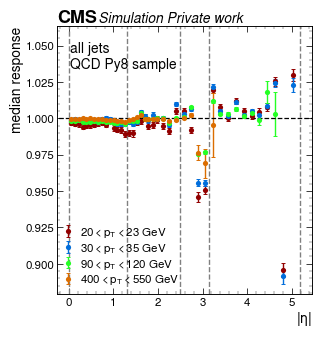

Read data from  ../out_txt/response_fit_results_L5_QCD-Py_noiso.json
Read data from  ../out_txt/response_fit_results_L5_QCD-Py_noiso.json
Read data from  ../out_txt/response_fit_results_L5_QCD-Py_noiso.json
Read data from  ../out_txt/response_fit_results_L5_QCD-Py_noiso.json
Figure saved: fig/corr_vs_pt/QCD_Py8/corr_vs_pt_QCD_Py8_all.pdf /.png


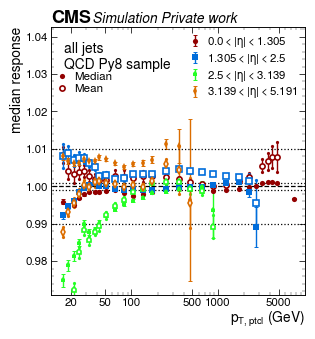

In [30]:
eta_binning = "CaloTowers"  ### HCalPart, JERC, CoarseCalo, CaloTowers, onebin Summer20Flavor;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
# from plotters import plot_corrections_eta
tag1 = '_L5_Pythia-TTBAR'+eta_binning_str
tag2 = '_L5_QCD-Py_noiso'+eta_binning_str

etabins = JetEtaBins(eta_binning, absolute=True)
pt_bins = PtBins("MC_truth")
# closure_corr = read_data2("Median", "all", tag2)
for flav in flavors:
    data = read_data4plot(tag2)[flav]
#     plot_corrections_eta(data[0], data[1], pt_bins, etabins.centres, tag2[:len(tag2)-1*len(eta_binning_str)], flav, plotptvals=[20, 30, 100, 400])
    plot_corrections_eta(data["Median"], data["MedianStd"], pt_bins, etabins.centres, "_L5_QCD Py8", flav, plotptvals=[20, 30, 100, 400])

    
eta_binning = "HCalPart"  ### HCalPart, JERC, CoarseCalo, CaloTowers, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
tag2 = '_L5_QCD-Py_noiso'+eta_binning_str
etabins = JetEtaBins(eta_binning, absolute=True)
pt_bins = PtBins("MC_truth")
for flav in flavors:
    datamed = [read_data4plot(tag2)[flav]["Median"], read_data4plot(tag2)[flav]["MedianStd"]]
    datamean = [read_data4plot(tag2)[flav]["Mean"], read_data4plot(tag2)[flav]["MeanStd"]]
    
    data1 = {"Median": datamed[0], "MedianStd": datamed[1], "Mean": datamean[0], "MeanStd":datamean[1]}
#     data1 = read_data4plot(tag2)[flav]
#     plot_corrections(data1, pt_bins.centres, etabins, tag2[:len(tag2)-1*len(eta_binning_str)], flav, plotetavals=[0, 1.305, 2.5, 3.139], plotmean=False)
    plot_corrections(data1, pt_bins.centres, etabins, "_L5_QCD Py8", flav, plotetavals=[0, 1.305, 2.5, 3.139], plotmean=True, minpt=15)

In [15]:
eta_binning = "CaloTowers"  ### HCalPart, JERC, CoarseCalo, CaloTowers, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
# from plotters import plot_corrections_eta
# tag1 = '_L5_Pythia-TTBAR'+eta_binning_str
tag2 = '_L5_QCD-Py'+eta_binning_str
# tag2 = '_L5_QCD-Py_leading_gen_jet'+eta_binning_str

etabins = JetEtaBins(eta_binning, absolute=True)
pt_bins = PtBins("MC_truth")
closure_corr = read_data2("Median", "all", tag2)
for flav in flavors:
    data = [read_data4plot(tag2)[flav]["Median"], read_data4plot(tag2)[flav]["MedianStd"]] #read_data4plot(flav, tag2)[:2]
#     plot_corrections_eta(data[0], data[1], pt_bins, etabins.centres, tag2[:len(tag2)-1*len(eta_binning_str)], flav, plotptvals=[20, 30, 100, 400])
    plot_corrections_eta(data[0], data[1], pt_bins, etabins.centres, "_L5_QCD Py8", flav, plotptvals=[20, 30, 100, 400])

    
eta_binning = "HCalPart"  ### HCalPart, JERC, CoarseCalo, CaloTowers, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
tag2 = '_L5_QCD-Py'+eta_binning_str
etabins = JetEtaBins(eta_binning, absolute=True)
pt_bins = PtBins("MC_truth")
for flav in flavors:
    datamed = [read_data4plot(tag2)[flav]["Median"], read_data4plot(tag2)[flav]["MedianStd"]]
    datamean = [read_data4plot(tag2)[flav]["Mean"], read_data4plot(tag2)[flav]["MeanStd"]]
    
    data1 = {"Median": datamed[0], "MedianStd": datamed[1], "Mean": datamean[0], "MeanStd":datamean[1]}
#     data1 = read_data4plot(tag2)[flav]
#     plot_corrections(data1, pt_bins.centres, etabins, tag2[:len(tag2)-1*len(eta_binning_str)], flav, plotetavals=[0, 1.305, 2.5, 3.139], plotmean=False)
    plot_corrections(data1, pt_bins.centres, etabins, "_L5_QCD Py8", flav, plotetavals=[0, 1.305, 2.5, 3.139], plotmean=True, minpt=15)

Read data from  ../out_txt/response_fit_results_L5_QCD-Py_CaloTowers.json
Read data from  ../out_txt/response_fit_results_L5_QCD-Py_CaloTowers.json


NameError: name 'plot_corrections_eta' is not defined

In [111]:
[{"a":2, "b":3,"3":5}[key] for key in ["a", "b"]]

[2, 3]

Figure saved: fig/corr_vs_pt/QCD-Py/corr_vs_pt_QCD-Py_all.pdf /.png


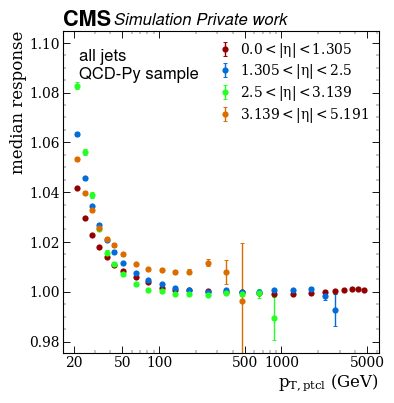

In [21]:
eta_binning = "HCalPart"  ### HCalPart, JERC, CoarseCalo, CaloTowers, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
tag2 = '_L5_QCD-Py'+eta_binning_str
etabins = JetEtaBins(eta_binning, absolute=True)
pt_bins = PtBins("MC_truth")
for flav in ['all']:
    data = read_data4plot(flav, tag2)[:2]  
    plot_corrections(data[0], data[1], pt_bins.centres, etabins, tag2[:len(tag2)-1*len(eta_binning_str)], flav, plotetavals=[0, 1.305, 2.5, 3.139])

Figure saved: fig/corr_vs_pt/QCD-Py_pu_genwt/corr_vs_pt_QCD-Py_pu_genwt_all.pdf /.png


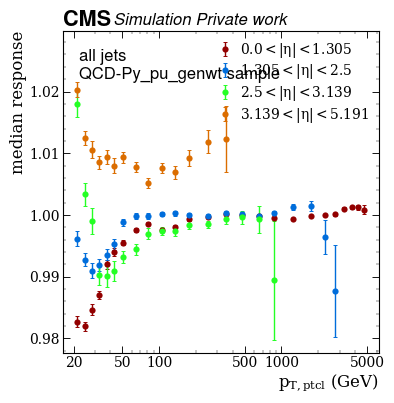

In [18]:
eta_binning = "HCalPart"  ### HCalPart, JERC, CoarseCalo, CaloTowers, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
tag2 = '_L5_QCD-Py_pu_genwt'+eta_binning_str
etabins = JetEtaBins(eta_binning, absolute=True)
pt_bins = PtBins("MC_truth")
for flav in ['all']:
    data = read_data4plot(flav, tag2)[:2]  
    plot_corrections(data[0], data[1], pt_bins.centres, etabins, tag2[:len(tag2)-1*len(eta_binning_str)], flav, plotetavals=[0, 1.305, 2.5, 3.139])

Figure saved: fig/corr_vs_pt/QCD-Py/corr_vs_pt_QCD-Py_all.pdf /.png


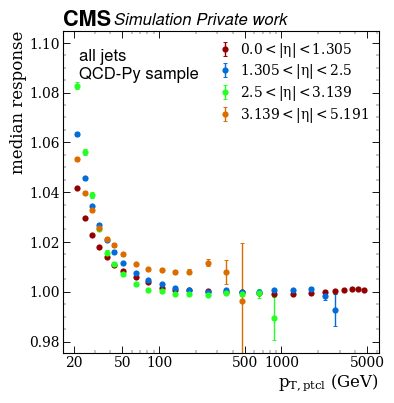

In [19]:
eta_binning = "HCalPart"  ### HCalPart, JERC, CoarseCalo, CaloTowers, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
tag2 = '_L5_QCD-Py'+eta_binning_str
etabins = JetEtaBins(eta_binning, absolute=True)
pt_bins = PtBins("MC_truth")
for flav in ['all']:
    data = read_data4plot(flav, tag2)[:2]  
    plot_corrections(data[0], data[1], pt_bins.centres, etabins, tag2[:len(tag2)-1*len(eta_binning_str)], flav, plotetavals=[0, 1.305, 2.5, 3.139])

In [ ]:
# load_fit_res=True
# subsamples = ['all', 'b', 'c', 'd', 'u', 's', 'g']
# subsamples = ['b', 'c', 'd', 'u', 's', 'g']

subsamples = ['ud', 'b']
# subsamples = ['all']


tag1 = '_L5_Herwig-QCD-etaAut18'
tag2 = '_L5_QCD-JME-etaAut18'
# tag3 = '_L5_QCD-divided'

closure_corr = read_data("Median", "all", tag2)
# closure_corr = read_data("Median", "all", tag2)

# df_csv = pd.read_csv('out_txt/Closure_L5_QCD_Pythia.coffea').set_index('etaBins')
# closure_corr = df_csv.to_numpy().transpose()

mean_name = "Median"
mean_name_std = mean_name+'Std'

closure_Aut18 = evaluator['Autumn18_V3_MC_Herwig7_all_L2Relative_AK4PFchs']


# closure_Sum16 = evaluator['Summer16_07Aug2017_V15_Flavor_Herwig7_MC_L2Relative_AK4PFchs']


for samp in subsamples:
    samp_Aut18 = samp
#     samp_Sum20 = '_'+samp
    samp_Aut18 = '_ud' if samp_Aut18=='u' or samp_Aut18=='d' else '_'+samp_Aut18
#     samp_Sum20 = '_q' if samp_Aut18=='_ud' else '_'+samp
#     samp_Sum16 = '' if samp_Aut18=='_all' else samp_Aut18

    median1 = read_data(mean_name, samp, tag1) #[2:]
    medianstd1 = read_data(mean_name_std, samp, tag1)
    reco_pt = read_data("MeanRecoPt", samp, tag1)

    median2 = read_data(mean_name, samp, tag2) #[2:]
    medianstd2 = read_data(mean_name_std, samp, tag2)
    evo = evaluator[f'Autumn18_V3_MC_Herwig7{samp_Aut18}_L2Relative_AK4PFchs']
#     if samp_Aut18=='_all':
#         evo2 = evaluator['Summer16_07Aug2017_V15_Flavor_Pythia8_MC_L2Relative_AK4PFchs']
#     else:
#         evo2 = evaluator[f'Summer16_07Aug2017_V15_Flavor_Pythia8_MC{samp_Aut18}_L5Flavor_AK4PFchs']
        
    evo3 = evaluator[f'Winter14_V8_MC_L5Flavor_AK5Calo{samp_Aut18}J']
#     evo4 = evaluator[f'Winter14_V8_MC_L5Flavor_AK5Calo{samp_Aut18}J']
    evo4 = evaluator[f'Summer20UL18_V2_MC_L5Flavor_AK4PFchs_Her{samp_Aut18}J']

    data = {
#             "No_closure": [median2, medianstd2, reco_pt],
            "Her7": [median1/closure_corr, medianstd1, reco_pt],
            "Py8": [median2/closure_corr, medianstd2, reco_pt],
           }
    
    functions = {
            "Autumn18_He": [evo, closure_Aut18],
            "Winter14":       [evo3, None],
            "Summer20_He":       [evo4, None],
           }
    
    for k in range(len(etabins_abs)-1):
#     for k in [9]:
        print('Plotting subsample: ', samp)
        print('Eta: ', k)
        if not np.any(median2[:,k]>-0.1):
            print("All median values are none")
            continue
#         median_4 = read_data("Median", samp, '_L5_LHEflav1_Herwig-TTBAR-JME-noLepIso')
#         medianstd_4 = read_data("MedianStd", samp, '_L5_LHEflav1_Herwig-TTBAR-JME-noLepIso')
        
#         make_comparison_plot_many(data,
#                               correction_fncs = np.array([None]), closures=[], k=0, samp='',
#                                name_base='', names=[], ratio_name='ratio'):
        
        make_comparison_plot(data, 
                                  functions,
                                  etaidx=k, samp=samp, ratio_name='*/ \n Herwig')
        
3;


### Double ration plots (for flavour vs antiflavour) responses

In [14]:
tag1 = '_L5_not_scaled_pion'+'_split_antiflav'+eta_binning_str
tag2 = '_L5_scaled_pion'+'_split_antiflav'+eta_binning_str
tag3 = '_L5_scaled_times2_pion'+'_split_antiflav'+eta_binning_str
tag4 = '_L5_scaled_times5_pion'+'_split_antiflav'+eta_binning_str
tag5 = '_L5_scaled_times10_pion'+'_split_antiflav'+eta_binning_str

# tag1 = '_L5_DY-MG-Py'
# tag2 = '_L5_DY-MG-Her'

mean_name = "Median"
mean_name_std = mean_name+'Std'
# closure_Py = read_data2(mean_name, 'all', tag1)
# closure_Py2 = read_data2(mean_name, 'all', tag3)
# closure_Py3 = read_data2(mean_name, 'all', tag5)
# closure_Py = read_data(mean_name, 'all', tag3)


for flav in flavors:
    data = {
        # label_on_plot: data_list,
        f"QCD Py8, central $\pi$": np.array(read_data4plot(flav, tag1)), #[:,:-1,:],
        f"QCD Py8, scaled $\pi$": np.array(read_data4plot(flav, tag2)), #[:,:-1,:],
        f"QCD Py8, scaled $\pi$ x2": np.array(read_data4plot(flav, tag3)), #[:,:-1,:],
        f"QCD Py8, scaled $\pi$ x5": np.array(read_data4plot(flav, tag4)), #[:,:-1,:],
        f"QCD Py8, scaled $\pi$ x10": np.array(read_data4plot(flav, tag5)), #[:,:-1,:],

SyntaxError: unexpected EOF while parsing (3575846482.py, line 25)

In [29]:
# def read_data(mean_name, samp, tag1):
#     return read_or_recreate_data(tag1, out_txt_path)[mean_name][samp]

Fitting subsample:  b
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta0p0to1p305.pdf / .png


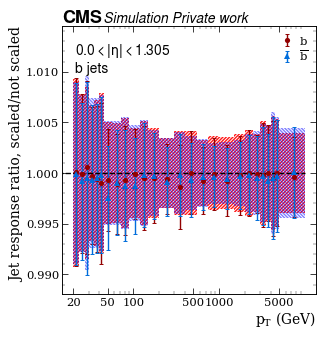

Fitting subsample:  b
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta1p305to2p5.pdf / .png


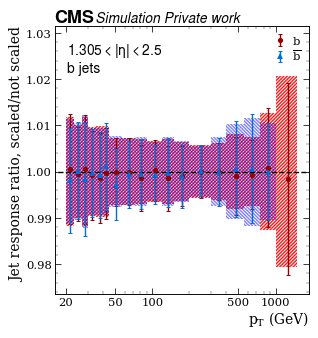

Fitting subsample:  b
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta2p5to3p139.pdf / .png


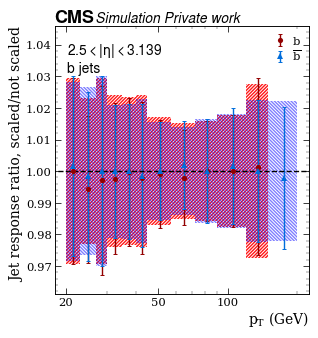

Fitting subsample:  b
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_split_antiflav.json


KeyboardInterrupt: 

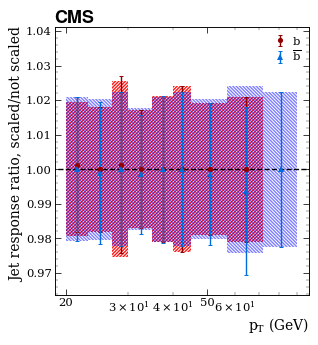

In [14]:
# load_fit_res=True
flavors = ['b', 'c', 's', 'u', 'd']

eta_binning  = "HCalPart"  ### HCalPart, JERC, CoarseCalo, CaloTowers, Summer20Flavor, onebin;
pt_binning  = "MC_truth"  ### MC_truth, Uncert, Coarse, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
pt_binning_str = '_pt-'+pt_binning if pt_binning != "MC_truth" else ''
etabins = JetEtaBins(eta_binning, absolute=True)
ptbins = PtBins(pt_binning)

# k2 = np.where(etabins_abs<=0)[0][-1]
# k4 = np.where(etabins_abs<=1.3)[0][-1]
# k6 = np.where(etabins_abs<=2.5)[0][-1]
# k8 = np.where(etabins_abs<=3.0)[0][-1]
# ks = [k2, k4, k6, k8]

# ks = [k2, k4] #, k6, k8]
for flav in flavors:
    for k in etabins.get_bin_idx([0, 1.305, 2.5, 4]):
        print('Fitting subsample: ', flav)
        print('Eta: ', etabins.centres[k]) #if plotvspt else print('pt: ', ptbins.centres[k])
#         if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
#             continue
      
        
        make_double_ratio_plot(
                               '_L5_scaled_pion'+eta_binning_str+pt_binning_str    +'_split_antiflav',
                               '_L5_not_scaled_pion'+eta_binning_str+pt_binning_str+'_split_antiflav',
                               legend_names=['scaled', 'not scaled'],
                               etaidx=k, flav=flav,
                               ptbins=ptbins,
                               ratio_type1=False)
                
3;

In [109]:
plt.rcParams['figure.subplot.left']=0.21

Fitting subsample:  b
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta0p0to1p305.pdf / .png


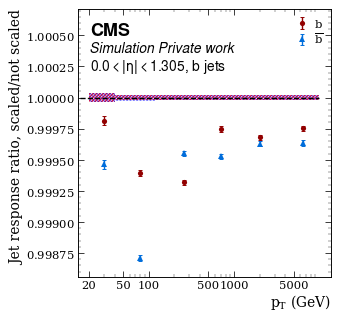

Fitting subsample:  b
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta1p305to2p5.pdf / .png


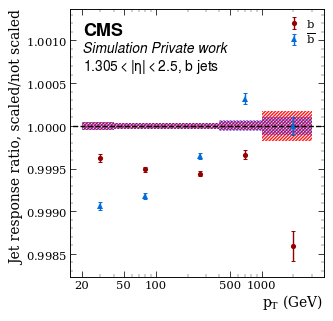

Fitting subsample:  b
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta2p5to3p139.pdf / .png


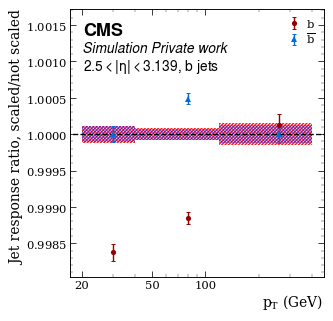

Fitting subsample:  b
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta3p139to5p191.pdf / .png


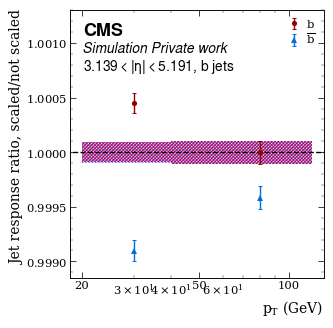

Fitting subsample:  c
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_c_eta0p0to1p305.pdf / .png


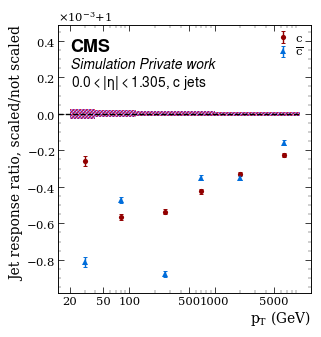

Fitting subsample:  c
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_c_eta1p305to2p5.pdf / .png


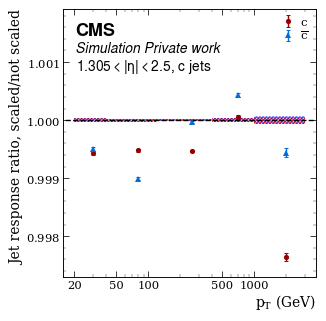

Fitting subsample:  c
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_c_eta2p5to3p139.pdf / .png


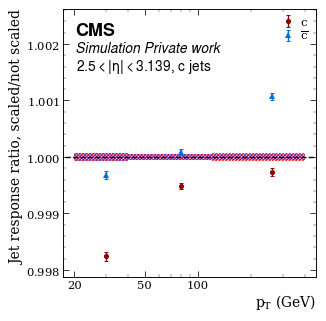

Fitting subsample:  c
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_c_eta3p139to5p191.pdf / .png


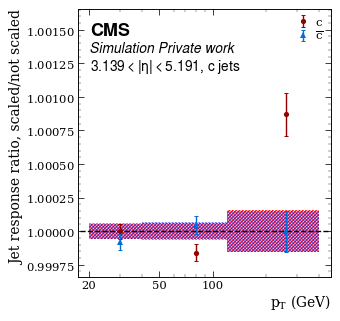

Fitting subsample:  s
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_s_eta0p0to1p305.pdf / .png


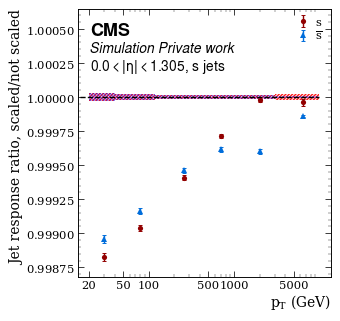

Fitting subsample:  s
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_s_eta1p305to2p5.pdf / .png


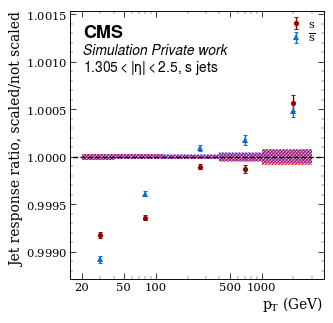

Fitting subsample:  s
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_s_eta2p5to3p139.pdf / .png


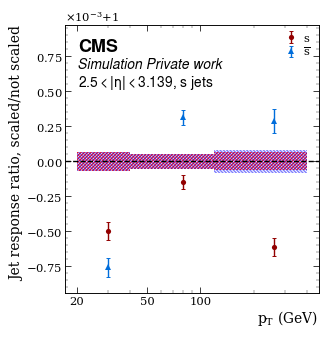

Fitting subsample:  s
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_s_eta3p139to5p191.pdf / .png


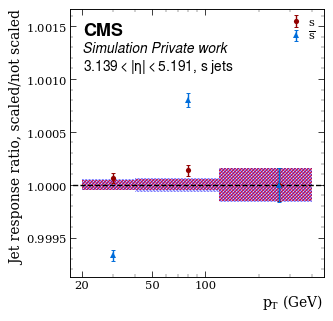

Fitting subsample:  ud
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_ud_eta0p0to1p305.pdf / .png


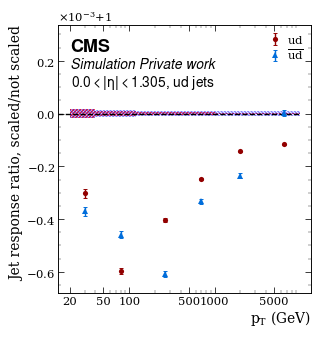

Fitting subsample:  ud
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_ud_eta1p305to2p5.pdf / .png


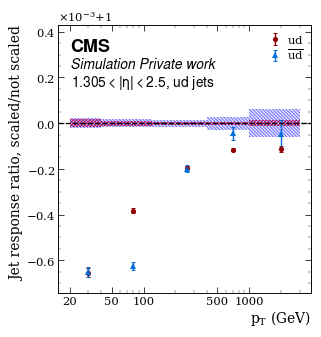

Fitting subsample:  ud
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_ud_eta2p5to3p139.pdf / .png


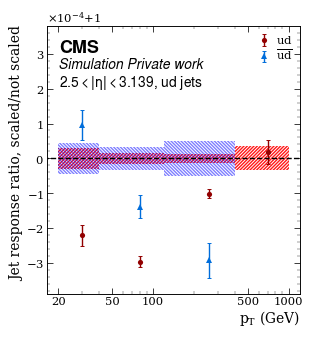

Fitting subsample:  ud
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_ud_eta3p139to5p191.pdf / .png


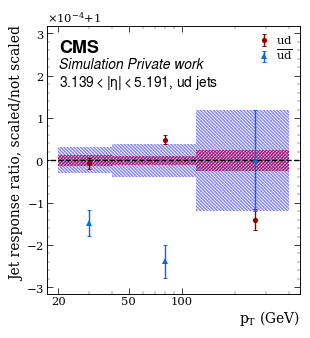

Fitting subsample:  d
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_d_eta0p0to1p305.pdf / .png


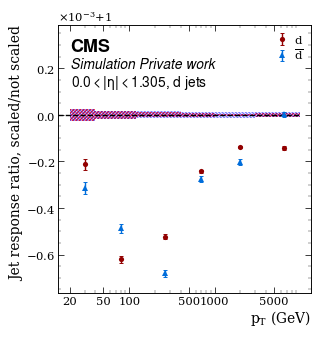

Fitting subsample:  d
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_d_eta1p305to2p5.pdf / .png


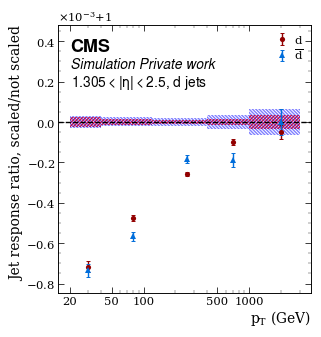

Fitting subsample:  d
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_d_eta2p5to3p139.pdf / .png


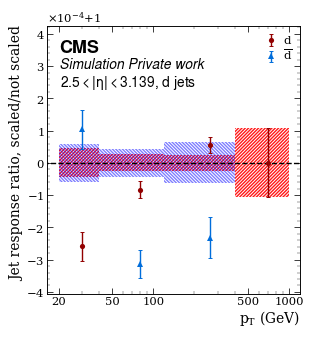

Fitting subsample:  d
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_d_eta3p139to5p191.pdf / .png


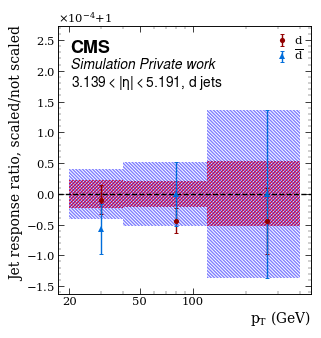

Fitting subsample:  u
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_u_eta0p0to1p305.pdf / .png


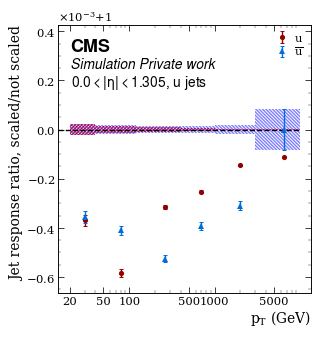

Fitting subsample:  u
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_u_eta1p305to2p5.pdf / .png


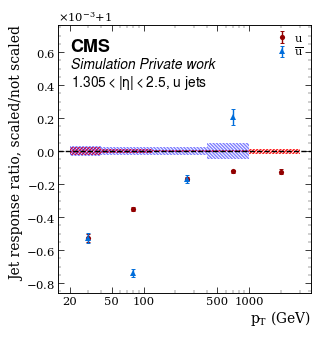

Fitting subsample:  u
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_u_eta2p5to3p139.pdf / .png


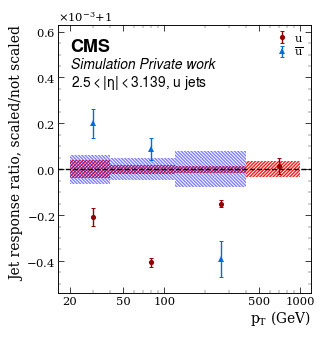

Fitting subsample:  u
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-Coarse_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_u_eta3p139to5p191.pdf / .png


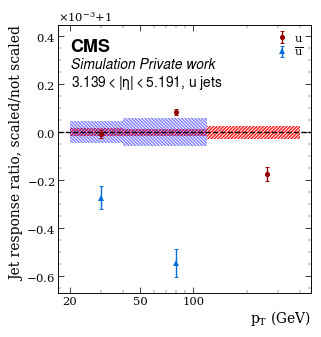

In [112]:
# load_fit_res=True
flavors = ['b', 'c', 's', 'ud', 'd', 'u']

eta_binning  = "HCalPart"  ### HCalPart, JERC, CoarseCalo, CaloTowers, Summer20Flavor, onebin;
pt_binning  = "Coarse"  ### MC_truth, Uncert, Coarse, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
pt_binning_str = '_pt-'+pt_binning if pt_binning != "MC_truth" else ''
etabins = JetEtaBins(eta_binning, absolute=True)
ptbins = PtBins(pt_binning)

# k2 = np.where(etabins_abs<=0)[0][-1]
# k4 = np.where(etabins_abs<=1.3)[0][-1]
# k6 = np.where(etabins_abs<=2.5)[0][-1]
# k8 = np.where(etabins_abs<=3.0)[0][-1]
# ks = [k2, k4, k6, k8]

# ks = [k2, k4] #, k6, k8]
for flav in flavors:
    for k in etabins.get_bin_idx([0, 1.305, 2.5, 4]):
        print('Fitting subsample: ', flav)
        print('Eta: ', etabins.centres[k]) #if plotvspt else print('pt: ', ptbins.centres[k])
#         if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
#             continue
      
        
        make_double_ratio_plot(
                               '_L5_scaled_pion'+eta_binning_str+pt_binning_str    +'_split_antiflav',
                               '_L5_not_scaled_pion'+eta_binning_str+pt_binning_str+'_split_antiflav',
                               legend_names=['scaled', 'not scaled'],
                               etaidx=k, flav=flav,
                               ptbins=ptbins,
                               ratio_type1=False,
                                scale_uncert=100,
                                sci_format=True)
                
3;

Fitting subsample:  b
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Automatically determined a config from a data_tag: {'test_run': False, 'load_fit_res': False, 'saveplots': False, 'combine_antiflavour': False, 'eta_binning': 'HCalPart', 'pt_binning': 'onebin', 'sum_neg_pos_eta_bool': True, 'tag_Lx': '_L5', 'add_tag': '', 'fit_tag': '', 'flavors': ['b', 'ud', 'all', 'g', 'c', 's', 'q', 'u', 'd', 'unmatched'], 'pt_to_fit': None, 'eta_to_fit': None}
The cleaned tag is:  scaled_times10_pion
The text file with fit results ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json does not exist, but the output hist

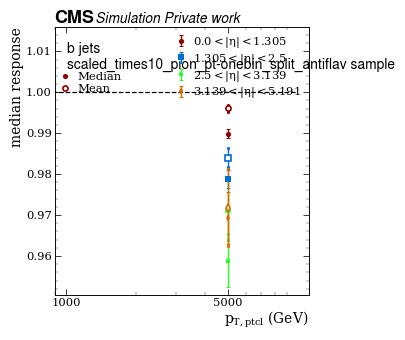

-------------------------
-------------------------
Fitting flavor:  bbar
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_bbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_bbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_bbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_bbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_bbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure s

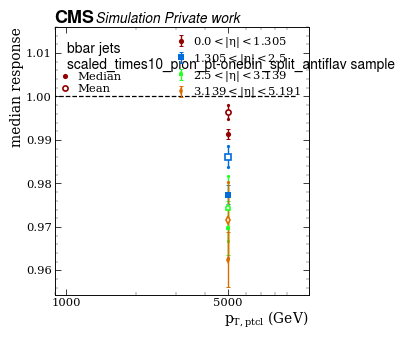

-------------------------
-------------------------
Fitting flavor:  ud
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_ud_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_ud_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_ud_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_ud_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_ud_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure saved: fig/co

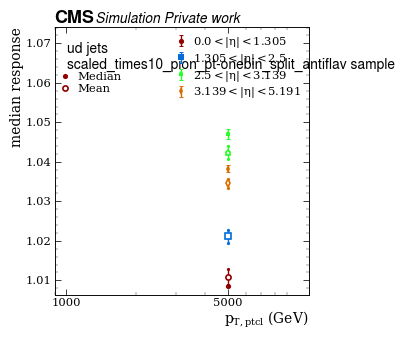

-------------------------
-------------------------
Fitting flavor:  udbar
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_udbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_udbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_udbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_udbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_udbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Fi

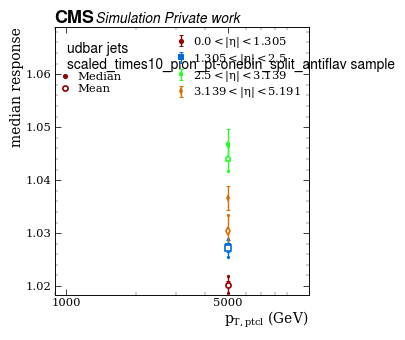

-------------------------
-------------------------
Fitting flavor:  all
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_all_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_all_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_all_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_all_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_all_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure saved: 

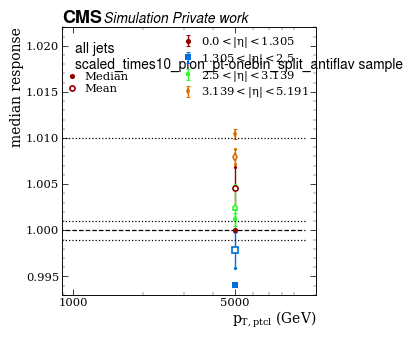

-------------------------
-------------------------
Fitting flavor:  g
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_g_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_g_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_g_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_g_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_g_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure saved: fig/corr_vs_

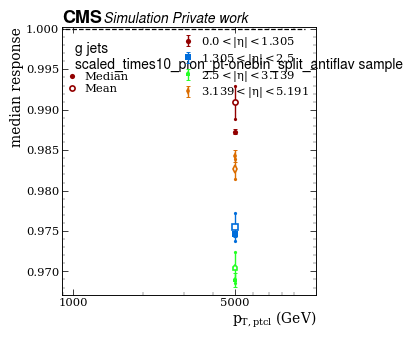

-------------------------
-------------------------
Fitting flavor:  c
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_c_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_c_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_c_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_c_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_c_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure saved: fig/corr_vs_

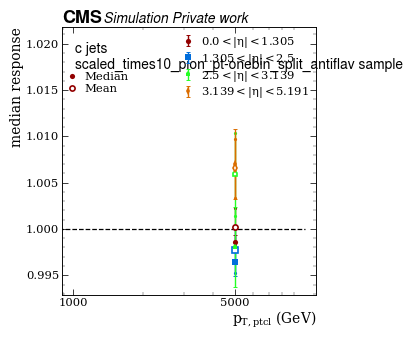

-------------------------
-------------------------
Fitting flavor:  cbar
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_cbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_cbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_cbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_cbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_cbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure s

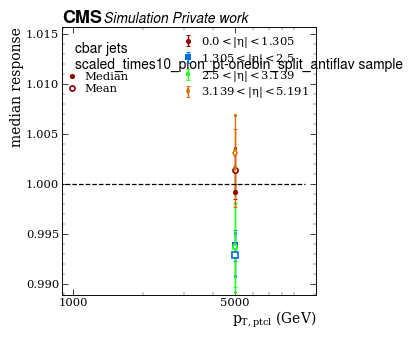

-------------------------
-------------------------
Fitting flavor:  s
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_s_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_s_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_s_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_s_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_s_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure saved: fig/corr_vs_

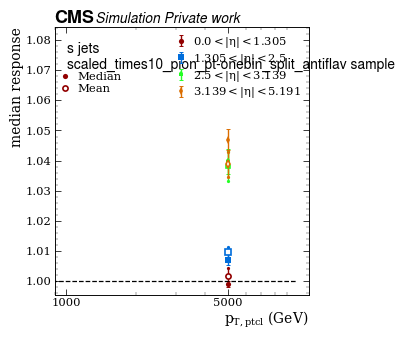

-------------------------
-------------------------
Fitting flavor:  sbar
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_sbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_sbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_sbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_sbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_sbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure s

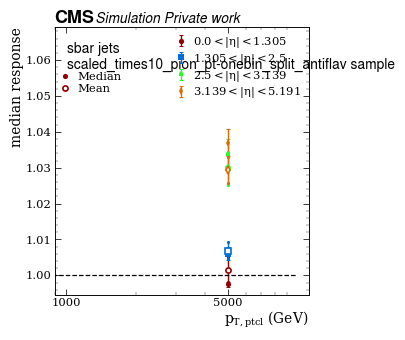

-------------------------
-------------------------
Fitting flavor:  q
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_q_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_q_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_q_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_q_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_q_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure saved: fig/corr_vs_

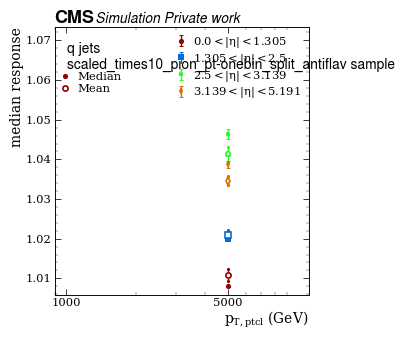

-------------------------
-------------------------
Fitting flavor:  qbar
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_qbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_qbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_qbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_qbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_qbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure s

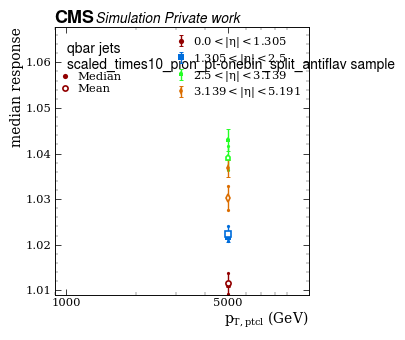

-------------------------
-------------------------
Fitting flavor:  u
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_u_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_u_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_u_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_u_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_u_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure saved: fig/corr_vs_

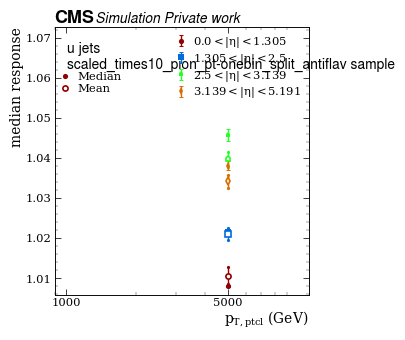

-------------------------
-------------------------
Fitting flavor:  ubar
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_ubar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_ubar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_ubar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_ubar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_ubar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure s

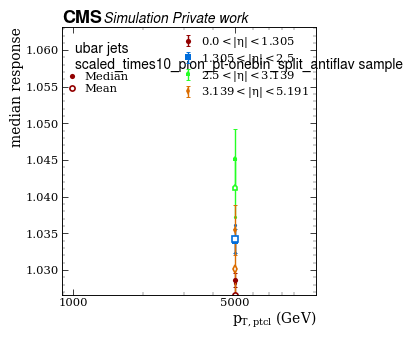

-------------------------
-------------------------
Fitting flavor:  d
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_d_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_d_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_d_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_d_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_d_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure saved: fig/corr_vs_

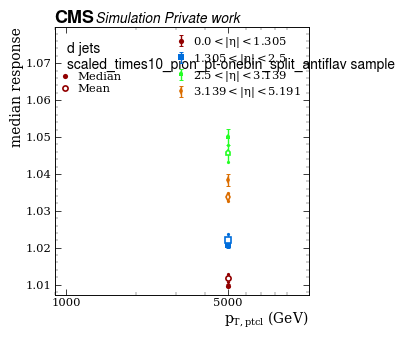

-------------------------
-------------------------
Fitting flavor:  dbar
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_dbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_dbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_dbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_dbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_dbar_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Figure s

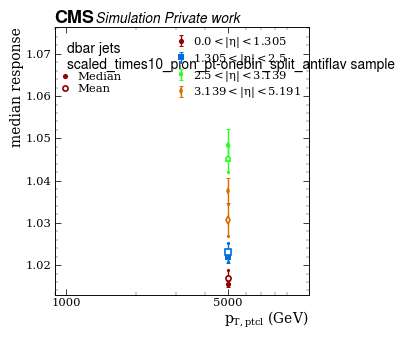

-------------------------
-------------------------
Fitting flavor:  unmatched
Response fit plots won't be saved
fit summary: 
N bins converged = 4; N bins not fit because of too little data = 0; N bins not converged = 0
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMean_unmatched_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanStd_unmatched_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedian_unmatched_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMedianStd_unmatched_L5_scaled_times10_pion_pt-onebin_split_antiflav.csv
Saving data under: /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/EtaBinsvsPtBinsMeanRecoPt_unmatched_L5_scaled_times10_pion_pt-oneb

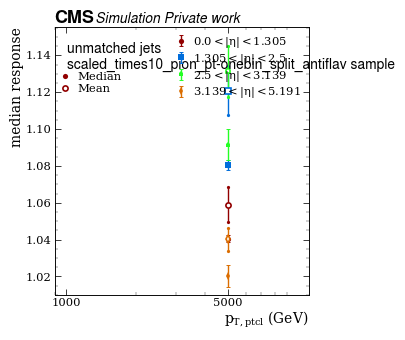

Saved /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
-------------------------
-------------------------
Saving cutflow
dataset label:  pion up x10
Saving plot with the name =  /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/fig/cutflow/scaled_times10_pion/cutflow_Nevents_scaled_times10_pion


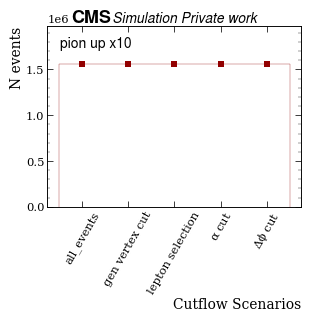

Saving plot with the name =  /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/fig/cutflow/scaled_times10_pion/cutflow_Njets_scaled_times10_pion


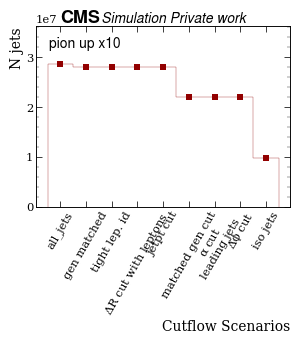

Saving plot with the name =  /afs/cern.ch/user/a/anpotreb/top/JERC/JMECoffea/fig/cutflow/scaled_times10_pion/cutflow_Njets_per_ev_scaled_times10_pion


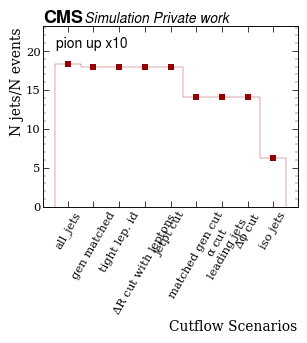

--------------------------------------------------
All done. Congrats!
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta0p0to1p305.pdf / .png


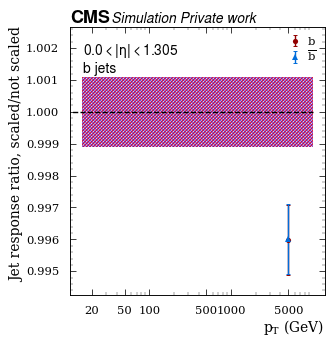

Fitting subsample:  b
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta1p305to2p5.pdf / .png


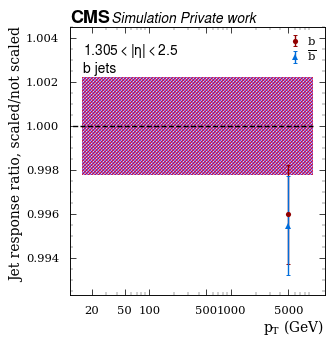

Fitting subsample:  b
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta2p5to3p139.pdf / .png


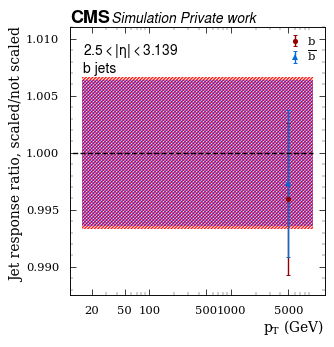

Fitting subsample:  b
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta3p139to5p191.pdf / .png


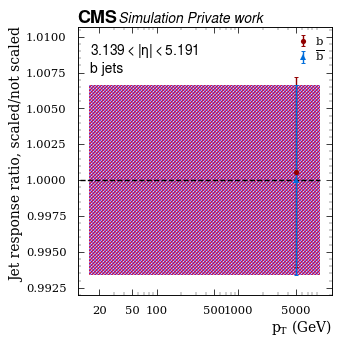

Fitting subsample:  c
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_c_eta0p0to1p305.pdf / .png


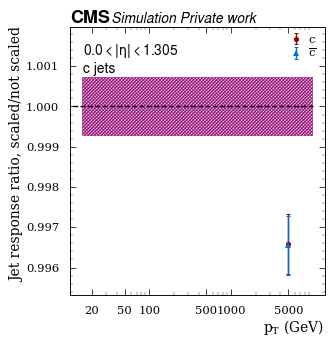

Fitting subsample:  c
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_c_eta1p305to2p5.pdf / .png


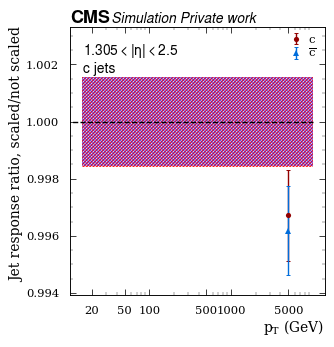

Fitting subsample:  c
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_c_eta2p5to3p139.pdf / .png


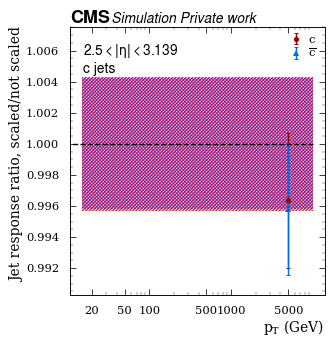

Fitting subsample:  c
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_c_eta3p139to5p191.pdf / .png


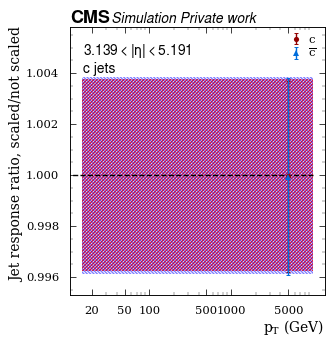

Fitting subsample:  s
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_s_eta0p0to1p305.pdf / .png


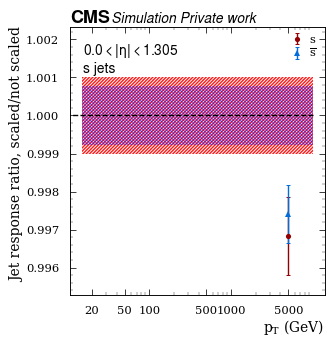

Fitting subsample:  s
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_s_eta1p305to2p5.pdf / .png


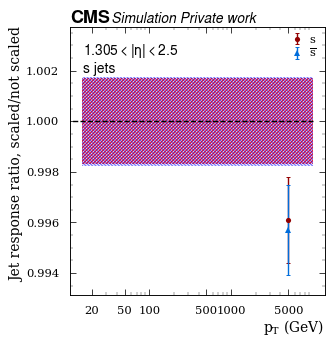

Fitting subsample:  s
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_s_eta2p5to3p139.pdf / .png


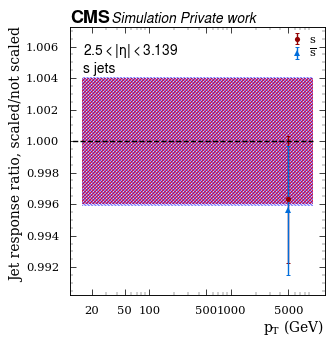

Fitting subsample:  s
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_s_eta3p139to5p191.pdf / .png


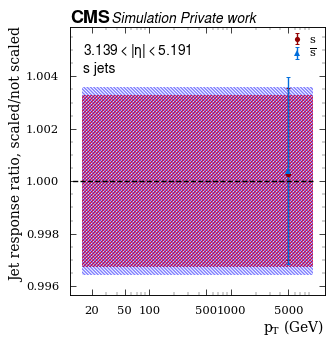

Fitting subsample:  u
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_u_eta0p0to1p305.pdf / .png


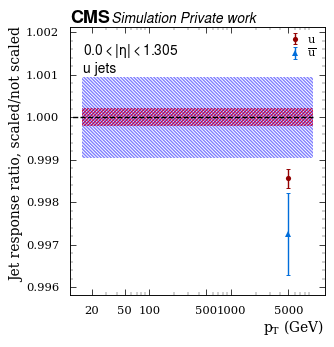

Fitting subsample:  u
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_u_eta1p305to2p5.pdf / .png


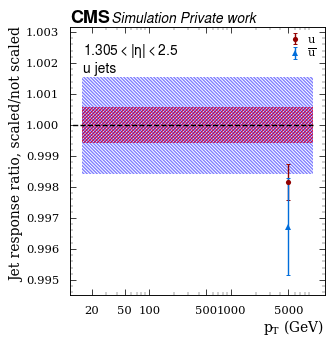

Fitting subsample:  u
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_u_eta2p5to3p139.pdf / .png


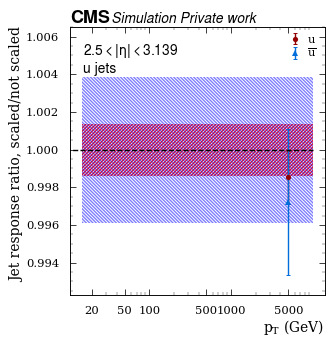

Fitting subsample:  u
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_u_eta3p139to5p191.pdf / .png


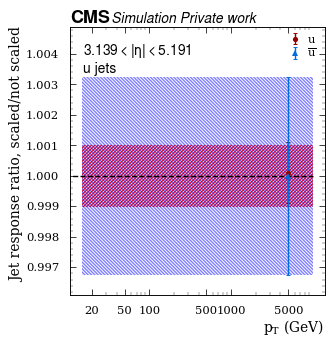

Fitting subsample:  d
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_d_eta0p0to1p305.pdf / .png


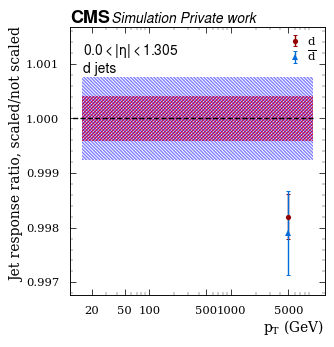

Fitting subsample:  d
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_d_eta1p305to2p5.pdf / .png


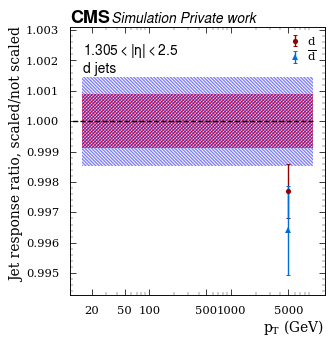

Fitting subsample:  d
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_d_eta2p5to3p139.pdf / .png


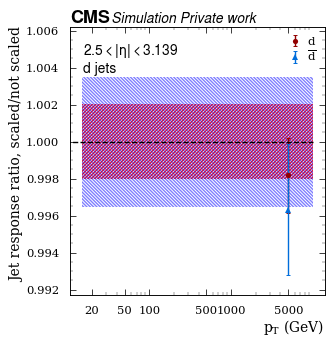

Fitting subsample:  d
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_d_eta3p139to5p191.pdf / .png


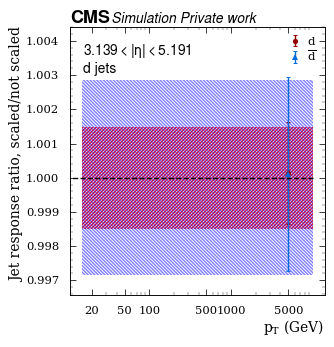

In [18]:
# load_fit_res=True
flavors = ['b', 'c', 's', 'u', 'd']

eta_binning  = "HCalPart"  ### HCalPart, JERC, CoarseCalo, CaloTowers, Summer20Flavor, onebin;
pt_binning  = "onebin"  ### MC_truth, Uncert, Coarse, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
pt_binning_str = '_pt-'+pt_binning if pt_binning != "MC_truth" else ''
etabins = JetEtaBins(eta_binning, absolute=True)
ptbins = PtBins(pt_binning)

# k2 = np.where(etabins_abs<=0)[0][-1]
# k4 = np.where(etabins_abs<=1.3)[0][-1]
# k6 = np.where(etabins_abs<=2.5)[0][-1]
# k8 = np.where(etabins_abs<=3.0)[0][-1]
# ks = [k2, k4, k6, k8]

# ks = [k2, k4] #, k6, k8]
for flav in flavors:
    for k in etabins.get_bin_idx([0, 1.305, 2.5, 4]):
        print('Fitting subsample: ', flav)
        print('Eta: ', etabins.centres[k]) #if plotvspt else print('pt: ', ptbins.centres[k])
#         if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
#             continue
      
        
        make_double_ratio_plot(
                               '_L5_scaled_times10_pion'+eta_binning_str+pt_binning_str    +'_split_antiflav',
                               '_L5_not_scaled_pion'+eta_binning_str+pt_binning_str+'_split_antiflav',
                               legend_names=['scaled', 'not scaled'],
                               etaidx=k, flav=flav,
                               ptbins=ptbins,
                               ratio_type1=False)
                
3;

Fitting subsample:  b
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta0p0to1p305.pdf / .png


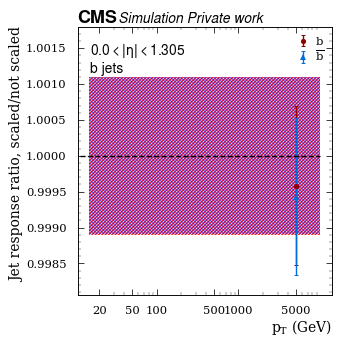

Fitting subsample:  b
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta1p305to2p5.pdf / .png


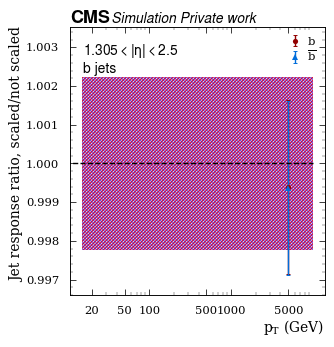

Fitting subsample:  b
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta2p5to3p139.pdf / .png


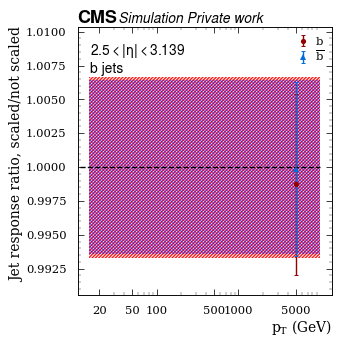

Fitting subsample:  b
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_b_eta3p139to5p191.pdf / .png


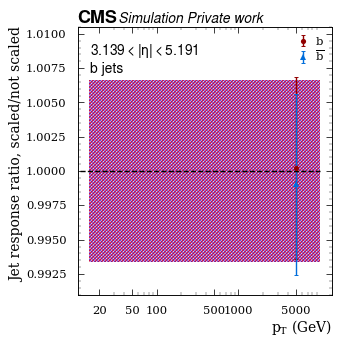

Fitting subsample:  c
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_c_eta0p0to1p305.pdf / .png


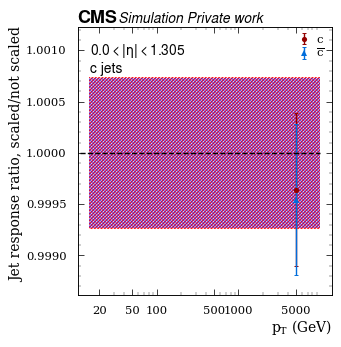

Fitting subsample:  c
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_c_eta1p305to2p5.pdf / .png


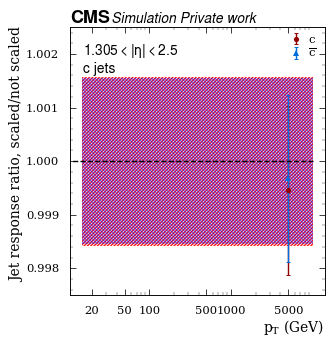

Fitting subsample:  c
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_c_eta2p5to3p139.pdf / .png


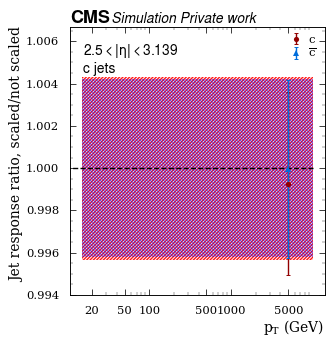

Fitting subsample:  c
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_c_eta3p139to5p191.pdf / .png


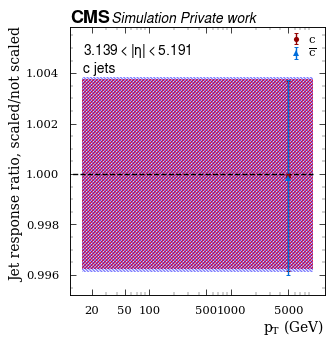

Fitting subsample:  s
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_s_eta0p0to1p305.pdf / .png


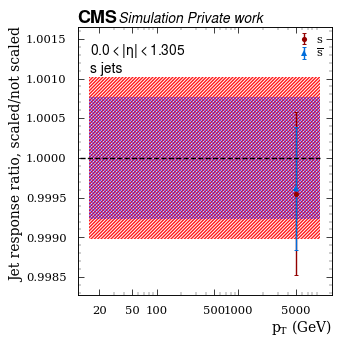

Fitting subsample:  s
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_s_eta1p305to2p5.pdf / .png


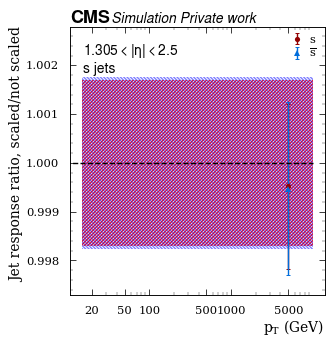

Fitting subsample:  s
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_s_eta2p5to3p139.pdf / .png


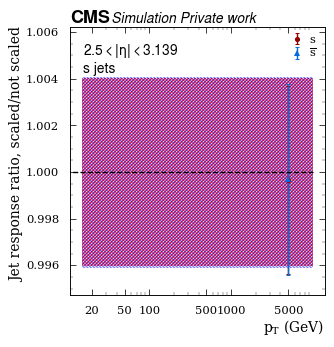

Fitting subsample:  s
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_s_eta3p139to5p191.pdf / .png


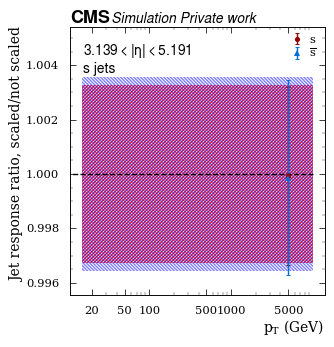

Fitting subsample:  u
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_u_eta0p0to1p305.pdf / .png


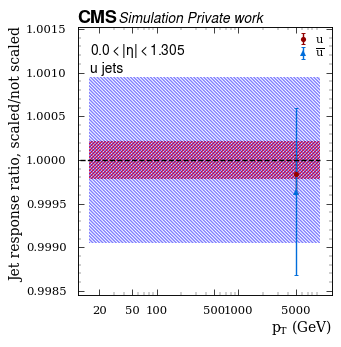

Fitting subsample:  u
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_u_eta1p305to2p5.pdf / .png


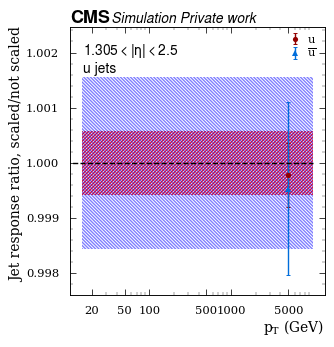

Fitting subsample:  u
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_u_eta2p5to3p139.pdf / .png


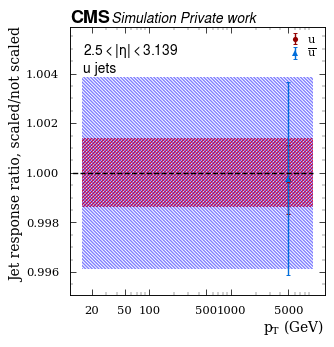

Fitting subsample:  u
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_u_eta3p139to5p191.pdf / .png


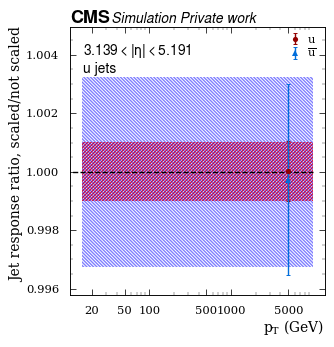

Fitting subsample:  d
Eta:  0.6525
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_d_eta0p0to1p305.pdf / .png


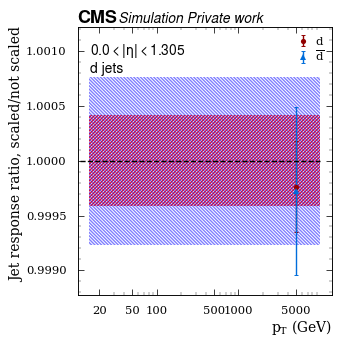

Fitting subsample:  d
Eta:  1.9024999999999999
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_d_eta1p305to2p5.pdf / .png


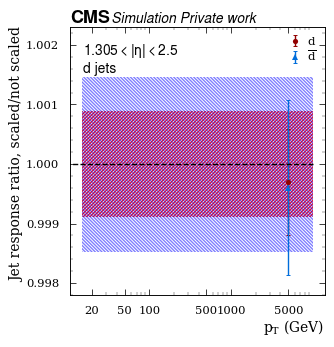

Fitting subsample:  d
Eta:  2.8194999999999997
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_d_eta2p5to3p139.pdf / .png


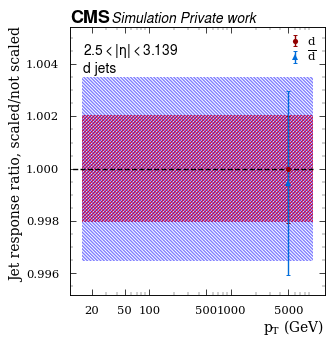

Fitting subsample:  d
Eta:  4.165
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Saving plot with the name =  fig/double_ratios/double_ratio_scaled_not_scaled//double_ratio_scaled_not_scaled_d_eta3p139to5p191.pdf / .png


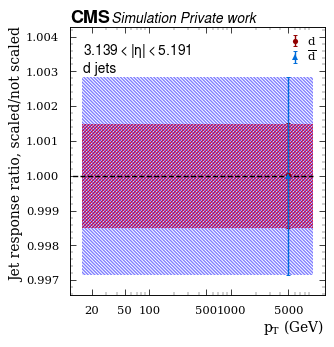

In [15]:
# load_fit_res=True
flavors = ['b', 'c', 's', 'u', 'd']

eta_binning  = "HCalPart"  ### HCalPart, JERC, CoarseCalo, CaloTowers, Summer20Flavor, onebin;
pt_binning  = "onebin"  ### MC_truth, Uncert, Coarse, onebin;
eta_binning_str = '_'+eta_binning if eta_binning != "HCalPart" else ''
pt_binning_str = '_pt-'+pt_binning if pt_binning != "MC_truth" else ''
etabins = JetEtaBins(eta_binning, absolute=True)
ptbins = PtBins(pt_binning)

# k2 = np.where(etabins_abs<=0)[0][-1]
# k4 = np.where(etabins_abs<=1.3)[0][-1]
# k6 = np.where(etabins_abs<=2.5)[0][-1]
# k8 = np.where(etabins_abs<=3.0)[0][-1]
# ks = [k2, k4, k6, k8]

# ks = [k2, k4] #, k6, k8]
for flav in flavors:
    for k in etabins.get_bin_idx([0, 1.305, 2.5, 4]):
        print('Fitting subsample: ', flav)
        print('Eta: ', etabins.centres[k]) #if plotvspt else print('pt: ', ptbins.centres[k])
#         if not np.any(data[list(data.keys())[0]][2][:,k]>-0.1):
#             continue
      
        
        make_double_ratio_plot(
                               '_L5_scaled_pion'+eta_binning_str+pt_binning_str    +'_split_antiflav',
                               '_L5_not_scaled_pion'+eta_binning_str+pt_binning_str+'_split_antiflav',
                               legend_names=['scaled', 'not scaled'],
                               etaidx=k, flav=flav,
                               ptbins=ptbins,
                               ratio_type1=False)
                
3;

In [28]:
flav = 'b'
np.array(read_or_recreate_data('_L5_scaled_pion'+eta_binning_str+pt_binning_str    +'_split_antiflav', '../out_txt')['data'][flav]['Median'])/np.array(read_or_recreate_data('_L5_not_scaled_pion'+eta_binning_str+pt_binning_str    +'_split_antiflav', '../out_txt')['data'][flav]['Median'])-np.array(read_or_recreate_data('_L5_scaled_pion'+eta_binning_str+pt_binning_str    +'_split_antiflav', '../out_txt')['data'][flav+'bar']['Median'])/np.array(read_or_recreate_data('_L5_not_scaled_pion'+eta_binning_str+pt_binning_str    +'_split_antiflav', '../out_txt')['data'][flav+'bar']['Median'])

Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_not_scaled_pion_pt-onebin_split_antiflav.json


array([[ 4.23627800e-05,  2.01864345e-05, -2.54873920e-04,
        -3.52998896e-04]])

In [23]:
np.array(read_or_recreate_data('_L5_scaled_times10_pion'+eta_binning_str+pt_binning_str    +'_split_antiflav', '../out_txt')['data'][flav]['Median'])/np.array(read_or_recreate_data('_L5_scaled_pion'+eta_binning_str+pt_binning_str    +'_split_antiflav', '../out_txt')['data'][flav]['Median'])

Read data from  ../out_txt/response_fit_results_L5_scaled_times10_pion_pt-onebin_split_antiflav.json
Read data from  ../out_txt/response_fit_results_L5_scaled_pion_pt-onebin_split_antiflav.json


array([[0.9979858 , 0.99779008, 0.99837384, 1.000167  ]])

In [19]:
read_data("Median", flav, outputname_denom)

NameError: name 'read_data' is not defined

In [ ]:
# # load_fit_res=True
# subsamples = ['_b', '_c', '_s', '_ud']
# # subsamples = ['_g']

# k2 = np.where(etabins_abs<=0)[0][-1]
# k4 = np.where(etabins_abs<=1.3)[0][-1]
# k6 = np.where(etabins_abs<=2.5)[0][-1]
# k8 = np.where(etabins_abs<=3.0)[0][-1]
# ks = [k2, k4, k6, k8]

# # ks = [k2, k4] #, k6, k8]
# for samp in subsamples:
#     for k in ks:
#         print('Fitting subsample: ', samp)
#         print('Eta: ', k)        
        
#         make_double_ratio_plot('_L5_LHEflav1_TTBAR-JME', '_L5_LHEflav1_Herwig-TTBAR-JME',
#                                    k=k, samp=samp,
#                                    ratio_name=f'{samp[1:]}bar /\n {samp[1:]}')
                
# 3;